In [1]:
import warnings
warnings.filterwarnings("ignore")

## Imports

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Bases

In [ ]:
model_vars = [
    "score_proposto__bvs",
    "SERASA_CHSV5",
    "age",
    "property_type",
    "qtde_restricoes__consulta_realizada",
    "income_commitment",
    "agency_pc4_mais_100_contratos__pc_categorias",
    "city_pc4_mais_100_contratos__pc_categorias",
    "flag_tem__contratos_anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    "city_pc4_mais_100_contratos__pc_categorias_is_null",
    "rental_value",
    "income",
    "pred_blend4_1_to_score",
]

# Blend3 shares the non-bureau features. Exclude score_proposto__bvs and SERASA_CHSV5:
# in production those names are the Blend4 bureau scores, not Blend3 history.
BLEND3_EXCLUDE_VARS = ["score_proposto__bvs", "SERASA_CHSV5"]
SCORE_COL_BLEND3 = "predict_blend3_2_to_score"
model_vars_blend3 = [
    v for v in model_vars if v not in BLEND3_EXCLUDE_VARS and v != "pred_blend4_1_to_score"
] + [SCORE_COL_BLEND3]


### Blend 4 - Desenvolvimento

In [5]:
df_raw_dev = pd.read_csv(ANALYTICS_DIR/"df_raw_blend4_dev.csv").drop(columns=["Unnamed: 0"])
df_raw_dev["safra"] = df_raw_dev["requested_at"].astype(str).str[:7]
df_raw_dev = df_raw_dev[df_raw_dev["safra"] <= "2025-08"]
df_raw_dev

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,30.0,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN,2024-09
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,20.0,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN,2024-09
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0,2024-09
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0,2024-09
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,27.0,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0,2024-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356567,3076092,2025-08-31,2025-08-01,260.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,22.0,1.0,6.0,787.5,8836.5,NaN,NaN,0.0,0.0,2025-08
1356568,3076098,2025-08-31,2025-08-01,346.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,42.0,1.0,1.0,945.0,1233.0,NaN,NaN,0.0,0.0,2025-08
1356569,3076101,2025-08-31,2025-08-01,207.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,24.0,1.0,1.0,651.0,1507.0,NaN,NaN,0.0,0.0,2025-08
1356570,3076108,2025-08-31,2025-08-01,392.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,21.0,1.0,0.0,1627.5,5206.0,NaN,0.110814,0.0,0.0,2025-08


Ver se as variáveis estão com a mediana preenchida? Tudo preenchido

In [6]:
df_raw_dev["income_commitment"] = df_raw_dev["rental_value"] / df_raw_dev["income"]
df_raw_dev["income_commitment"] = df_raw_dev["income_commitment"].replace([np.inf, -np.inf], np.nan)

fill_dict_blend4_1 = ({
    "agency_pc4_mais_100_contratos__pc_categorias": 0.12931034482758633,
    "city_pc4_mais_100_contratos__pc_categorias": 0.10233029381965561,
    "qtde_restricoes__consulta_realizada": 0.0,
    "property_type": 1,
    "flag_tem__contratos_anteriores": 0,
    "flag_teve_boleto_atrasado__contratos_anteriores": 0,
})

cols_flag = [
    "city_pc4_mais_100_contratos__pc_categorias",
    "agency_pc4_mais_100_contratos__pc_categorias",
]

for col in cols_flag:
    df_raw_dev[f"{col}_is_null"] = df_raw_dev[col].isna().astype(int)

# Null flags (before imputation)
df_raw_dev = df_raw_dev.fillna(fill_dict_blend4_1)

### Blend 4 - Produção

Essa variável com 0 na base de PC Cidades?

In [7]:
# df_blend4_dev[((df_blend4_dev["agency_pc4_mais_100_contratos__pc_categorias"]==0)&(df_blend4_dev["request_imovel_codigo_cidade_ibge"].notna()))][
#     ["model", "id_funcionalidade", "agency_pc4_mais_100_contratos__pc_categorias", "request_imovel_codigo_cidade_ibge"]]

In [8]:
df_blend4_dev = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")
df_blend4_dev["safra"] = df_blend4_dev["requested_at"].astype(str).str[:7]
# df_blend4_dev = df_blend4_dev[df_blend4_dev["agency_pc4_mais_100_contratos__pc_categorias"]!=0]
df_blend4_dev = df_blend4_dev[df_blend4_dev["safra"]!="2026-06"]
df_blend4_dev = df_blend4_dev[df_blend4_dev["income"]>0]
df_blend4_dev

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4,rating_cl_pol_blend4,safra
0,42316783830,4167542,2026-05-25,2026-05-25,1,NI,BLEND3_3,5841962,33,42316783830,...,0.0,0.184901,0.000000,-0.164844,0.510068,490.0,A,E,7.B,2026-05
1,17603248841,4168590,2026-05-25,2026-05-25,1,NI,BLEND3_3,5843335,31,17603248841,...,0.0,-0.153250,0.000000,-0.816635,0.478373,522.0,A,A,6.B,2026-05
2,3334342506,4168637,2026-05-25,2026-05-25,1,E,BLEND3_3,5843391,34,3334342506,...,0.0,-0.135394,0.000000,-0.973982,0.473603,526.0,A,A,6.B,2026-05
3,55216371842,4170215,2026-05-25,2026-05-25,1,D,BLEND3_3,5845308,34,55216371842,...,0.0,0.134957,0.000000,-1.614871,0.458298,542.0,A,B,6.B,2026-05
4,45094321862,4171983,2026-05-25,2026-05-25,1,NI,BLEND3_3,5847550,33,45094321862,...,15.0,1.606434,0.000000,0.000000,0.659390,341.0,E,E,E-1.E,2026-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347715,12327451469,4190356,2026-05-29,2026-05-29,1,NI,BLEND3_3,5870451,34,12327451469,...,0.0,1.200074,0.000000,0.000000,0.518898,481.0,A,A,7.B,2026-05
347716,16204339826,4191543,2026-05-29,2026-05-29,1,B,BLEND3_3,5871932,32,16204339826,...,0.0,1.385400,0.000000,0.000000,0.522330,478.0,B,A,8.C,2026-05
347717,3899765044,4192832,2026-05-29,2026-05-29,1,B,BLEND3_3,5873561,33,3899765044,...,0.0,4.011322,0.000000,0.140107,0.631254,369.0,D,E,11.D,2026-05
347718,41560798807,4194461,2026-05-29,2026-05-29,1,D,BLEND3_3,5875628,34,41560798807,...,1.0,1.297791,-0.003366,0.502130,0.600073,400.0,D,D,10.D,2026-05


## Verficação de Alguns Números - Temporário

In [9]:
df_raw_dev.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])[["income_commitment", "rental_value", "income"]]

,income_commitment,rental_value,income
count,1.070236e+06,1.070236e+06,1.070236e+06
mean,5.466159e-01,1.897829e+03,6.943468e+03
std,4.818840e-01,1.429879e+03,1.259471e+04
min,2.817543e-05,1.050000e+00,4.795000e+02
1%,3.048275e-02,5.775000e+02,1.164500e+03
5%,8.457085e-02,7.350000e+02,1.438500e+03
25%,2.466650e-01,1.081500e+03,1.986500e+03
50%,4.376681e-01,1.532622e+03,3.630500e+03
75%,7.074677e-01,2.164575e+03,6.165000e+03
95%,1.341241e+00,4.200000e+03,2.301600e+04


In [10]:
df_blend4_dev.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])[["income_commitment", "rental_value", "income"]]

,income_commitment,rental_value,income
count,1.922100e+05,1.922100e+05,192210.000000
mean,3.817041e+02,7.893238e+05,7294.676954
std,1.665240e+05,3.422138e+08,14658.224830
min,3.261487e-05,1.000000e+00,548.000000
1%,2.905899e-02,6.000000e+02,1164.500000
5%,8.510360e-02,8.000000e+02,1370.000000
25%,2.614664e-01,1.200000e+03,1986.500000
50%,4.744526e-01,1.600000e+03,3562.000000
75%,7.839957e-01,2.400000e+03,6370.500000
95%,1.529371e+00,4.600000e+03,27879.500000


## Análises

Comparação detalhada das `model_vars` entre desenvolvimento (`df_raw_dev`) e produção (`df_blend4_dev`), com identificação do lead por `contract_id` + `safra`. O score final do modelo é `pred_blend4_1_to_score`.

In [11]:
KEY_COLS = ["contract_id", "safra"]
SCORE_COL = "pred_blend4_1_to_score"

# Working copies with model variables + keys
df_dev = df_raw_dev[KEY_COLS + model_vars].copy()
df_prod = df_blend4_dev[KEY_COLS + model_vars].copy()

# Optional focus: leads decided by Blend4 in production
df_prod_blend4 = (
    df_blend4_dev.loc[df_blend4_dev["message_decisao"] == "BLEND_4", KEY_COLS + model_vars]
    .copy()
)

# Blend3 production score: use the score of the model that decided (BLEND3_3 or BLEND3_4)
_s_b3_3 = pd.to_numeric(df_blend4_dev["message_scores_BLEND3_3"], errors="coerce")
_s_b3_4 = pd.to_numeric(df_blend4_dev["message_scores_BLEND3_4"], errors="coerce")
df_blend4_dev[SCORE_COL_BLEND3] = np.where(
    df_blend4_dev["message_decisao"].eq("BLEND3_4"),
    _s_b3_4.fillna(_s_b3_3),
    _s_b3_3.fillna(_s_b3_4),
)

df_dev_blend3 = df_raw_dev[KEY_COLS + model_vars_blend3].copy()
df_prod_blend3 = (
    df_blend4_dev.loc[
        df_blend4_dev["message_decisao"].isin(["BLEND3_3", "BLEND3_4"]),
        KEY_COLS + model_vars_blend3,
    ].copy()
)

print("Development (df_raw_dev):", f"{len(df_dev):,}")
print("Production (all models):", f"{len(df_prod):,}")
print("Production (message_decisao == BLEND_4):", f"{len(df_prod_blend4):,}")
print("Development Blend3 vars:", f"{len(df_dev_blend3):,}")
print("Production (message_decisao in BLEND3_3, BLEND3_4):", f"{len(df_prod_blend3):,}")
print("Safras dev:", sorted(df_dev["safra"].dropna().unique())[:1], "→", sorted(df_dev["safra"].dropna().unique())[-1:])
print("Safras prod:", sorted(df_prod["safra"].dropna().unique())[:1], "→", sorted(df_prod["safra"].dropna().unique())[-1:])

Development (df_raw_dev): 1,070,236
Production (all models): 192,210
Production (message_decisao == BLEND_4): 42,807
Safras dev: ['2024-09'] → ['2025-08']
Safras prod: ['2026-05'] → ['2026-08']


In [56]:
df_blend4_dev.groupby("message_decisao", dropna=False).size()

message_decisao
BLEND3_3                109178
BLEND3_4                 26947
BLEND_4                  42807
BLEND_REGRESSAO_2026      3674
BVS_CUSTOM                  30
BVS_CUSTOM_V2              134
HFT1                       192
HVA3                      8321
HVA4                       927
dtype: int64

### 1. Cobertura e unicidade das chaves (`contract_id`, `safra`)

In [12]:
def key_coverage_summary(df: pd.DataFrame, label: str) -> pd.Series:
    n = len(df)
    n_dup = df.duplicated(KEY_COLS).sum()
    return pd.Series(
        {
            "base": label,
            "n_rows": n,
            "n_unique_keys": df.drop_duplicates(KEY_COLS).shape[0],
            "n_duplicate_keys": int(n_dup),
            "pct_duplicate_keys": round(100 * n_dup / n, 4) if n else np.nan,
            "n_null_contract_id": int(df["contract_id"].isna().sum()),
            "n_null_safra": int(df["safra"].isna().sum()),
            "safra_min": df["safra"].min(),
            "safra_max": df["safra"].max(),
        }
    )


pd.DataFrame(
    [
        key_coverage_summary(df_dev, "development"),
        key_coverage_summary(df_prod, "production_all"),
        key_coverage_summary(df_prod_blend4, "production_blend4"),
    ]
)

,base,n_rows,n_unique_keys,n_duplicate_keys,pct_duplicate_keys,n_null_contract_id,n_null_safra,safra_min,safra_max
0,development,1070236,1070236,0,0.0,0,0,2024-09,2025-08
1,production_all,192210,192210,0,0.0,0,0,2026-05,2026-08
2,production_blend4,42807,42807,0,0.0,0,0,2026-07,2026-08


In [13]:
vol_dev = df_dev.groupby("safra", as_index=False).size().rename(columns={"size": "n_dev"})
vol_prod = df_prod.groupby("safra", as_index=False).size().rename(columns={"size": "n_prod_all"})
vol_prod_b4 = (
    df_prod_blend4.groupby("safra", as_index=False).size().rename(columns={"size": "n_prod_blend4"})
)

vol_safra = (
    vol_dev.merge(vol_prod, on="safra", how="outer")
    .merge(vol_prod_b4, on="safra", how="outer")
    .sort_values("safra")
    .fillna(0)
)
for col in ["n_dev", "n_prod_all", "n_prod_blend4"]:
    vol_safra[col] = vol_safra[col].astype(int)

vol_safra

,safra,n_dev,n_prod_all,n_prod_blend4
0,2024-09,39121,0,0
1,2024-10,44731,0,0
2,2024-11,40001,0,0
3,2024-12,43060,0,0
4,2025-01,109011,0,0
5,2025-02,108527,0,0
6,2025-03,96018,0,0
7,2025-04,97266,0,0
8,2025-05,106310,0,0
9,2025-06,121861,0,0


### 2. Match lead a lead (desenvolvimento × produção)

Chaves de identificação: `contract_id` + `safra`.

In [14]:
# Outer merge keeps unmatched leads visible for diagnostics
df_cmp = df_dev.merge(
    df_prod,
    on=KEY_COLS,
    how="outer",
    suffixes=("_dev", "_prod"),
    indicator=True,
)

match_summary = (
    df_cmp["_merge"]
    .value_counts(dropna=False)
    .rename_axis("match_status")
    .reset_index(name="n_leads")
)
match_summary["pct"] = (100 * match_summary["n_leads"] / match_summary["n_leads"].sum()).round(2)

n_both = int((df_cmp["_merge"] == "both").sum())
print(f"Matched leads (both): {n_both:,} of {len(df_cmp):,}")
display(match_summary)

df_matched = df_cmp[df_cmp["_merge"] == "both"].copy()
df_matched.head()

Matched leads (both): 0 of 1,262,446


,match_status,n_leads,pct
0,left_only,1070236,84.77
1,right_only,192210,15.23
2,both,0,0.00


,contract_id,safra,score_proposto__bvs_dev,SERASA_CHSV5_dev,age_dev,property_type_dev,qtde_restricoes__consulta_realizada_dev,income_commitment_dev,agency_pc4_mais_100_contratos__pc_categorias_dev,city_pc4_mais_100_contratos__pc_categorias_dev,...,agency_pc4_mais_100_contratos__pc_categorias_prod,city_pc4_mais_100_contratos__pc_categorias_prod,flag_tem__contratos_anteriores_prod,flag_teve_boleto_atrasado__contratos_anteriores_prod,agency_pc4_mais_100_contratos__pc_categorias_is_null_prod,city_pc4_mais_100_contratos__pc_categorias_is_null_prod,rental_value_prod,income_prod,pred_blend4_1_to_score_prod,_merge


In [15]:
def compare_matched_variables(
    df_matched: pd.DataFrame,
    variables: list,
    rtol: float = 1e-5,
    atol: float = 1e-8,
) -> pd.DataFrame:
    """Lead-level agreement between *_dev and *_prod for matched keys."""
    rows = []
    n = len(df_matched)
    for var in variables:
        c_dev, c_prod = f"{var}_dev", f"{var}_prod"
        if c_dev not in df_matched.columns or c_prod not in df_matched.columns:
            continue

        s_dev = pd.to_numeric(df_matched[c_dev], errors="coerce")
        s_prod = pd.to_numeric(df_matched[c_prod], errors="coerce")

        both_null = s_dev.isna() & s_prod.isna()
        only_dev_null = s_dev.isna() & s_prod.notna()
        only_prod_null = s_dev.notna() & s_prod.isna()
        both_filled = s_dev.notna() & s_prod.notna()

        if both_filled.any():
            close = np.isclose(
                s_dev[both_filled],
                s_prod[both_filled],
                rtol=rtol,
                atol=atol,
                equal_nan=False,
            )
            n_exact = int(close.sum())
            abs_diff = (s_prod[both_filled] - s_dev[both_filled]).abs()
            mean_abs_diff = float(abs_diff.mean())
            p95_abs_diff = float(abs_diff.quantile(0.95))
            corr = float(s_dev[both_filled].corr(s_prod[both_filled]))
        else:
            n_exact = 0
            mean_abs_diff = np.nan
            p95_abs_diff = np.nan
            corr = np.nan

        n_agree = n_exact + int(both_null.sum())
        rows.append(
            {
                "variable": var,
                "n_matched": n,
                "n_both_filled": int(both_filled.sum()),
                "n_both_null": int(both_null.sum()),
                "n_only_dev_null": int(only_dev_null.sum()),
                "n_only_prod_null": int(only_prod_null.sum()),
                "n_exact_or_both_null": n_agree,
                "pct_match": round(100 * n_agree / n, 4) if n else np.nan,
                "mean_abs_diff": round(mean_abs_diff, 6) if pd.notna(mean_abs_diff) else np.nan,
                "p95_abs_diff": round(p95_abs_diff, 6) if pd.notna(p95_abs_diff) else np.nan,
                "corr_pearson": round(corr, 6) if pd.notna(corr) else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("pct_match").reset_index(drop=True)


if len(df_matched) == 0:
    print(
        "No overlapping leads on (contract_id, safra) between development and production. "
        "Lead-level diffs are empty; continue with population comparison below."
    )
    match_var_summary = pd.DataFrame()
else:
    match_var_summary = compare_matched_variables(df_matched, model_vars)
    display(match_var_summary)

    # Largest absolute score gaps among matched leads
    score_dev, score_prod = f"{SCORE_COL}_dev", f"{SCORE_COL}_prod"
    df_matched["score_abs_diff"] = (
        pd.to_numeric(df_matched[score_prod], errors="coerce")
        - pd.to_numeric(df_matched[score_dev], errors="coerce")
    ).abs()
    display(
        df_matched.nlargest(20, "score_abs_diff")[
            KEY_COLS + [score_dev, score_prod, "score_abs_diff"]
        ]
    )

match_var_summary

No overlapping leads on (contract_id, safra) between development and production. Lead-level diffs are empty; continue with population comparison below.


""


### 3. Comparação populacional das `model_vars`

Como as safras de desenvolvimento e produção não se sobrepõem, a comparação principal é populacional (distribuições, nulos e PSI).

In [16]:
def variable_profile(df: pd.DataFrame, variables: list, label: str) -> pd.DataFrame:
    rows = []
    n = len(df)
    for var in variables:
        if var not in df.columns:
            continue
        s = pd.to_numeric(df[var], errors="coerce")
        rows.append(
            {
                "variable": var,
                "base": label,
                "n": n,
                "n_non_null": int(s.notna().sum()),
                "pct_null": round(100 * s.isna().mean(), 4),
                "mean": s.mean(),
                "std": s.std(),
                "p01": s.quantile(0.01),
                "p05": s.quantile(0.05),
                "p25": s.quantile(0.25),
                "p50": s.quantile(0.50),
                "p75": s.quantile(0.75),
                "p95": s.quantile(0.95),
                "p99": s.quantile(0.99),
                "min": s.min(),
                "max": s.max(),
            }
        )
    return pd.DataFrame(rows)


profile_long = pd.concat(
    [
        variable_profile(df_dev, model_vars, "development"),
        variable_profile(df_prod, model_vars, "production_all"),
        variable_profile(df_prod_blend4, model_vars, "production_blend4"),
    ],
    ignore_index=True,
)

# Side-by-side: development vs production (BLEND_4 decision)
profile_wide = profile_long.pivot(index="variable", columns="base")
cols_focus = [
    ("pct_null", "development"),
    ("pct_null", "production_blend4"),
    ("mean", "development"),
    ("mean", "production_blend4"),
    ("p50", "development"),
    ("p50", "production_blend4"),
    ("p95", "development"),
    ("p95", "production_blend4"),
]
profile_focus = profile_wide.loc[:, cols_focus].copy()
profile_focus[("mean", "diff_prod_minus_dev")] = (
    profile_focus[("mean", "production_blend4")] - profile_focus[("mean", "development")]
)
profile_focus[("p50", "diff_prod_minus_dev")] = (
    profile_focus[("p50", "production_blend4")] - profile_focus[("p50", "development")]
)
profile_focus

pct_null  \
base                                               development   
variable                                                         
SERASA_CHSV5                                               0.0   
age                                                        0.0   
agency_pc4_mais_100_contratos__pc_categorias               0.0   
agency_pc4_mais_100_contratos__pc_categorias_is...         0.0   
city_pc4_mais_100_contratos__pc_categorias                 0.0   
city_pc4_mais_100_contratos__pc_categorias_is_null         0.0   
flag_tem__contratos_anteriores                             0.0   
flag_teve_boleto_atrasado__contratos_anteriores            0.0   
income                                                     0.0   
income_commitment                                          0.0   
pred_blend4_1_to_score                                     0.0   
property_type                                              0.0   
qtde_restricoes__consulta_realizada                        0.0   
rental_value                                               0.0   
score_proposto__bvs                                        0.0   

                                                                      \
base                                               production_blend4   
variable                                                               
SERASA_CHSV5                                                     0.0   
age                                                              0.0   
agency_pc4_mais_100_contratos__pc_categorias                     0.0   
agency_pc4_mais_100_contratos__pc_categorias_is...               0.0   
city_pc4_mais_100_contratos__pc_categorias                       0.0   
city_pc4_mais_100_contratos__pc_categorias_is_null               0.0   
flag_tem__contratos_anteriores                                   0.0   
flag_teve_boleto_atrasado__contratos_anteriores                  0.0   
income                                                           0.0   
income_commitment                                                0.0   
pred_blend4_1_to_score                                           0.0   
property_type                                                    0.0   
qtde_restricoes__consulta_realizada                              0.0   
rental_value                                                     0.0   
score_proposto__bvs                                              0.0   

                                                           mean  \
base                                                development   
variable                                                          
SERASA_CHSV5                                         464.750047   
age                                                   37.603128   
agency_pc4_mais_100_contratos__pc_categorias           0.132487   
agency_pc4_mais_100_contratos__pc_categorias_is...     0.804643   
city_pc4_mais_100_contratos__pc_categorias             0.110103   
city_pc4_mais_100_contratos__pc_categorias_is_null     0.144701   
flag_tem__contratos_anteriores                         0.067802   
flag_teve_boleto_atrasado__contratos_anteriores        0.021456   
income                                              6943.467545   
income_commitment                                      0.546616   
pred_blend4_1_to_score                               460.522772   
property_type                                          0.922475   
qtde_restricoes__consulta_realizada                    1.897276   
rental_value                                        1897.828797   
score_proposto__bvs                                  501.027182   

                                                                      \
base                                               production_blend4   
variable                                                               
SERASA_CHSV5                                            4.497803e+02   
age                                                     3.737725e+01   
a

#### Percentis ao longo das safras (p50 e p75)

Mesma comparação populacional (`development` vs `production_blend4`), agora acompanhando **p50** e **p75** por safra — um gráfico por variável.

In [17]:
def percentiles_by_safra(
    df: pd.DataFrame,
    variables: list,
    label: str,
    percentiles: tuple = (0.50, 0.75),
) -> pd.DataFrame:
    """Compute selected percentiles of model variables by safra."""
    rows = []
    for safra, g in df.groupby("safra", sort=True):
        for var in variables:
            if var not in g.columns:
                continue
            s = pd.to_numeric(g[var], errors="coerce")
            row = {
                "safra": safra,
                "variable": var,
                "base": label,
                "n": int(s.notna().sum()),
                "pct_null": round(100 * s.isna().mean(), 4),
            }
            for p in percentiles:
                row[f"p{int(p * 100):02d}"] = s.quantile(p)
            rows.append(row)
    return pd.DataFrame(rows)


pct_by_safra = pd.concat(
    [
        percentiles_by_safra(df_dev, model_vars, "development"),
        percentiles_by_safra(df_prod_blend4, model_vars, "production_blend4"),
    ],
    ignore_index=True,
)

# Wide view (p50 / p75 side-by-side), similar spirit to profile_focus
pct_wide = pct_by_safra.pivot_table(
    index=["variable", "safra"],
    columns="base",
    values=["p50", "p75", "n"],
    aggfunc="first",
).sort_index()

pct_wide[("p50", "diff_prod_minus_dev")] = (
    pct_wide[("p50", "production_blend4")] - pct_wide[("p50", "development")]
)
pct_wide[("p75", "diff_prod_minus_dev")] = (
    pct_wide[("p75", "production_blend4")] - pct_wide[("p75", "development")]
)

pct_wide

n                           p50  \
base                        development production_blend4 development   
variable            safra                                               
SERASA_CHSV5        2024-09     39121.0               NaN       504.0   
                    2024-10     44731.0               NaN       500.0   
                    2024-11     40001.0               NaN       495.0   
                    2024-12     43060.0               NaN       485.0   
                    2025-01    109011.0               NaN       463.0   
...                                 ...               ...         ...   
score_proposto__bvs 2025-06    121861.0               NaN       485.0   
                    2025-07    137666.0               NaN       485.0   
                    2025-08    126664.0               NaN       480.0   
                    2026-07         NaN           15445.0         NaN   
                    2026-08         NaN           27362.0         NaN   

                                                      p75                    \
base                        production_blend4 development production_blend4   
variable            safra                                                     
SERASA_CHSV5        2024-09               NaN       674.0               NaN   
                    2024-10               NaN       669.0               NaN   
                    2024-11               NaN       665.0               NaN   
                    2024-12               NaN       660.0               NaN   
                    2025-01               NaN       651.0               NaN   
...                                       ...         ...               ...   
score_proposto__bvs 2025-06               NaN       589.0               NaN   
                    2025-07               NaN       586.0               NaN   
                    2025-08               NaN       581.0               NaN   
                    2026-07             494.0         NaN            589.00   
                    2026-08             489.0         NaN            581.75   

                                            p50                 p75  
base                        diff_prod_minus_dev diff_prod_minus_dev  
variable            safra                                            
SERASA_CHSV5        2024-09                 NaN                 NaN  
                    2024-10                 NaN                 NaN  
                    2024-11                 NaN                 NaN  
                    2024-12                 NaN                 NaN  
                    2025-01                 NaN                 NaN  
...                                         ...                 ...  
score_proposto__bvs 2025-06                 NaN                 NaN  
                    2025-07                 NaN                 NaN  
                    2025-08                 NaN                 NaN  
                    2026-07                 NaN                 NaN  
                    2026-08                 NaN                 NaN  

[210 rows x 8 columns]

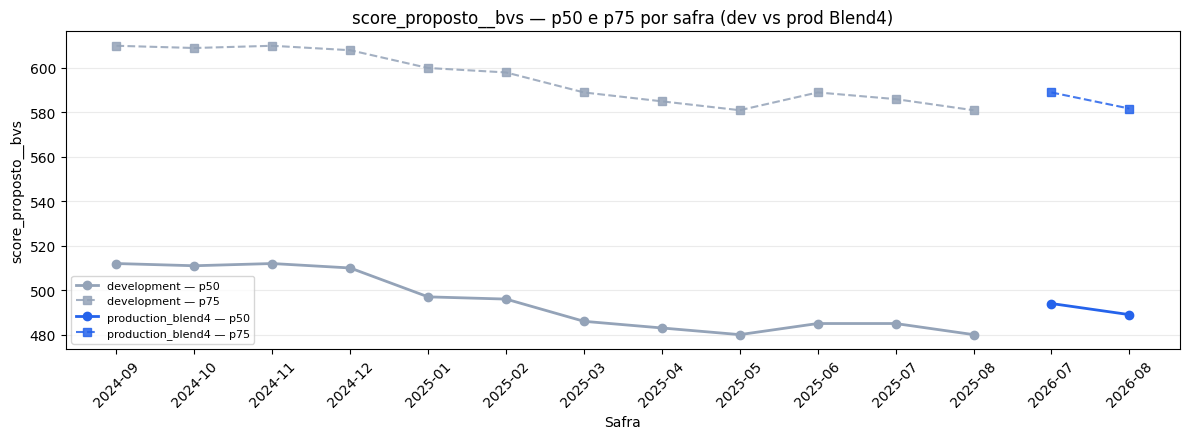

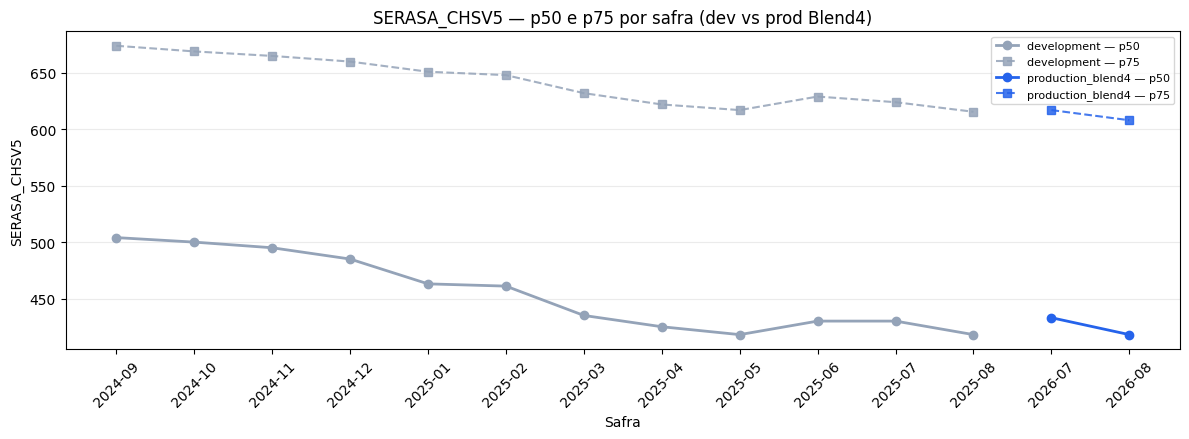

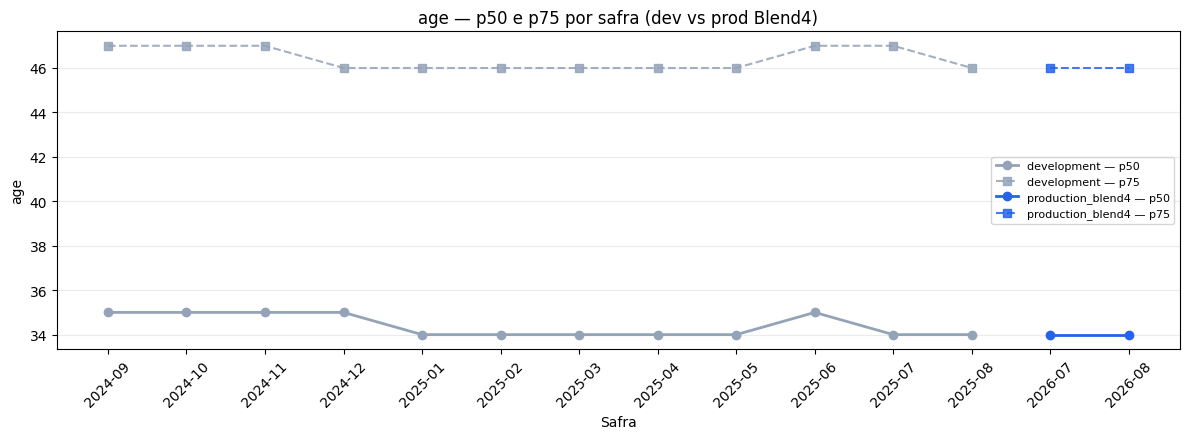

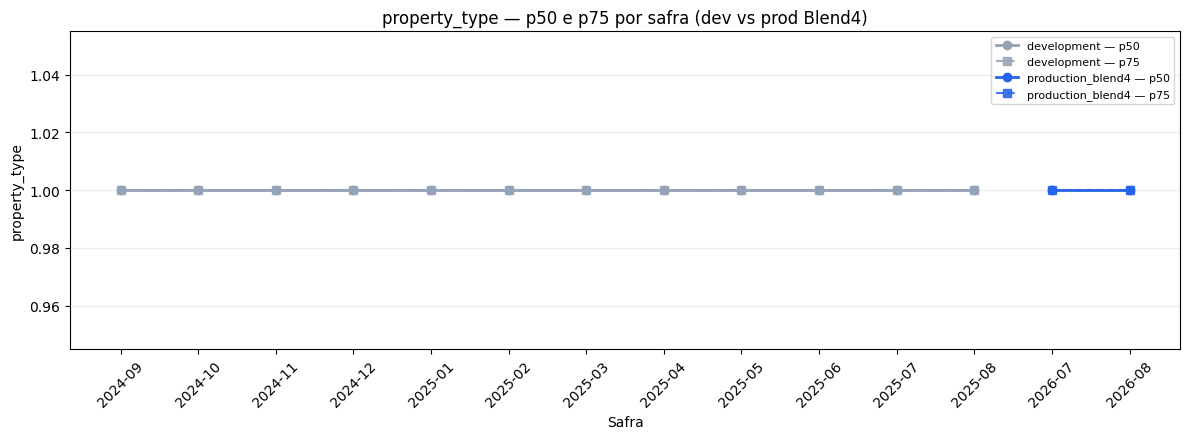

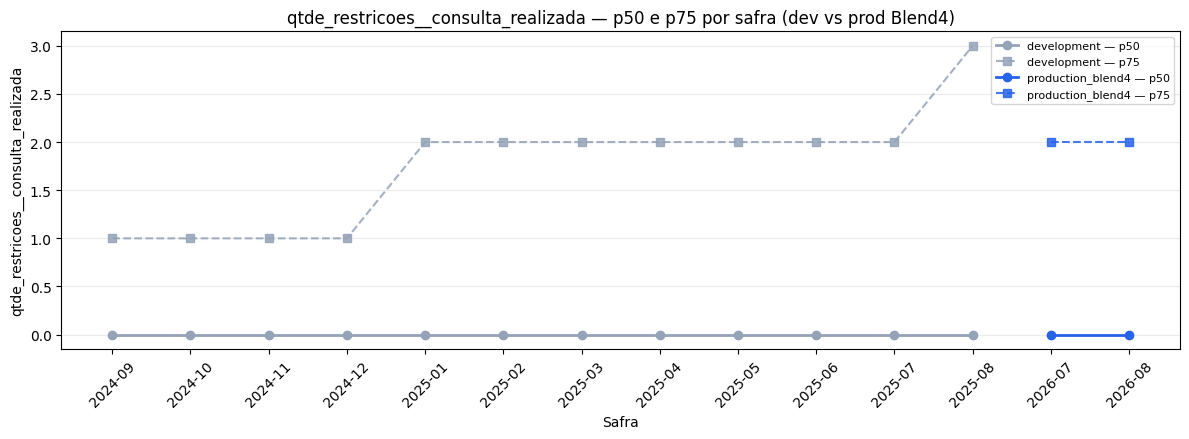

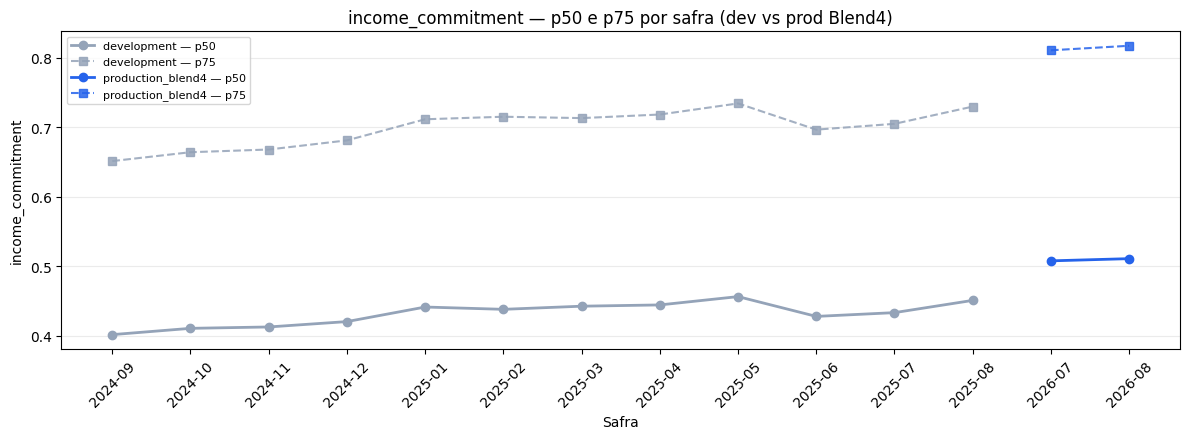

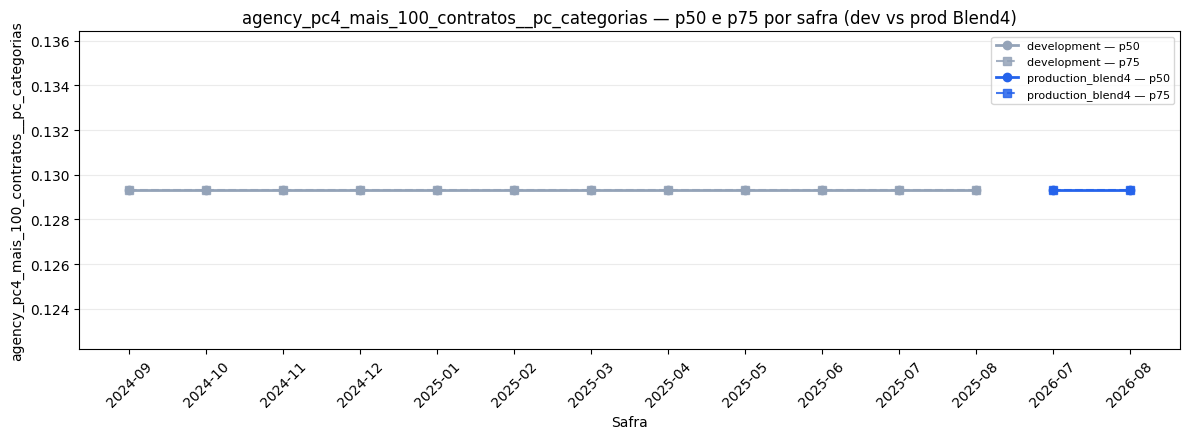

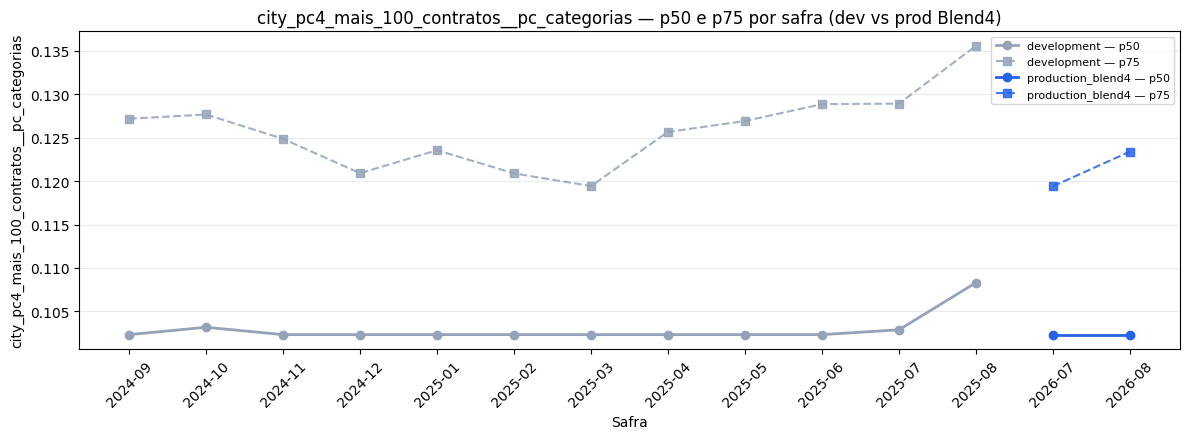

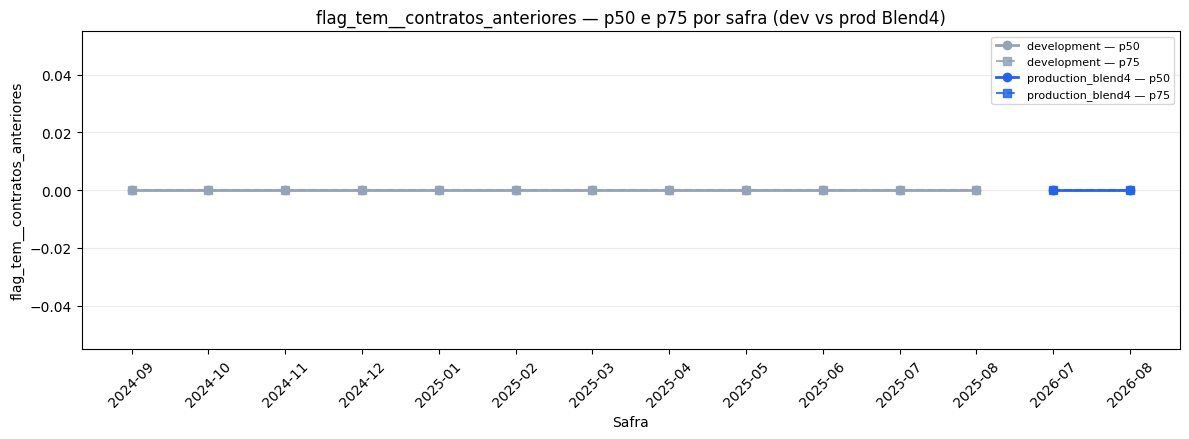

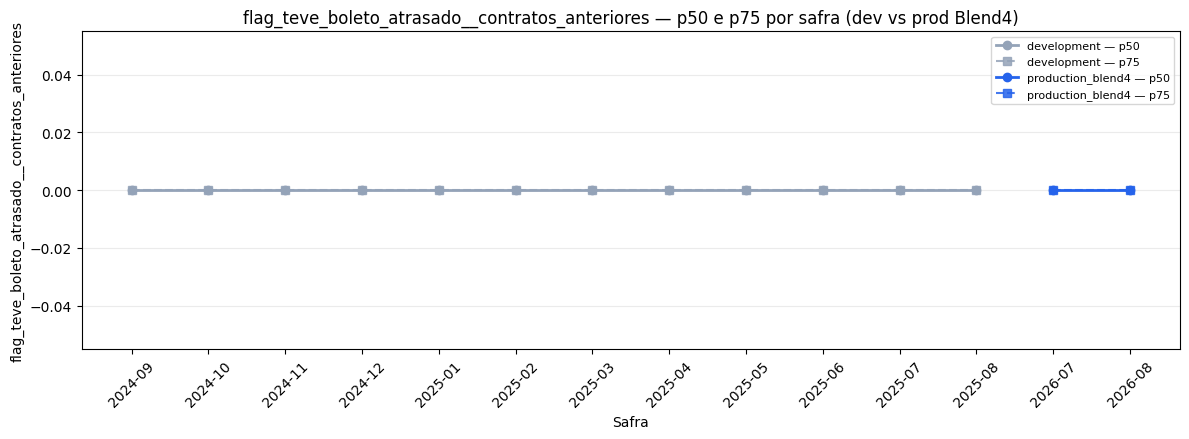

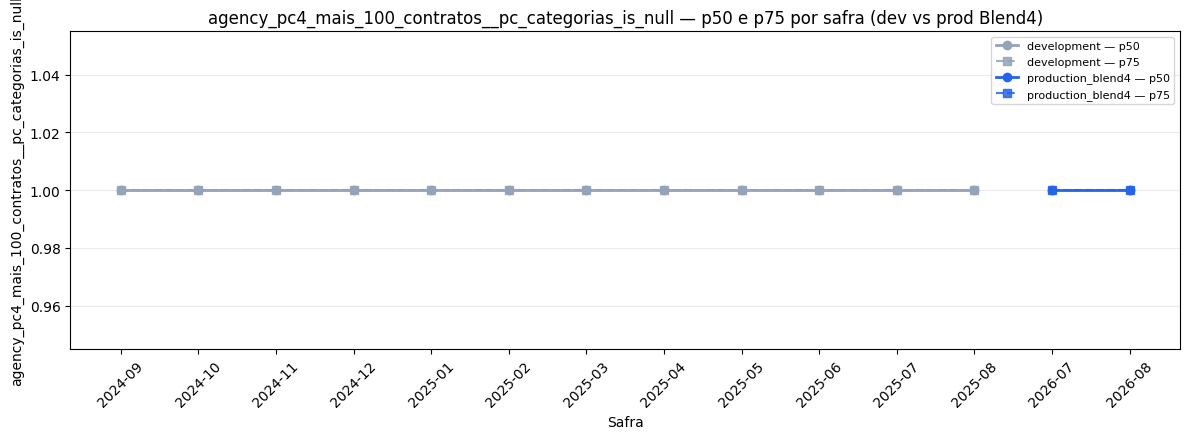

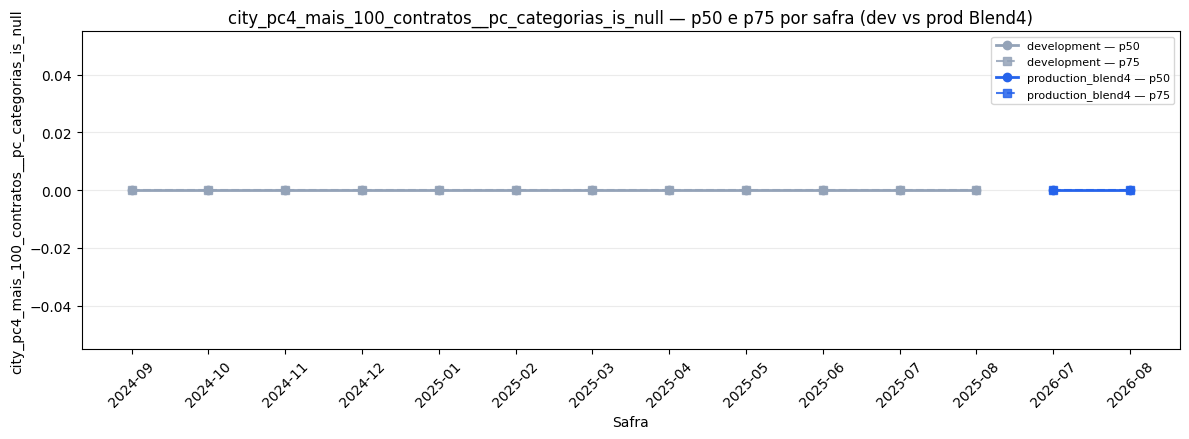

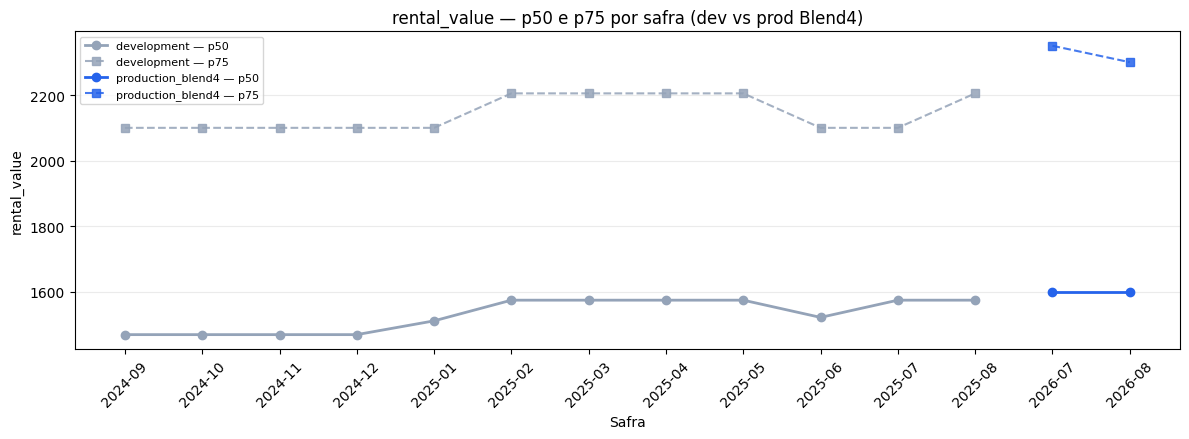

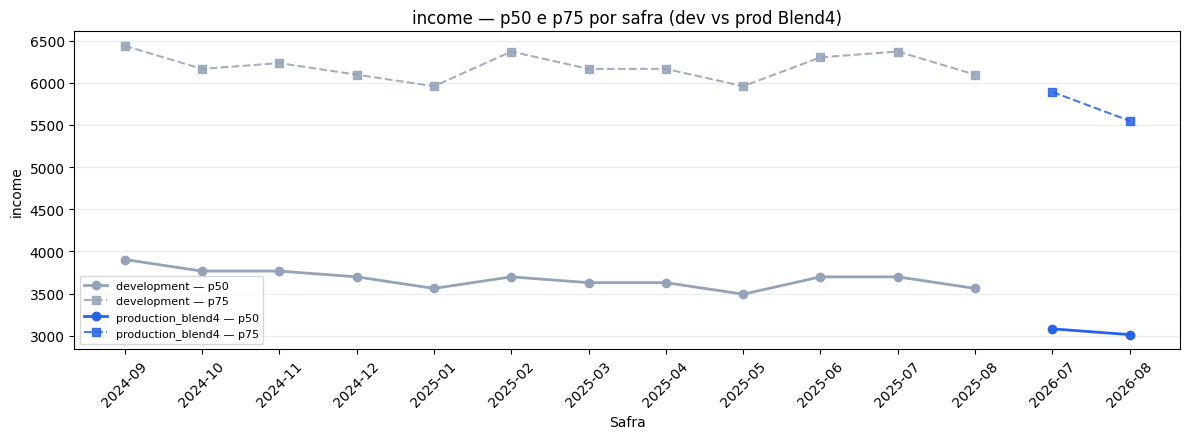

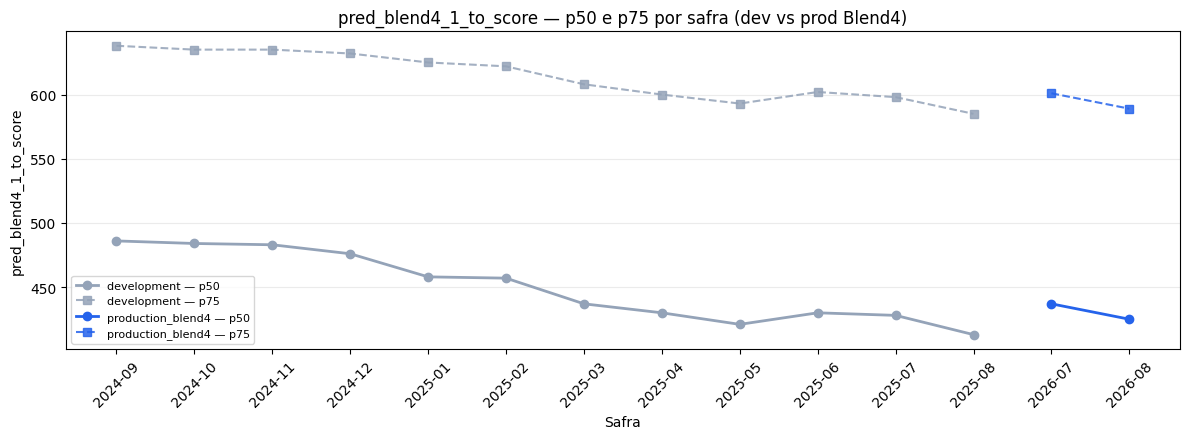

In [18]:
COLORS = {
    "development": "#94A3B8",
    "production_blend4": "#2563EB",
}

for var in model_vars:
    g = pct_by_safra[pct_by_safra["variable"] == var].copy()
    if g.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 4.5))

    for base, color in COLORS.items():
        gb = g[g["base"] == base].sort_values("safra")
        if gb.empty:
            continue
        ax.plot(
            gb["safra"],
            gb["p50"],
            marker="o",
            linewidth=2,
            color=color,
            label=f"{base} — p50",
        )
        ax.plot(
            gb["safra"],
            gb["p75"],
            marker="s",
            linewidth=1.5,
            linestyle="--",
            color=color,
            alpha=0.85,
            label=f"{base} — p75",
        )

    ax.set_title(f"{var} — p50 e p75 por safra (dev vs prod Blend4)")
    ax.set_xlabel("Safra")
    ax.set_ylabel(var)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

#### Visão semanal — dev (S1–S4) × prod (semanas domingo→sábado)

Semana = **domingo → sábado** (`week_start` = domingo).

- **S1–S4:** ordem dos **domingos que caem no mês** do `week_start` (1º domingo do mês = S1). Evita o “pulo” S4→S2 na virada do mês.
- **Produção temporal:** agregado por `year_week` (rótulo = domingo de início).
- Métricas: **p50 e p75** (sem média — outliers distorcem).


In [19]:
from funcoes_monitoramento import prepare_week_columns, _sunday_week_start

WEEK_METRICS = ["p50", "p75"]


def _first_sunday_on_or_after(dates: pd.Series) -> pd.Series:
    """First Sunday on/after each date (Sunday stays Sunday)."""
    dates = pd.to_datetime(dates)
    days_until_sunday = (6 - dates.dt.dayofweek) % 7
    return (dates + pd.to_timedelta(days_until_sunday, unit="D")).dt.normalize()


def _add_week_of_month(df: pd.DataFrame, date_col: str = "requested_at") -> pd.DataFrame:
    """
    Assign S1–S4 from Sunday–Saturday weeks labeled by week_start's month.

    S1 = first Sunday that falls in the calendar month of week_start.
    Spillover days whose Sunday is in the previous month keep that previous-month S#.
    Weeks beyond S4 fold into S4.
    """
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")

    if "week_start" not in out.columns:
        out = prepare_week_columns(out, date_col=date_col)

    month_start = out["week_start"].dt.to_period("M").dt.start_time
    first_sunday_in_month = _first_sunday_on_or_after(month_start)

    wom = ((out["week_start"] - first_sunday_in_month).dt.days // 7 + 1).clip(lower=1, upper=4)
    out["week_of_month"] = wom.astype("Int64")
    out["week_label"] = out["week_of_month"].map(
        lambda x: f"S{int(x)}" if pd.notna(x) else np.nan
    )
    out["week_month"] = out["week_start"].dt.strftime("%Y-%m")
    out["week_label_full"] = out["week_month"] + "|" + out["week_label"]
    if "week_end" not in out.columns:
        out["week_end"] = out["week_start"] + pd.Timedelta(days=6)
    return out



def weekly_metric_table(
    df: pd.DataFrame,
    variables: list,
    group_col: str,
    label: str,
) -> pd.DataFrame:
    rows = []
    for key, g in df.groupby(group_col, sort=True):
        for var in variables:
            if var not in g.columns:
                continue
            s = pd.to_numeric(g[var], errors="coerce")
            rows.append(
                {
                    "period": key,
                    "variable": var,
                    "base": label,
                    "n": int(s.notna().sum()),
                    "p50": s.quantile(0.50),
                    "p75": s.quantile(0.75),
                }
            )
    return pd.DataFrame(rows)


# Development: Sunday–Saturday weeks + S1–S4
df_dev_week = df_raw_dev[["contract_id", "requested_at", "safra"] + model_vars].copy()
df_dev_week = prepare_week_columns(df_dev_week, date_col="requested_at")
df_dev_week = _add_week_of_month(df_dev_week, "requested_at")

# Production Blend4: Sunday–Saturday weeks + S1–S4 tag
df_prod_week_stats = df_blend4_dev.loc[
    df_blend4_dev["message_decisao"] == "BLEND_4",
    ["contract_id", "requested_at", "safra"] + model_vars,
].copy()
df_prod_week_stats = prepare_week_columns(df_prod_week_stats, date_col="requested_at")
df_prod_week_stats = _add_week_of_month(df_prod_week_stats, "requested_at")

assert (df_dev_week["week_start"].dt.dayofweek == 6).all(), "dev week_start must be Sunday"
assert (df_prod_week_stats["week_start"].dt.dayofweek == 6).all(), "prod week_start must be Sunday"
assert (df_prod_week_stats["week_end"].dt.dayofweek == 5).all(), "prod week_end must be Saturday"

# Aggregations
dev_by_s = weekly_metric_table(df_dev_week, model_vars, "week_label", "development")
prod_by_s = weekly_metric_table(df_prod_week_stats, model_vars, "week_label", "production_blend4")
prod_by_week = weekly_metric_table(
    df_prod_week_stats, model_vars, "year_week", "production_blend4"
)

week_meta = (
    df_prod_week_stats.groupby("year_week", as_index=False)
    .agg(
        week_start=("week_start", "first"),
        week_end=("week_end", "first"),
        week_label=("week_label", "first"),
        week_month=("week_month", "first"),
        week_label_full=("week_label_full", "first"),
        n_rows=("year_week", "size"),
    )
)
prod_by_week = prod_by_week.merge(
    week_meta.rename(columns={"year_week": "period"}),
    on="period",
    how="left",
)

seasonality_cmp = pd.concat([dev_by_s, prod_by_s], ignore_index=True)
print(
    f"Dev S1–S4 volumes (Sun–Sat):\n{df_dev_week['week_label'].value_counts().sort_index().to_string()}"
)
print(
    f"\nProd Blend4 weeks: {df_prod_week_stats['year_week'].nunique()} "
    f"({df_prod_week_stats['week_start'].min().date()} → {df_prod_week_stats['week_end'].max().date()})"
)

# Spot-check: each year_week is exactly Sun→Sat
_chk = (
    df_prod_week_stats.groupby("year_week")
    .agg(ws=("week_start", "first"), we=("week_end", "first"))
    .assign(
        is_sunday=lambda d: d["ws"].dt.dayofweek == 6,
        is_saturday=lambda d: d["we"].dt.dayofweek == 5,
        span_days=lambda d: (d["we"] - d["ws"]).dt.days,
    )
)
assert _chk["is_sunday"].all() and _chk["is_saturday"].all() and (_chk["span_days"] == 6).all()
print("Week check OK: all production year_week spans are Sunday→Saturday (7 days).")

display(seasonality_cmp.sort_values(["variable", "base", "period"]).head(24))
display(prod_by_week.sort_values(["variable", "week_start"]).head(24))


Dev S1–S4 volumes (Sun–Sat):
week_label
S1    241865
S2    243590
S3    256480
S4    328301

Prod Blend4 weeks: 8 (2026-06-28 → 2026-08-22)
Week check OK: all production year_week spans are Sunday→Saturday (7 days).


,period,variable,base,n,p50,p75
1,S1,SERASA_CHSV5,development,241865,445.00000,636.00000
16,S2,SERASA_CHSV5,development,243590,449.00000,641.00000
31,S3,SERASA_CHSV5,development,256480,445.00000,638.00000
46,S4,SERASA_CHSV5,development,328301,439.00000,634.00000
61,S1,SERASA_CHSV5,production_blend4,16071,416.00000,605.00000
76,S2,SERASA_CHSV5,production_blend4,17136,427.00000,615.00000
91,S3,SERASA_CHSV5,production_blend4,4324,433.00000,610.00000
106,S4,SERASA_CHSV5,production_blend4,5276,435.00000,619.00000
2,S1,age,development,241865,34.00000,46.00000
17,S2,age,development,243590,35.00000,47.00000


,period,variable,base,n,p50,p75,week_start,week_end,week_label,week_month,week_label_full,n_rows
1,2026-06-28,SERASA_CHSV5,production_blend4,390,482.00000,635.50000,2026-06-28,2026-07-04,S4,2026-06,2026-06|S4,390
16,2026-07-05,SERASA_CHSV5,production_blend4,2476,421.00000,602.00000,2026-07-05,2026-07-11,S1,2026-07,2026-07|S1,2476
31,2026-07-12,SERASA_CHSV5,production_blend4,3997,435.00000,629.00000,2026-07-12,2026-07-18,S2,2026-07,2026-07|S2,3997
46,2026-07-19,SERASA_CHSV5,production_blend4,4182,435.00000,610.00000,2026-07-19,2026-07-25,S3,2026-07,2026-07|S3,4182
61,2026-07-26,SERASA_CHSV5,production_blend4,4886,432.00000,617.00000,2026-07-26,2026-08-01,S4,2026-07,2026-07|S4,4886
76,2026-08-02,SERASA_CHSV5,production_blend4,13595,415.00000,607.00000,2026-08-02,2026-08-08,S1,2026-08,2026-08|S1,13595
91,2026-08-09,SERASA_CHSV5,production_blend4,13139,423.00000,612.00000,2026-08-09,2026-08-15,S2,2026-08,2026-08|S2,13139
106,2026-08-16,SERASA_CHSV5,production_blend4,142,403.50000,604.75000,2026-08-16,2026-08-22,S3,2026-08,2026-08|S3,142
2,2026-06-28,age,production_blend4,390,34.00000,46.75000,2026-06-28,2026-07-04,S4,2026-06,2026-06|S4,390
17,2026-07-05,age,production_blend4,2476,35.00000,48.00000,2026-07-05,2026-07-11,S1,2026-07,2026-07|S1,2476


##### 1) Comparação S1–S4 (dev × prod) — mesmo eixo de semana do mês (domingo→sábado)

Mesma lógica do gráfico por safra: um gráfico por variável, com **p50 / p75**.

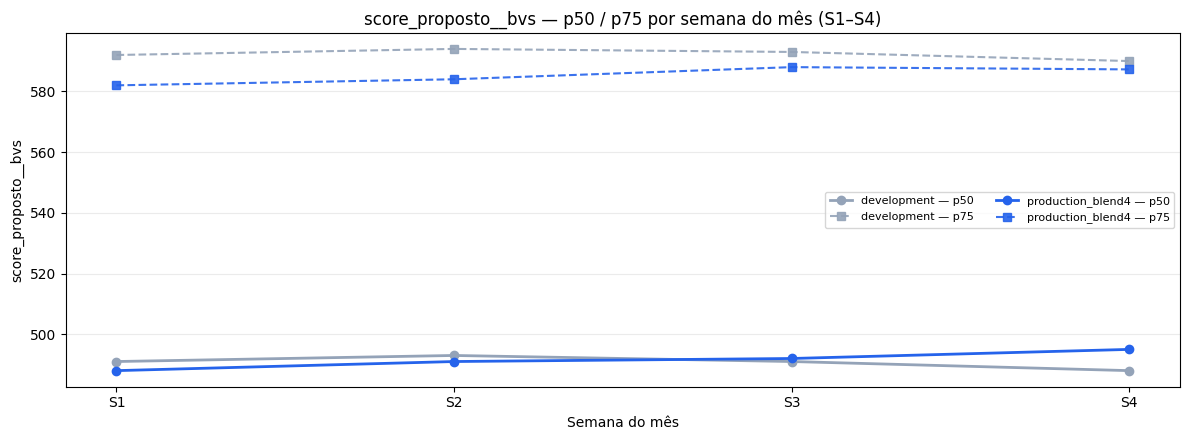

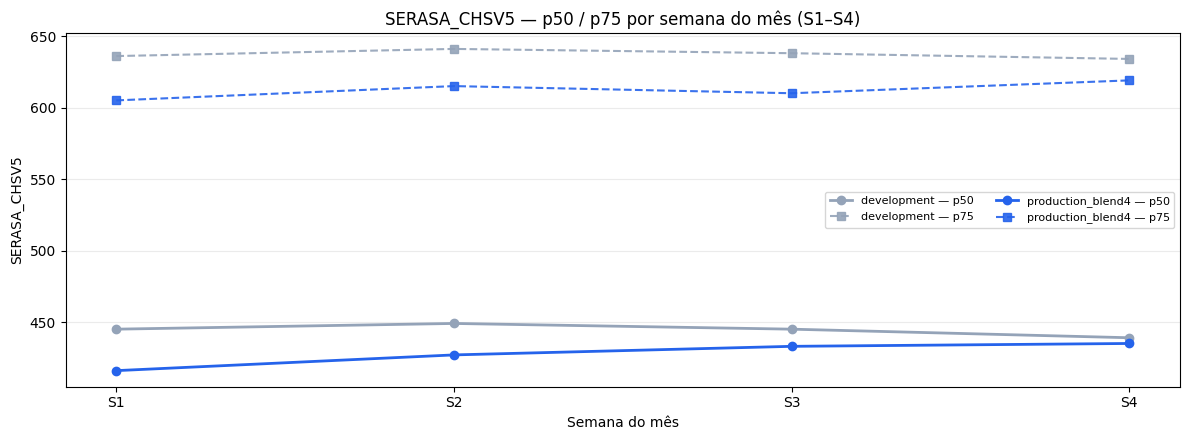

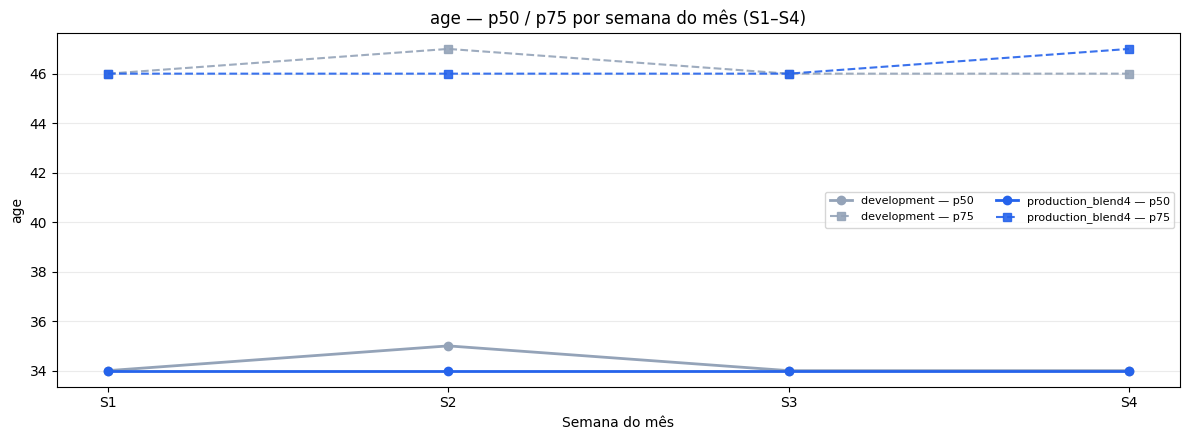

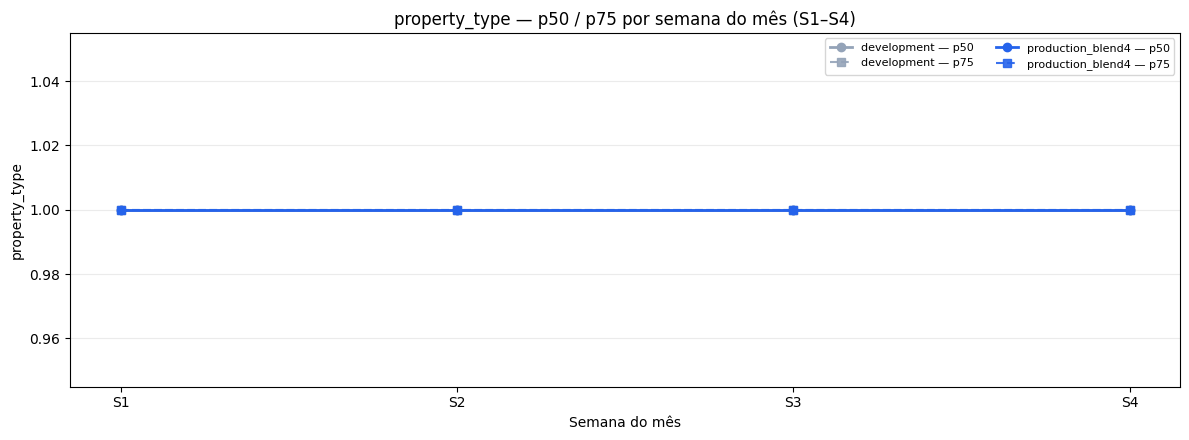

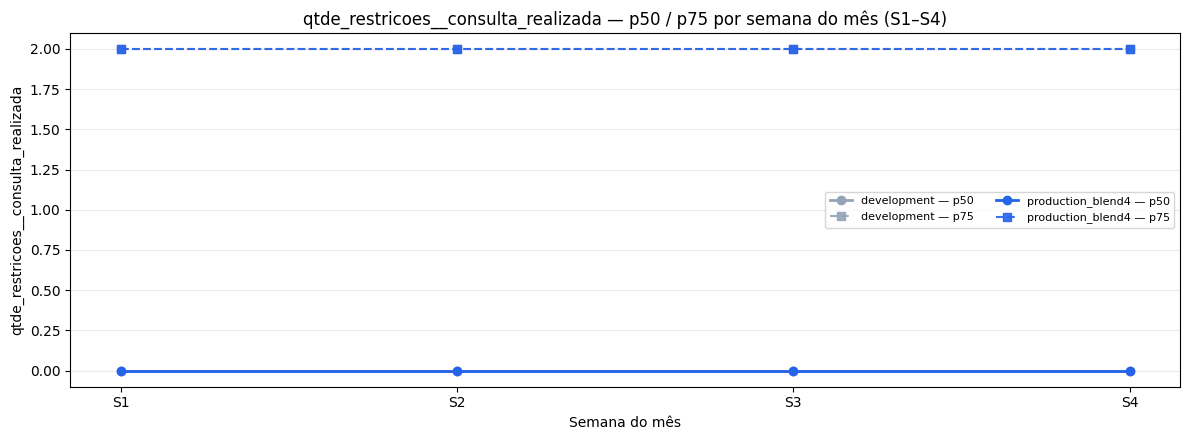

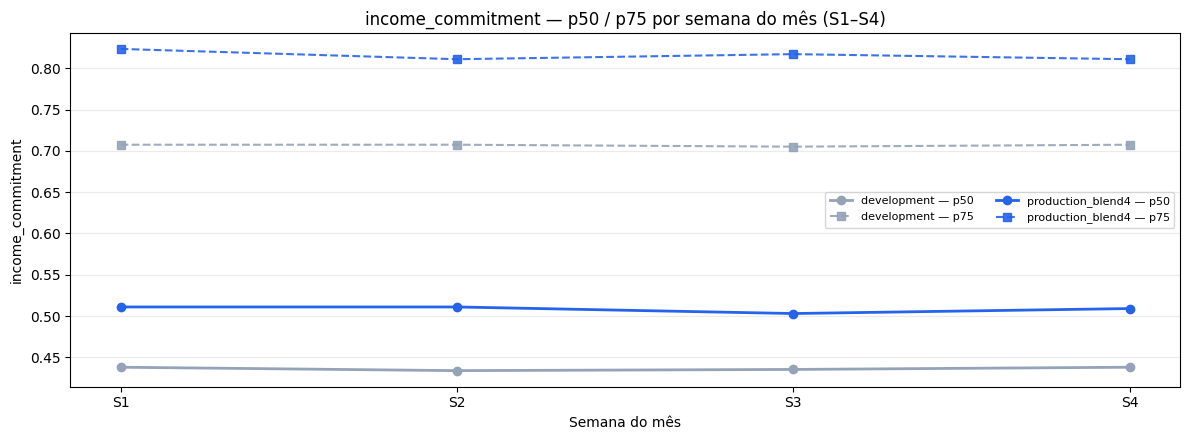

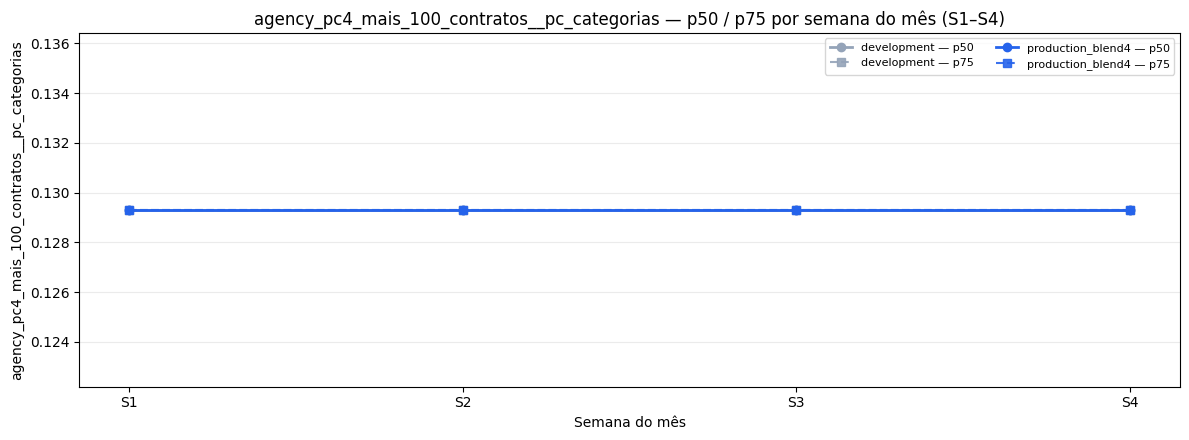

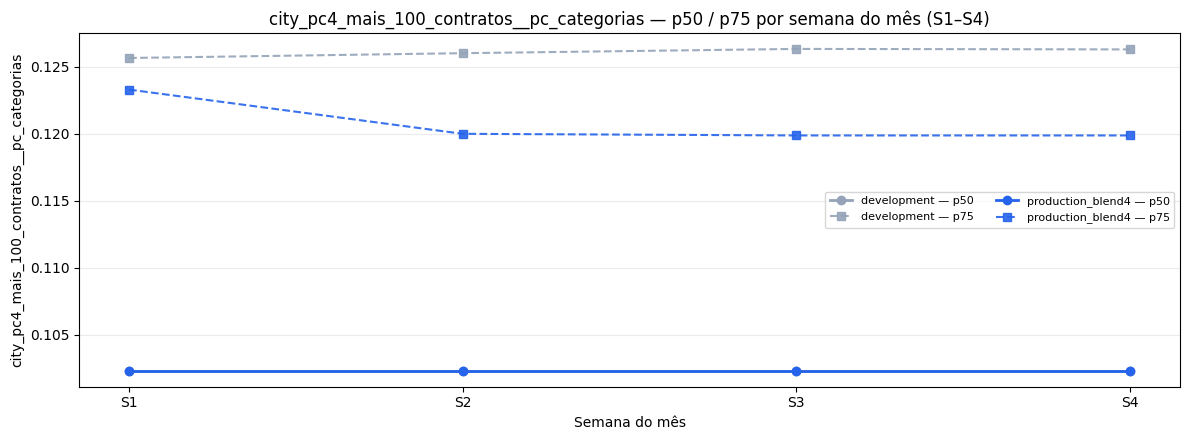

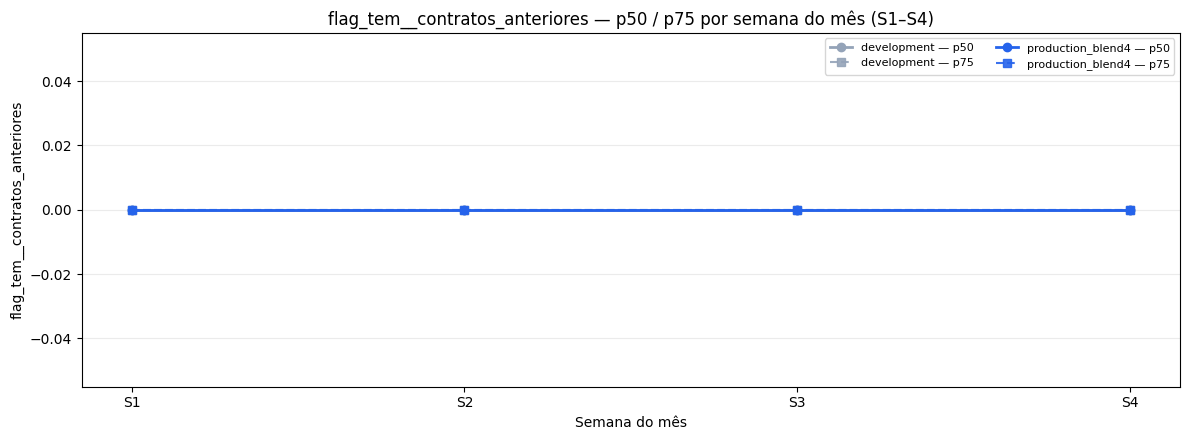

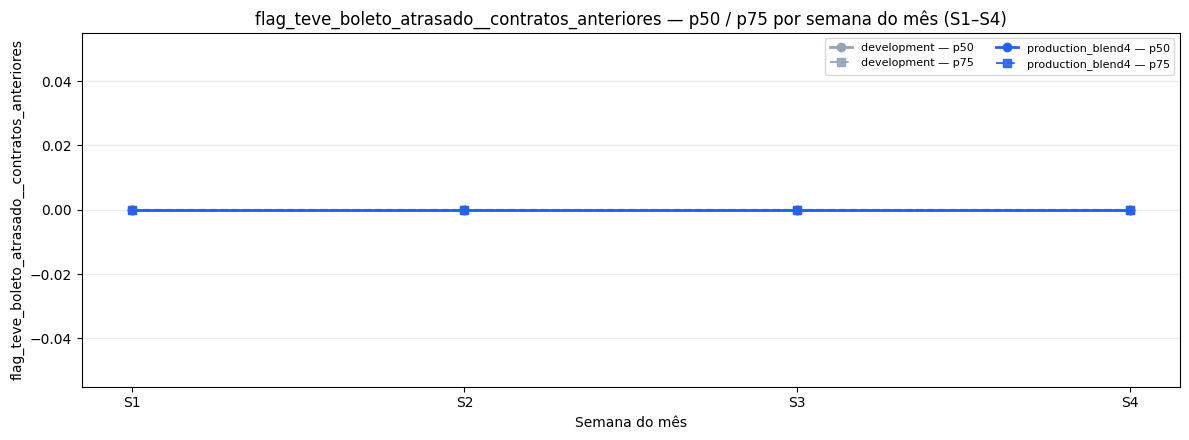

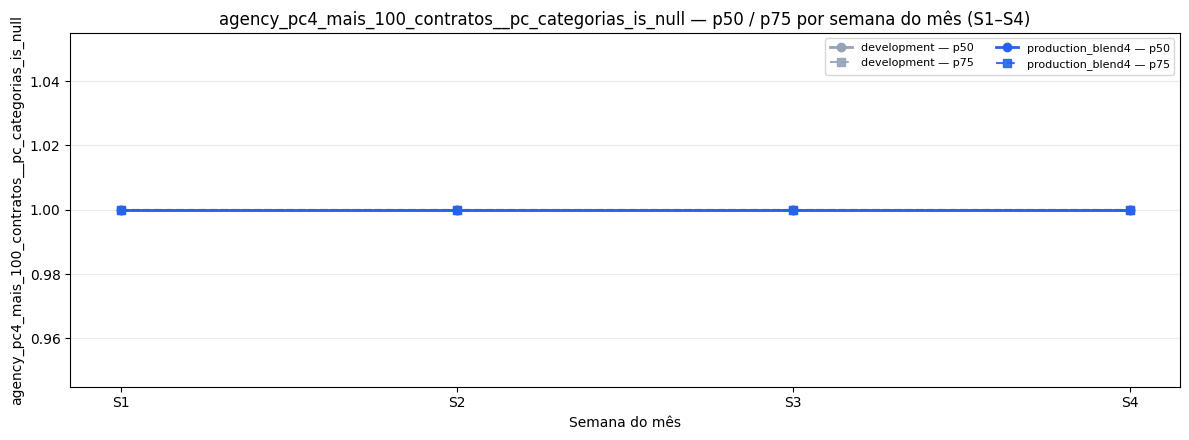

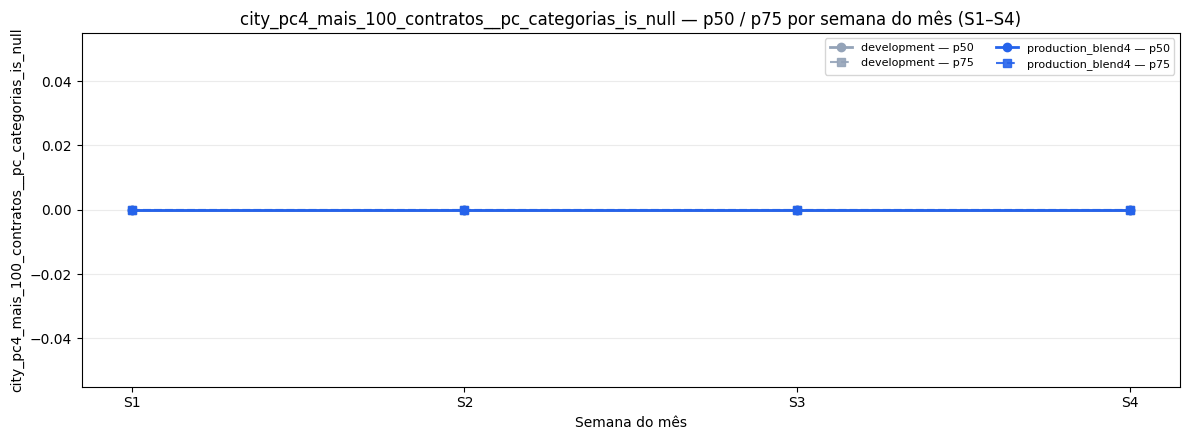

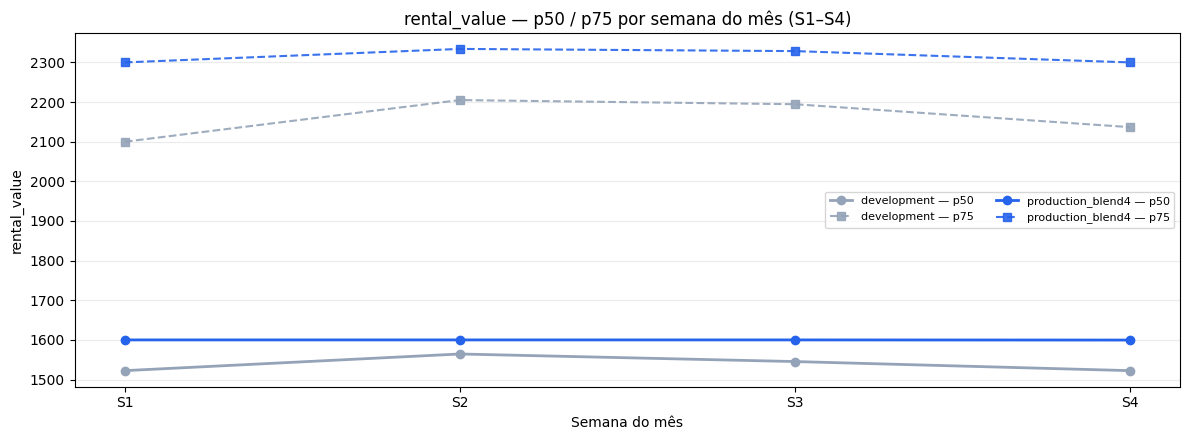

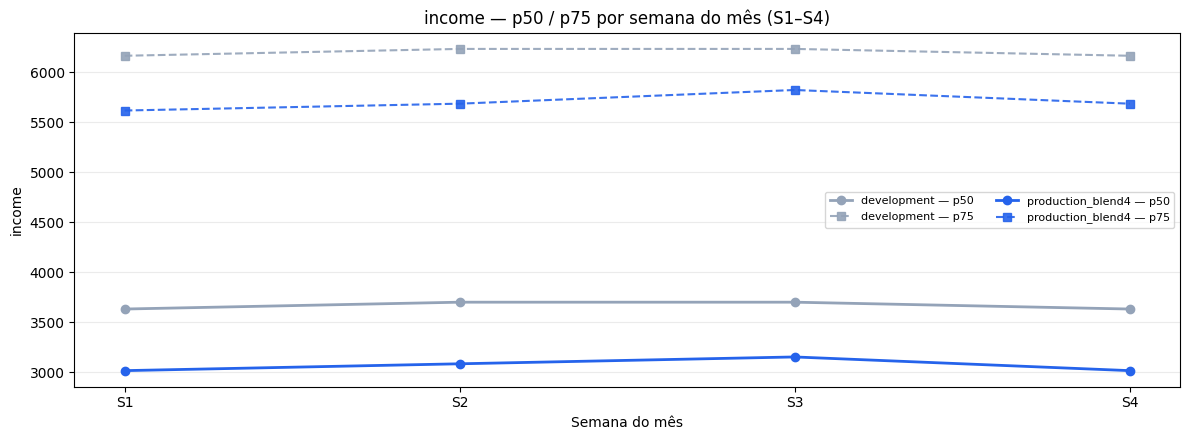

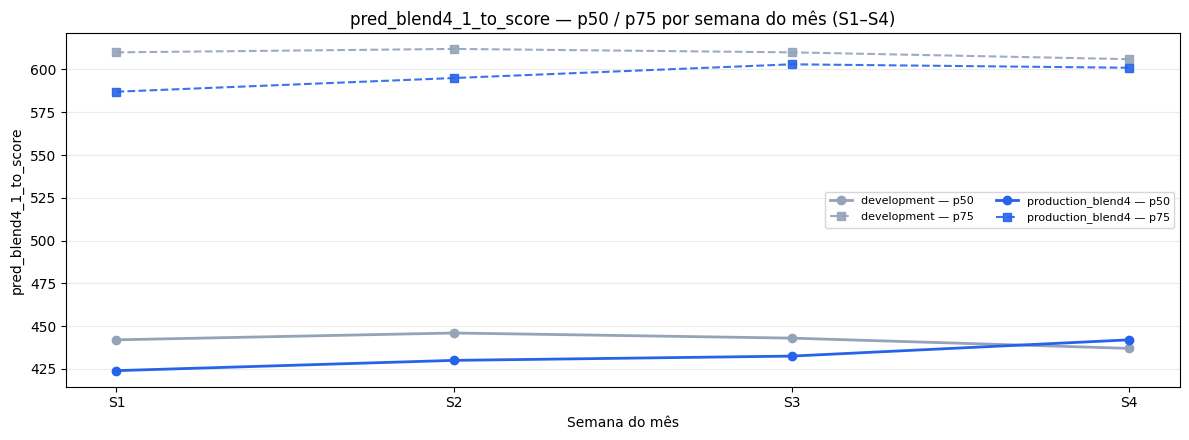

In [20]:
S_ORDER = ["S1", "S2", "S3", "S4"]
BASE_COLORS = {
    "development": "#94A3B8",
    "production_blend4": "#2563EB",
}
METRIC_STYLE = {
    "p50": {"linestyle": "-", "marker": "o", "alpha": 1.0},
    "p75": {"linestyle": "--", "marker": "s", "alpha": 0.9},
}

for var in model_vars:
    g = seasonality_cmp[seasonality_cmp["variable"] == var].copy()
    if g.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 4.5))
    for base, color in BASE_COLORS.items():
        gb = g[g["base"] == base].set_index("period").reindex(S_ORDER)
        for metric, style in METRIC_STYLE.items():
            ax.plot(
                S_ORDER,
                gb[metric],
                color=color,
                linewidth=2 if metric == "p50" else 1.5,
                label=f"{base} — {metric}",
                **style,
            )

    ax.set_title(f"{var} — p50 / p75 por semana do mês (S1–S4)")
    ax.set_xlabel("Semana do mês")
    ax.set_ylabel(var)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

##### 2) Visão temporal — produção por semana (domingo→sábado)

Eixo X = semanas reais (`year_week`). Azul = prod (**p50 / p75**).

Cinza = referência do desenvolvimento no **mesmo S do domingo da semana**. Rótulo = `YYYY-MM|S#` (sem “pulo” visual na virada do mês).


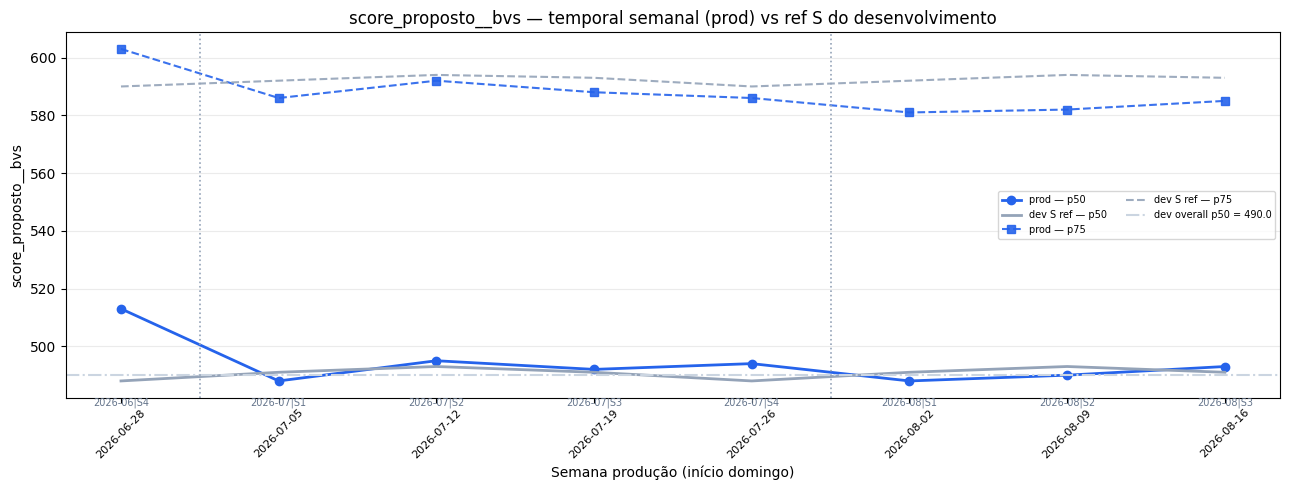

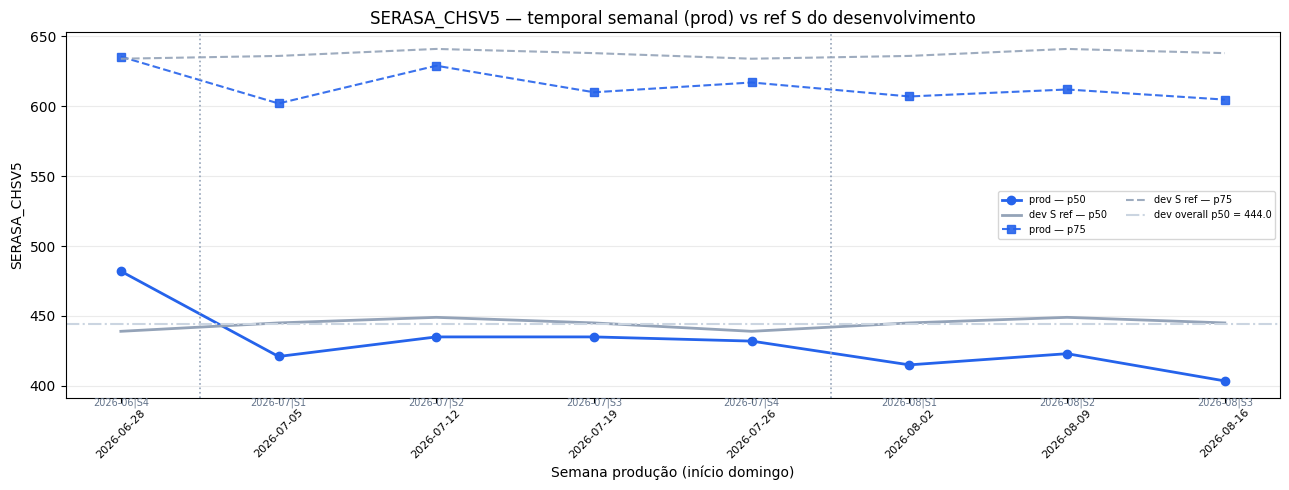

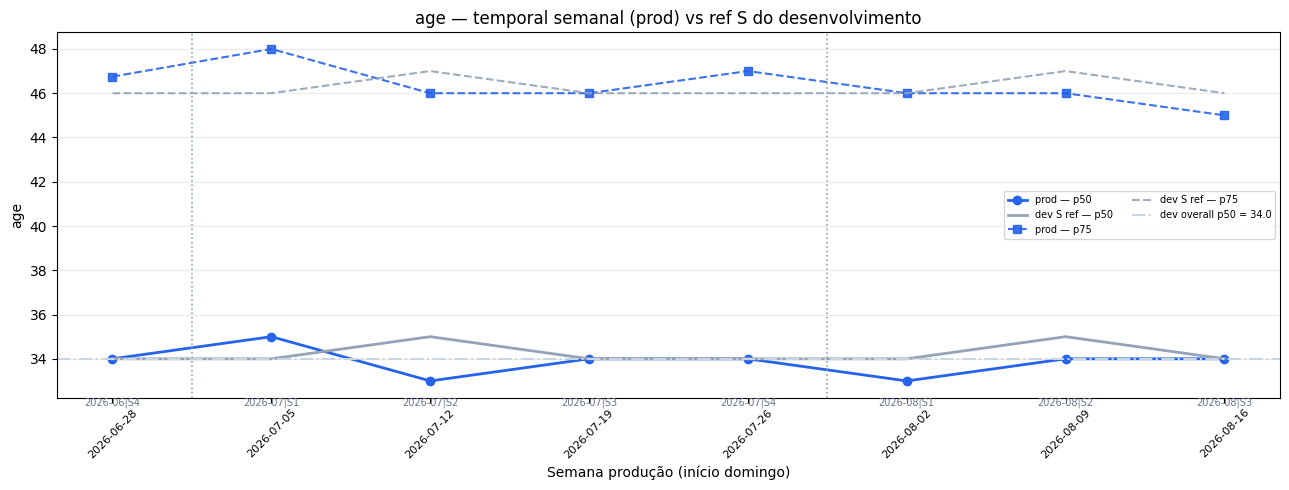

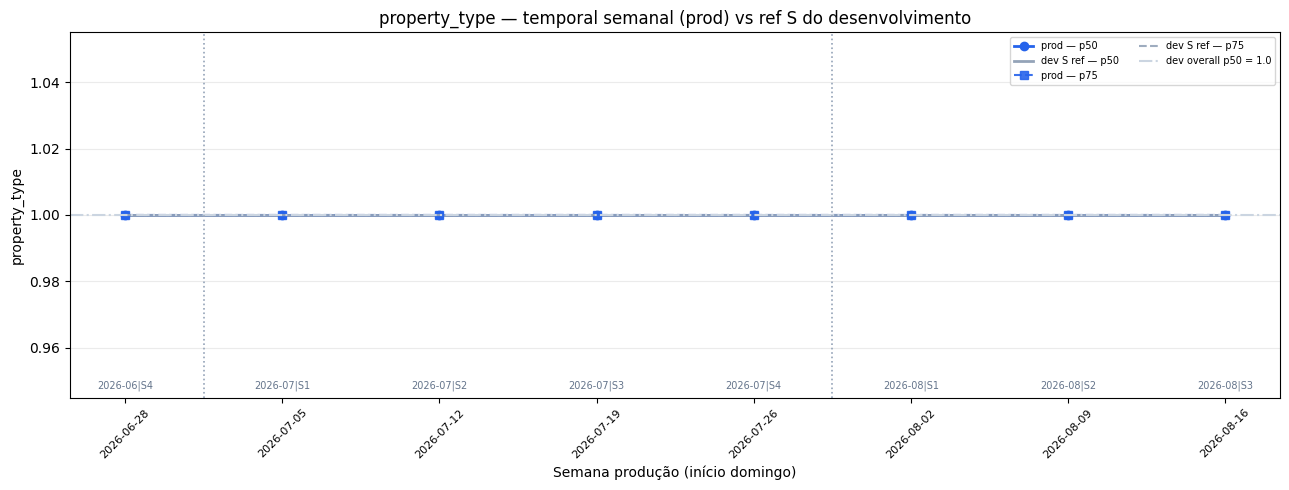

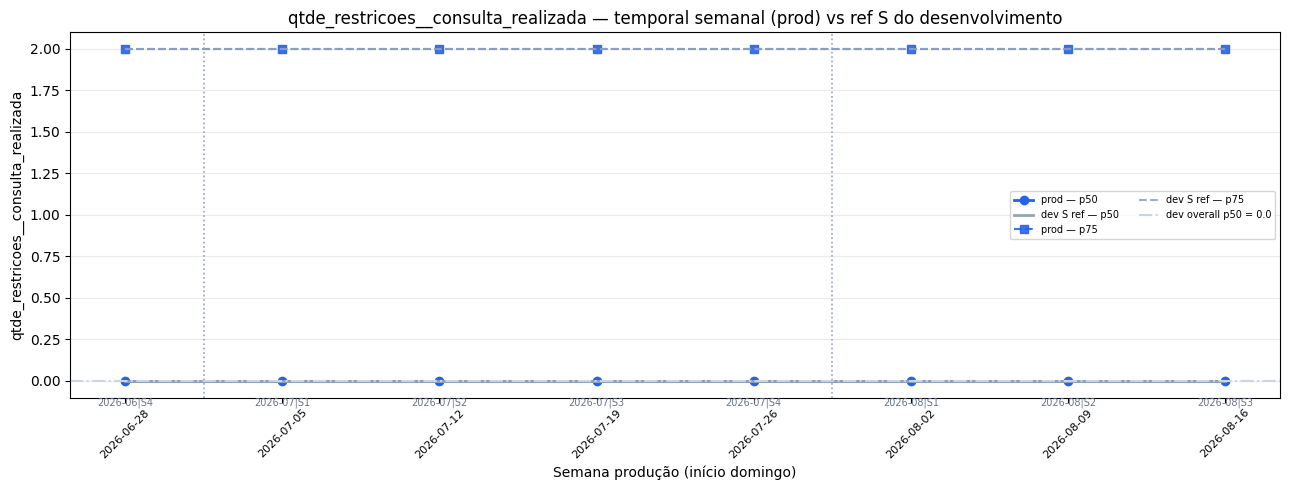

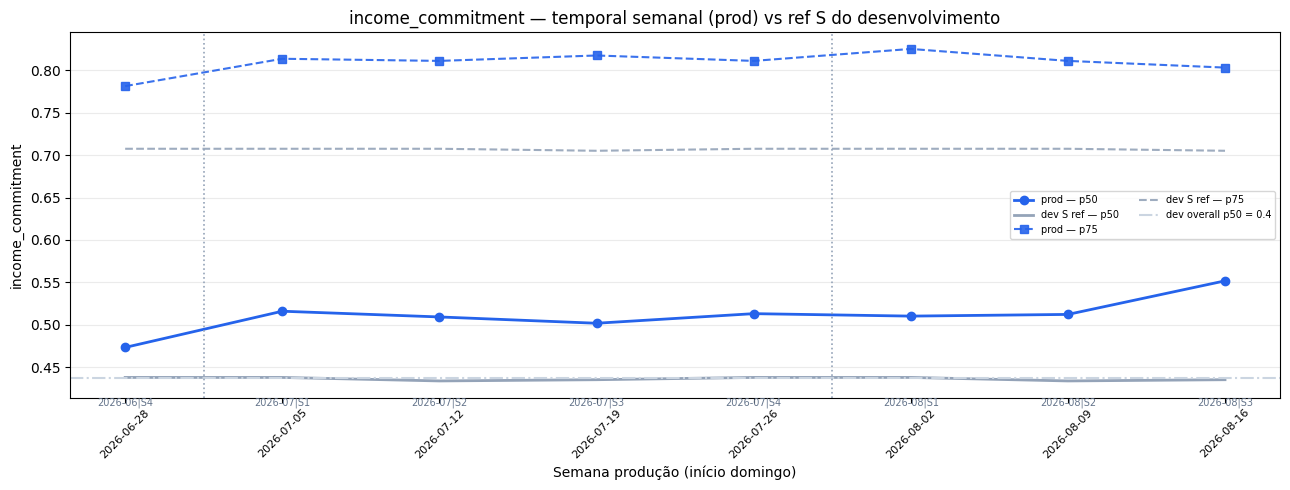

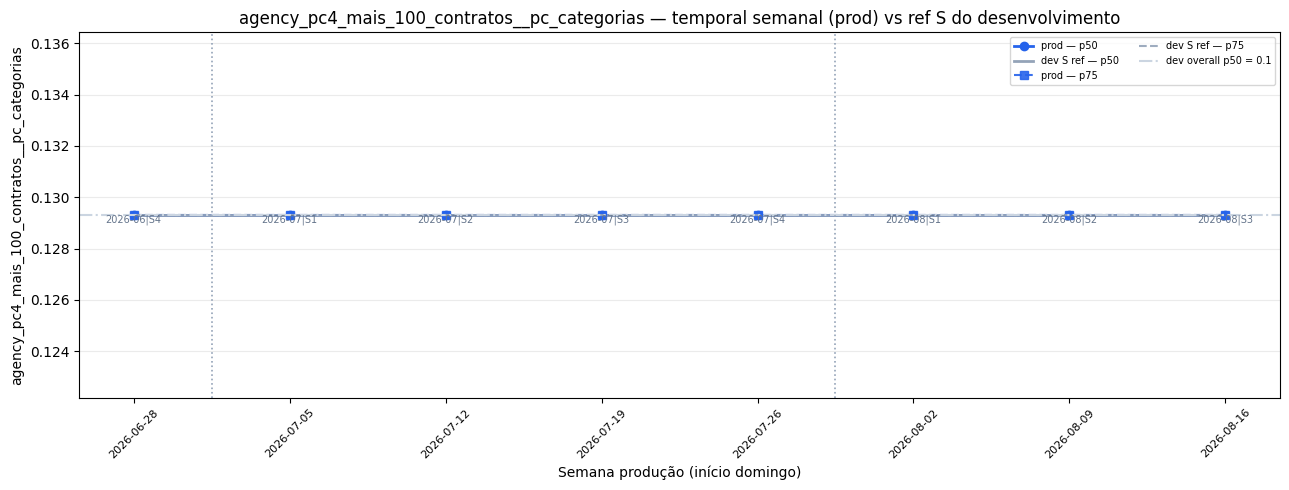

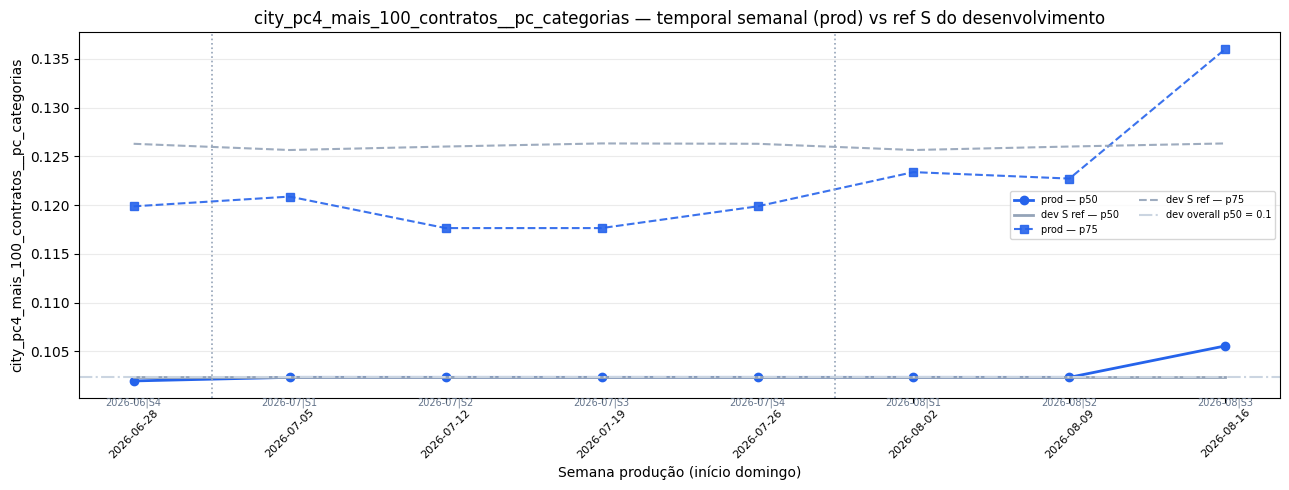

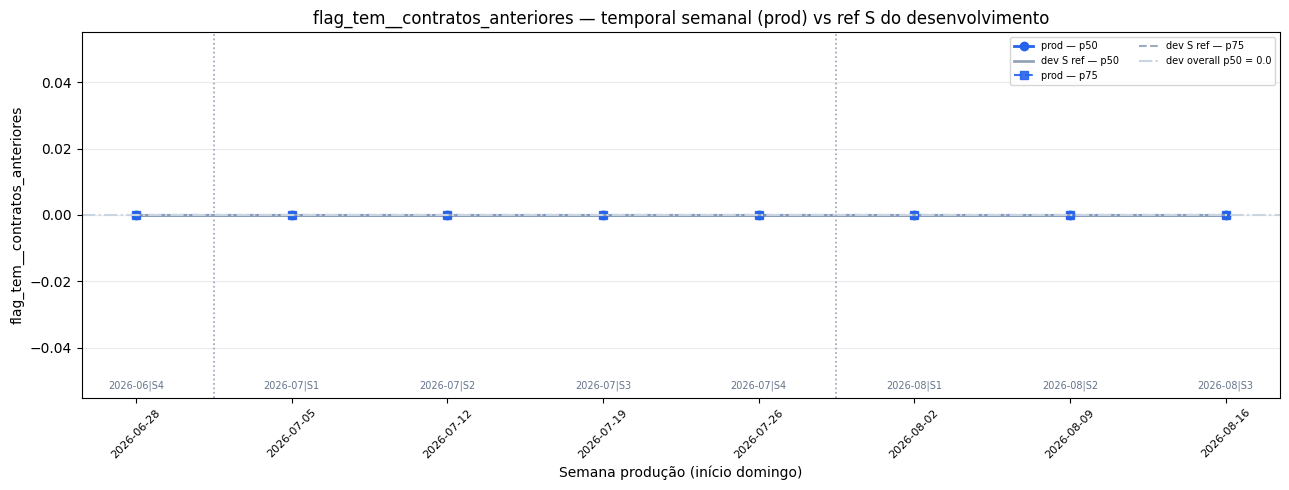

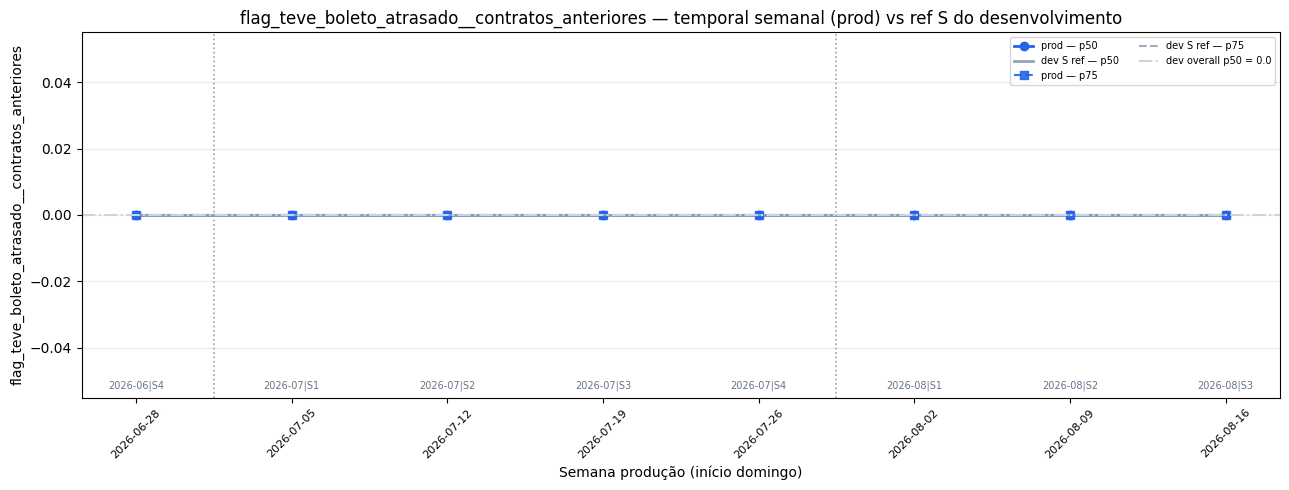

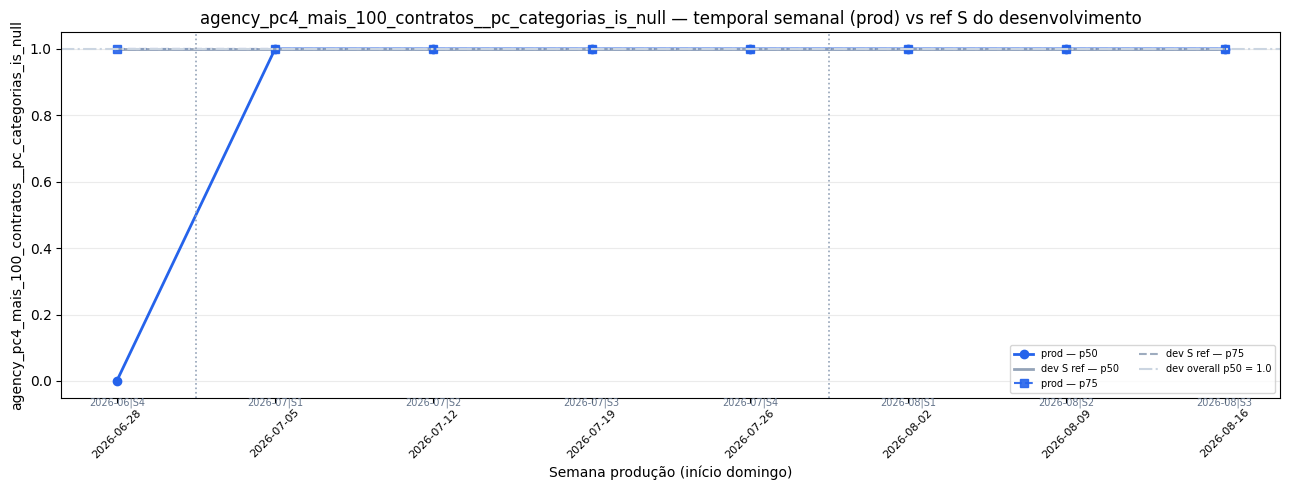

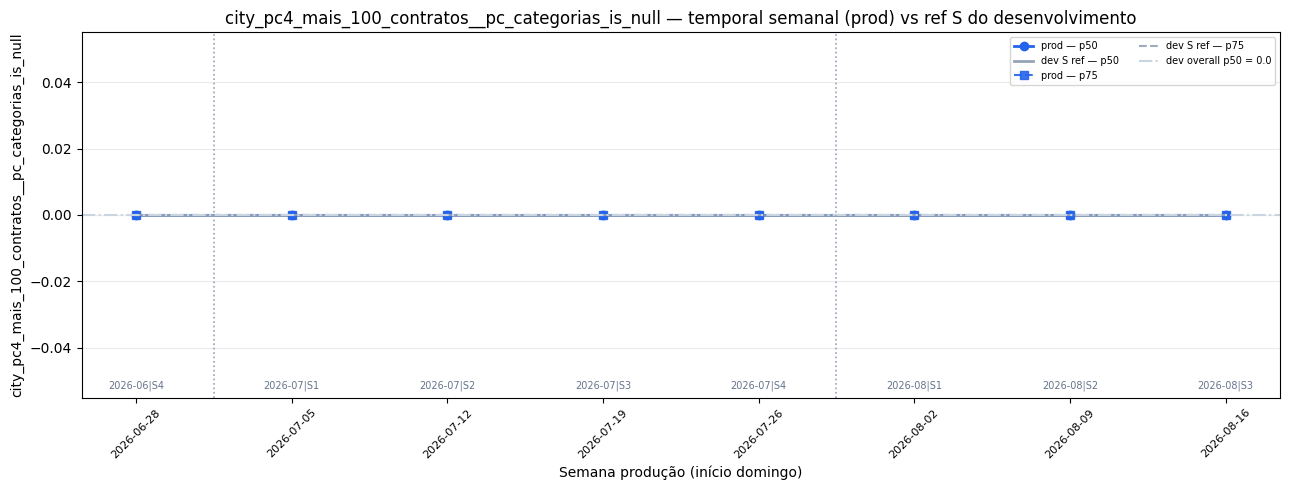

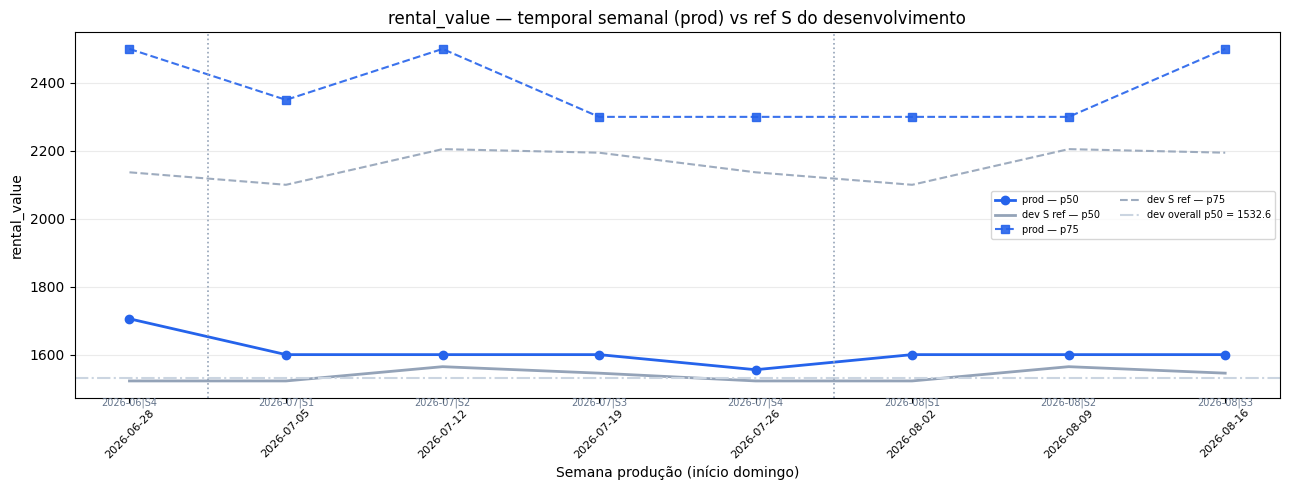

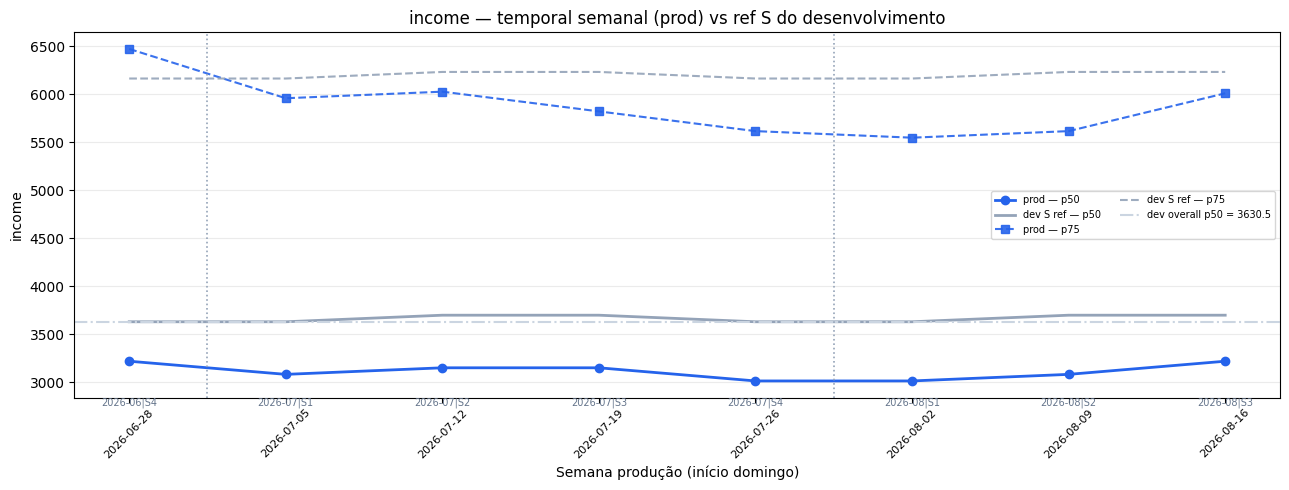

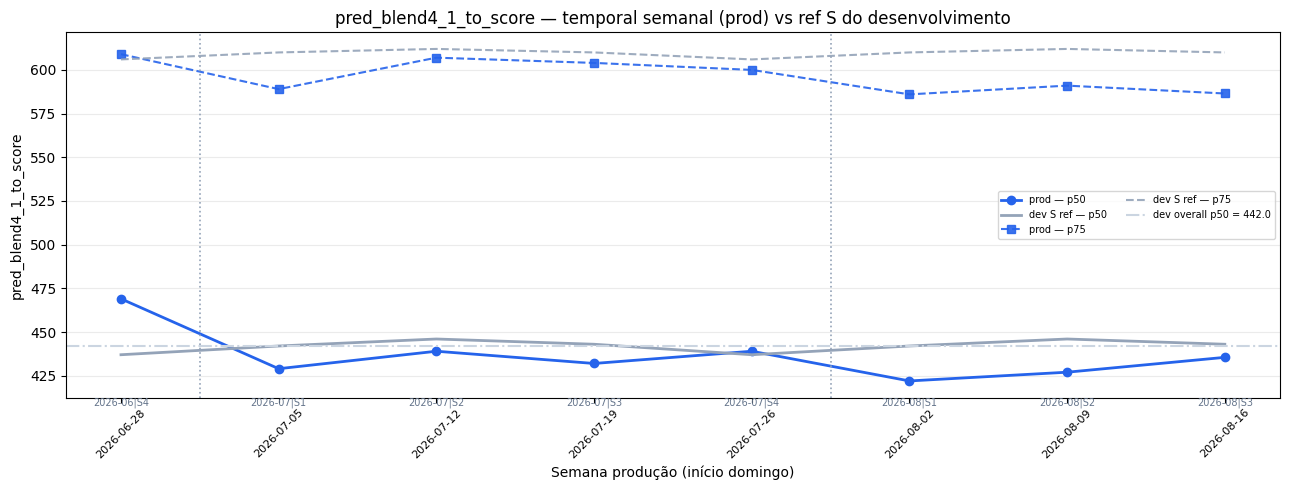

In [21]:
dev_overall_rows = []
for var in model_vars:
    s = pd.to_numeric(df_dev_week[var], errors="coerce")
    dev_overall_rows.append(
        {"variable": var, "p50": s.quantile(0.50), "p75": s.quantile(0.75)}
    )
dev_overall = pd.DataFrame(dev_overall_rows).set_index("variable")

for var in model_vars:
    g = prod_by_week[prod_by_week["variable"] == var].sort_values("week_start").copy()
    if g.empty:
        continue

    ref = g[["period", "week_label", "week_label_full", "week_month"]].copy()
    ref["variable"] = var
    ref = ref.merge(
        dev_by_s.rename(columns={"period": "week_label"}),
        on=["variable", "week_label"],
        how="left",
        suffixes=("", "_devmeta"),
    )

    x = g["period"].astype(str).tolist()
    fig, ax = plt.subplots(figsize=(13, 5))

    for metric, style in METRIC_STYLE.items():
        ax.plot(x, g[metric], color="#2563EB", linewidth=2 if metric == "p50" else 1.5, label=f"prod — {metric}", **style)
        ax.plot(x, ref[metric], color="#94A3B8", linewidth=2 if metric == "p50" else 1.5, label=f"dev S ref — {metric}", **{**style, "marker": None})

    ax.axhline(float(dev_overall.loc[var, "p50"]), color="#CBD5E1", linestyle="-.", linewidth=1.5, label=f"dev overall p50 = {float(dev_overall.loc[var, 'p50']):.1f}")

    vals = pd.concat([g[WEEK_METRICS], ref[WEEK_METRICS]], axis=1)
    ymin, ymax = np.nanmin(vals.to_numpy()), np.nanmax(vals.to_numpy())
    y_annot = ymin - 0.05 * (ymax - ymin if ymax > ymin else 1)

    prev_month = None
    for i, (_, row) in enumerate(g.iterrows()):
        ax.text(i, y_annot, str(row.get("week_label_full", row["week_label"])), ha="center", va="top", fontsize=7, color="#64748B")
        month = row.get("week_month")
        if prev_month is not None and month != prev_month:
            ax.axvline(i - 0.5, color="#94A3B8", linestyle=":", linewidth=1.2)
        prev_month = month

    ax.set_title(f"{var} — temporal semanal (prod) vs ref S do desenvolvimento")
    ax.set_xlabel("Semana produção (início domingo)")
    ax.set_ylabel(var)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="best", fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


### 4. PSI — desenvolvimento (referência) × produção

In [22]:
from funcoes_psi import (
    BINARY_MODEL_VARS,
    build_psi_reference_artifact,
    calculate_psi_table_from_reference,
    build_distribution_comparison,
    plot_distribution_comparison,
    plot_top_psi_distributions,
)

psi_reference = build_psi_reference_artifact(
    df_reference=df_dev,
    variables=model_vars,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_1",
        "reference": "df_raw_dev",
        "comparison_keys": KEY_COLS,
        "score_col": SCORE_COL,
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_prod_all = calculate_psi_table_from_reference(
    df_actual=df_prod,
    artifact=psi_reference,
    comparison_label="production_all_vs_development",
    variables=model_vars,
)

psi_prod_blend4 = calculate_psi_table_from_reference(
    df_actual=df_prod_blend4,
    artifact=psi_reference,
    comparison_label="production_blend4_vs_development",
    variables=model_vars,
)

psi_comparison = (
    psi_prod_all[["variable", "psi", "status"]]
    .rename(columns={"psi": "psi_prod_all", "status": "status_prod_all"})
    .merge(
        psi_prod_blend4[["variable", "psi", "status", "n_actual"]].rename(
            columns={
                "psi": "psi_prod_blend4",
                "status": "status_prod_blend4",
                "n_actual": "n_prod_blend4",
            }
        ),
        on="variable",
        how="outer",
    )
    .sort_values("psi_prod_blend4", ascending=False)
    .reset_index(drop=True)
)

psi_comparison

,variable,psi_prod_all,status_prod_all,psi_prod_blend4,status_prod_blend4,n_prod_blend4
0,city_pc4_mais_100_contratos__pc_categorias,1.909066,unstable,1.882610,unstable,42807
1,score_proposto__bvs,2.853893,unstable,0.416836,unstable,42807
2,rental_value,0.100358,moderate,0.098153,stable,42807
3,income_commitment,0.016029,stable,0.035536,stable,42807
4,pred_blend4_1_to_score,1.198634,unstable,0.028560,stable,42807
5,income,0.004819,stable,0.015143,stable,42807
6,SERASA_CHSV5,2.509353,unstable,0.008176,stable,42807
7,qtde_restricoes__consulta_realizada,0.006061,stable,0.004531,stable,42807
8,age,0.001646,stable,0.003531,stable,42807
9,city_pc4_mais_100_contratos__pc_categorias_is_...,0.009787,stable,0.002332,stable,42807



=== city_pc4_mais_100_contratos__pc_categorias | PSI=1.8826 ===


,variable,bin_label,expected_count,actual_count,expected_pct,actual_pct,delta_pct
0,city_pc4_mais_100_contratos__pc_categorias,"(-inf, 0.072610]",107803,4653,10.07,10.87,0.80
1,city_pc4_mais_100_contratos__pc_categorias,"(0.072610, 0.084450]",107106,6571,10.01,15.35,5.34
2,city_pc4_mais_100_contratos__pc_categorias,"(0.084450, 0.094151]",107042,4706,10.00,10.99,0.99
3,city_pc4_mais_100_contratos__pc_categorias,"(0.094151, 0.102330]",106428,8632,9.94,20.16,10.22
4,city_pc4_mais_100_contratos__pc_categorias,"(0.102330, 0.102330]",154864,0,14.47,0.00,-14.47
5,city_pc4_mais_100_contratos__pc_categorias,"(0.102330, 0.108333]",58999,2420,5.51,5.65,0.14
6,city_pc4_mais_100_contratos__pc_categorias,"(0.108333, 0.120879]",106962,5297,9.99,12.37,2.38
7,city_pc4_mais_100_contratos__pc_categorias,"(0.120879, 0.136612]",107122,4827,10.01,11.28,1.27
8,city_pc4_mais_100_contratos__pc_categorias,"(0.136612, 0.152542]",107010,1631,10.00,3.81,-6.19
9,city_pc4_mais_100_contratos__pc_categorias,"(0.152542, inf]",106900,4070,9.99,9.51,-0.48



=== score_proposto__bvs | PSI=0.4168 ===


,variable,bin_label,expected_count,actual_count,expected_pct,actual_pct,delta_pct
0,score_proposto__bvs,"(-inf, 335.000000]",107326,81,10.03,0.19,-9.84
1,score_proposto__bvs,"(335.000000, 384.000000]",108609,5849,10.15,13.66,3.51
2,score_proposto__bvs,"(384.000000, 421.000000]",105693,5439,9.88,12.71,2.83
3,score_proposto__bvs,"(421.000000, 456.000000]",108813,5240,10.17,12.24,2.07
4,score_proposto__bvs,"(456.000000, 490.000000]",104861,4771,9.80,11.15,1.35
5,score_proposto__bvs,"(490.000000, 527.000000]",107329,4803,10.03,11.22,1.19
6,score_proposto__bvs,"(527.000000, 569.000000]",108532,4503,10.14,10.52,0.38
7,score_proposto__bvs,"(569.000000, 619.000000]",106288,4316,9.93,10.08,0.15
8,score_proposto__bvs,"(619.000000, 688.000000]",106576,3999,9.96,9.34,-0.62
9,score_proposto__bvs,"(688.000000, inf]",106209,3806,9.92,8.89,-1.03



=== rental_value | PSI=0.0982 ===


,variable,bin_label,expected_count,actual_count,expected_pct,actual_pct,delta_pct
0,rental_value,"(-inf, 840.000000]",115957,2873,10.83,6.71,-4.12
1,rental_value,"(840.000000, 1039.500000]",99135,4735,9.26,11.06,1.80
2,rental_value,"(1039.500000, 1166.665500]",106254,2312,9.93,5.40,-4.53
3,rental_value,"(1166.665500, 1365.000000]",137697,5496,12.87,12.84,-0.03
4,rental_value,"(1365.000000, 1532.622000]",76332,4803,7.13,11.22,4.09
5,rental_value,"(1532.622000, 1680.000000]",107018,2697,10.00,6.30,-3.70
6,rental_value,"(1680.000000, 1995.000000]",115774,4864,10.82,11.36,0.54
7,rental_value,"(1995.000000, 2415.000000]",101492,5185,9.48,12.11,2.63
8,rental_value,"(2415.000000, 3150.000000]",104098,4723,9.73,11.03,1.30
9,rental_value,"(3150.000000, inf]",106479,5119,9.95,11.96,2.01



=== income_commitment | PSI=0.0355 ===


,variable,bin_label,expected_count,actual_count,expected_pct,actual_pct,delta_pct
0,income_commitment,"(-inf, 0.134244]",107024,3493,10.00,8.16,-1.84
1,income_commitment,"(0.134244, 0.211427]",107296,3410,10.03,7.97,-2.06
2,income_commitment,"(0.211427, 0.282367]",107188,3633,10.02,8.49,-1.53
3,income_commitment,"(0.282367, 0.355839]",107145,3727,10.01,8.71,-1.30
4,income_commitment,"(0.355839, 0.437668]",106467,3819,9.95,8.92,-1.03
5,income_commitment,"(0.437668, 0.528568]",107597,4129,10.05,9.65,-0.40
6,income_commitment,"(0.528568, 0.638686]",108057,4452,10.10,10.40,0.30
7,income_commitment,"(0.638686, 0.792852]",105894,4849,9.89,11.33,1.44
8,income_commitment,"(0.792852, 1.048790]",106578,5194,9.96,12.13,2.17
9,income_commitment,"(1.048790, inf]",106990,6101,10.00,14.25,4.25



=== pred_blend4_1_to_score | PSI=0.0286 ===


,variable,bin_label,expected_count,actual_count,expected_pct,actual_pct,delta_pct
0,pred_blend4_1_to_score,"(-inf, 225.000000]",107597,2732,10.05,6.38,-3.67
1,pred_blend4_1_to_score,"(225.000000, 282.000000]",107439,4600,10.04,10.75,0.71
2,pred_blend4_1_to_score,"(282.000000, 333.000000]",106416,5320,9.94,12.43,2.49
3,pred_blend4_1_to_score,"(333.000000, 385.000000]",107639,5089,10.06,11.89,1.83
4,pred_blend4_1_to_score,"(385.000000, 442.000000]",107700,4659,10.06,10.88,0.82
5,pred_blend4_1_to_score,"(442.000000, 504.000000]",105635,4315,9.87,10.08,0.21
6,pred_blend4_1_to_score,"(504.000000, 573.000000]",107299,4261,10.03,9.95,-0.08
7,pred_blend4_1_to_score,"(573.000000, 647.000000]",107123,4101,10.01,9.58,-0.43
8,pred_blend4_1_to_score,"(647.000000, 729.000000]",106521,3920,9.95,9.16,-0.79
9,pred_blend4_1_to_score,"(729.000000, inf]",106867,3810,9.99,8.90,-1.09


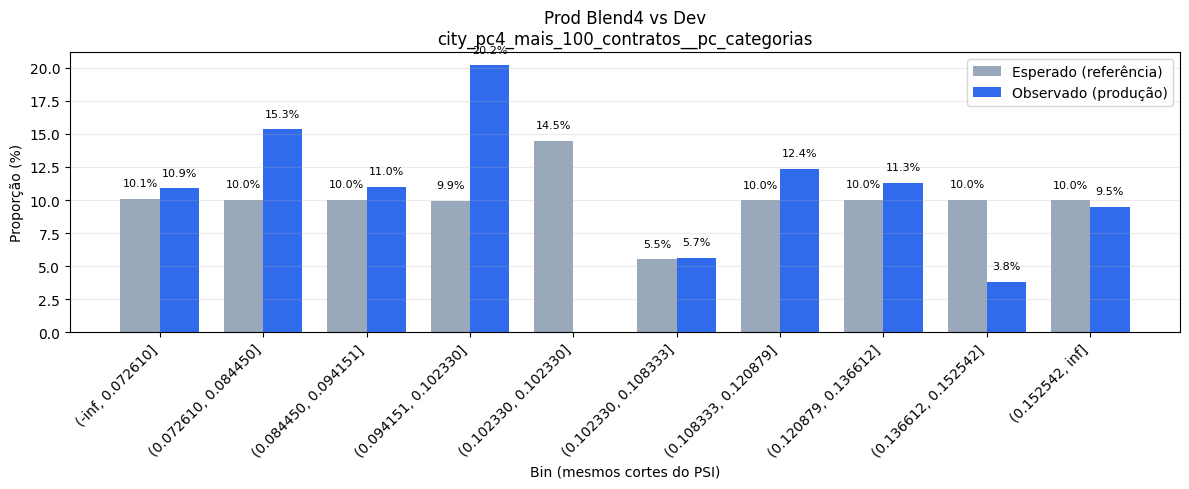

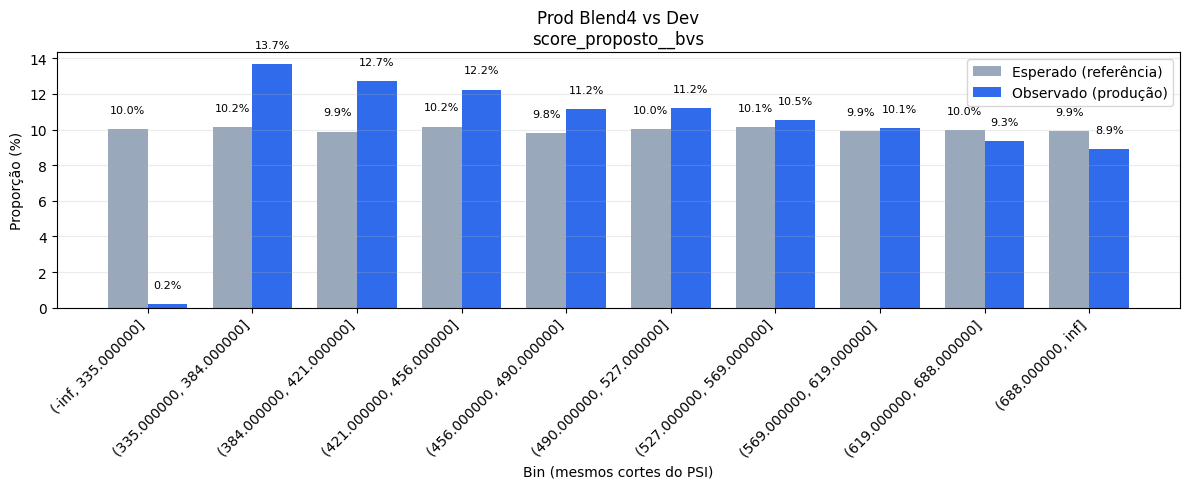

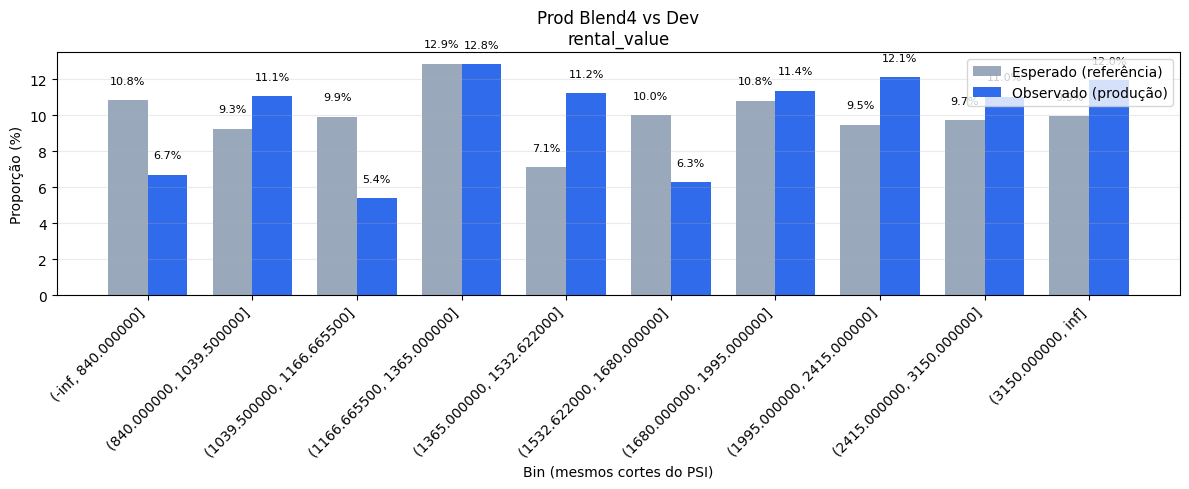

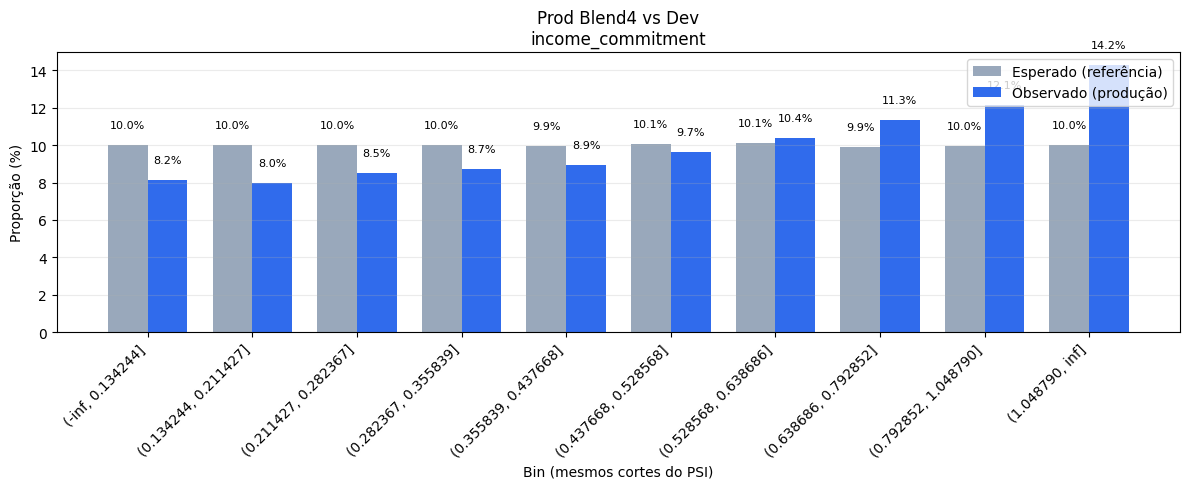

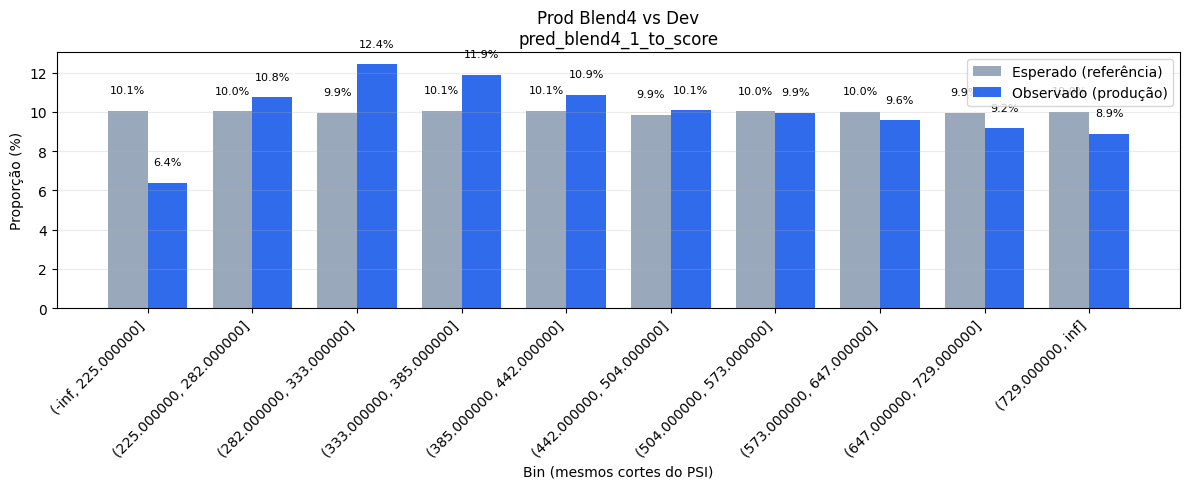

In [23]:
# Distribution tables for the top PSI variables (production Blend4 vs development bins)
top_psi_vars = (
    psi_comparison.dropna(subset=["psi_prod_blend4"])
    .head(5)["variable"]
    .tolist()
)

distribution_tables = {}
for var in top_psi_vars:
    if var not in psi_reference["variables"]:
        continue
    cmp_df = build_distribution_comparison(df_prod_blend4[var], psi_reference["variables"][var])
    cmp_df.insert(0, "variable", var)
    distribution_tables[var] = cmp_df
    psi_val = psi_comparison.loc[psi_comparison["variable"] == var, "psi_prod_blend4"].iloc[0]
    print(f"\n=== {var} | PSI={psi_val:.4f} ===")
    display(cmp_df)

if top_psi_vars:
    plot_top_psi_distributions(
        df_actual=df_prod_blend4,
        artifact=psi_reference,
        variables=model_vars,
        top_n=min(5, len(top_psi_vars)),
        title_prefix="Prod Blend4 vs Dev",
    )

#### PSI por safra (produção Blend4 × referência desenvolvimento)

Mesmos cortes/bins do `psi_reference` (desenvolvimento). Para cada safra de produção, recalcula o PSI variável a variável.

In [24]:
psi_by_safra_rows = []
for safra, g in df_prod_blend4.groupby("safra", sort=True):
    psi_safra = calculate_psi_table_from_reference(
        df_actual=g,
        artifact=psi_reference,
        comparison_label="production_blend4_vs_development",
        variables=model_vars,
    )
    psi_safra["safra"] = safra
    psi_safra["n_rows"] = len(g)
    psi_by_safra_rows.append(psi_safra)

psi_by_safra = pd.concat(psi_by_safra_rows, ignore_index=True)
psi_by_safra = psi_by_safra[
    ["safra", "variable", "psi", "status", "n_actual", "n_rows"]
].sort_values(["safra", "psi"], ascending=[True, False]).reset_index(drop=True)

display(psi_by_safra)

# Compact pivot: rows = variable, columns = safra
psi_safra_pivot = psi_by_safra.pivot(index="variable", columns="safra", values="psi")

# Keep variable order by overall production PSI (highest first)
if len(psi_comparison):
    var_order = (
        psi_comparison.dropna(subset=["psi_prod_blend4"])
        .sort_values("psi_prod_blend4", ascending=False)["variable"]
        .tolist()
    )
    psi_safra_pivot = psi_safra_pivot.reindex(
        [v for v in var_order if v in psi_safra_pivot.index]
    )

psi_safra_pivot

,safra,variable,psi,status,n_actual,n_rows
0,2026-07,city_pc4_mais_100_contratos__pc_categorias,1.844219,unstable,15445,15445
1,2026-07,score_proposto__bvs,0.394082,unstable,15445,15445
2,2026-07,rental_value,0.097357,stable,15445,15445
3,2026-07,pred_blend4_1_to_score,0.032835,stable,15445,15445
4,2026-07,income_commitment,0.032785,stable,15445,15445
5,2026-07,income,0.013817,stable,15445,15445
6,2026-07,SERASA_CHSV5,0.005384,stable,15445,15445
7,2026-07,age,0.004982,stable,15445,15445
8,2026-07,city_pc4_mais_100_contratos__pc_categorias_is_...,0.004911,stable,15445,15445
9,2026-07,property_type,0.002030,stable,15445,15445


safra,2026-07,2026-08
variable,,
city_pc4_mais_100_contratos__pc_categorias,1.844219,1.966379
score_proposto__bvs,0.394082,0.432353
rental_value,0.097357,0.099113
income_commitment,0.032785,0.037315
pred_blend4_1_to_score,0.032835,0.028556
income,0.013817,0.016807
SERASA_CHSV5,0.005384,0.011091
qtde_restricoes__consulta_realizada,0.001863,0.007004
age,0.004982,0.003136


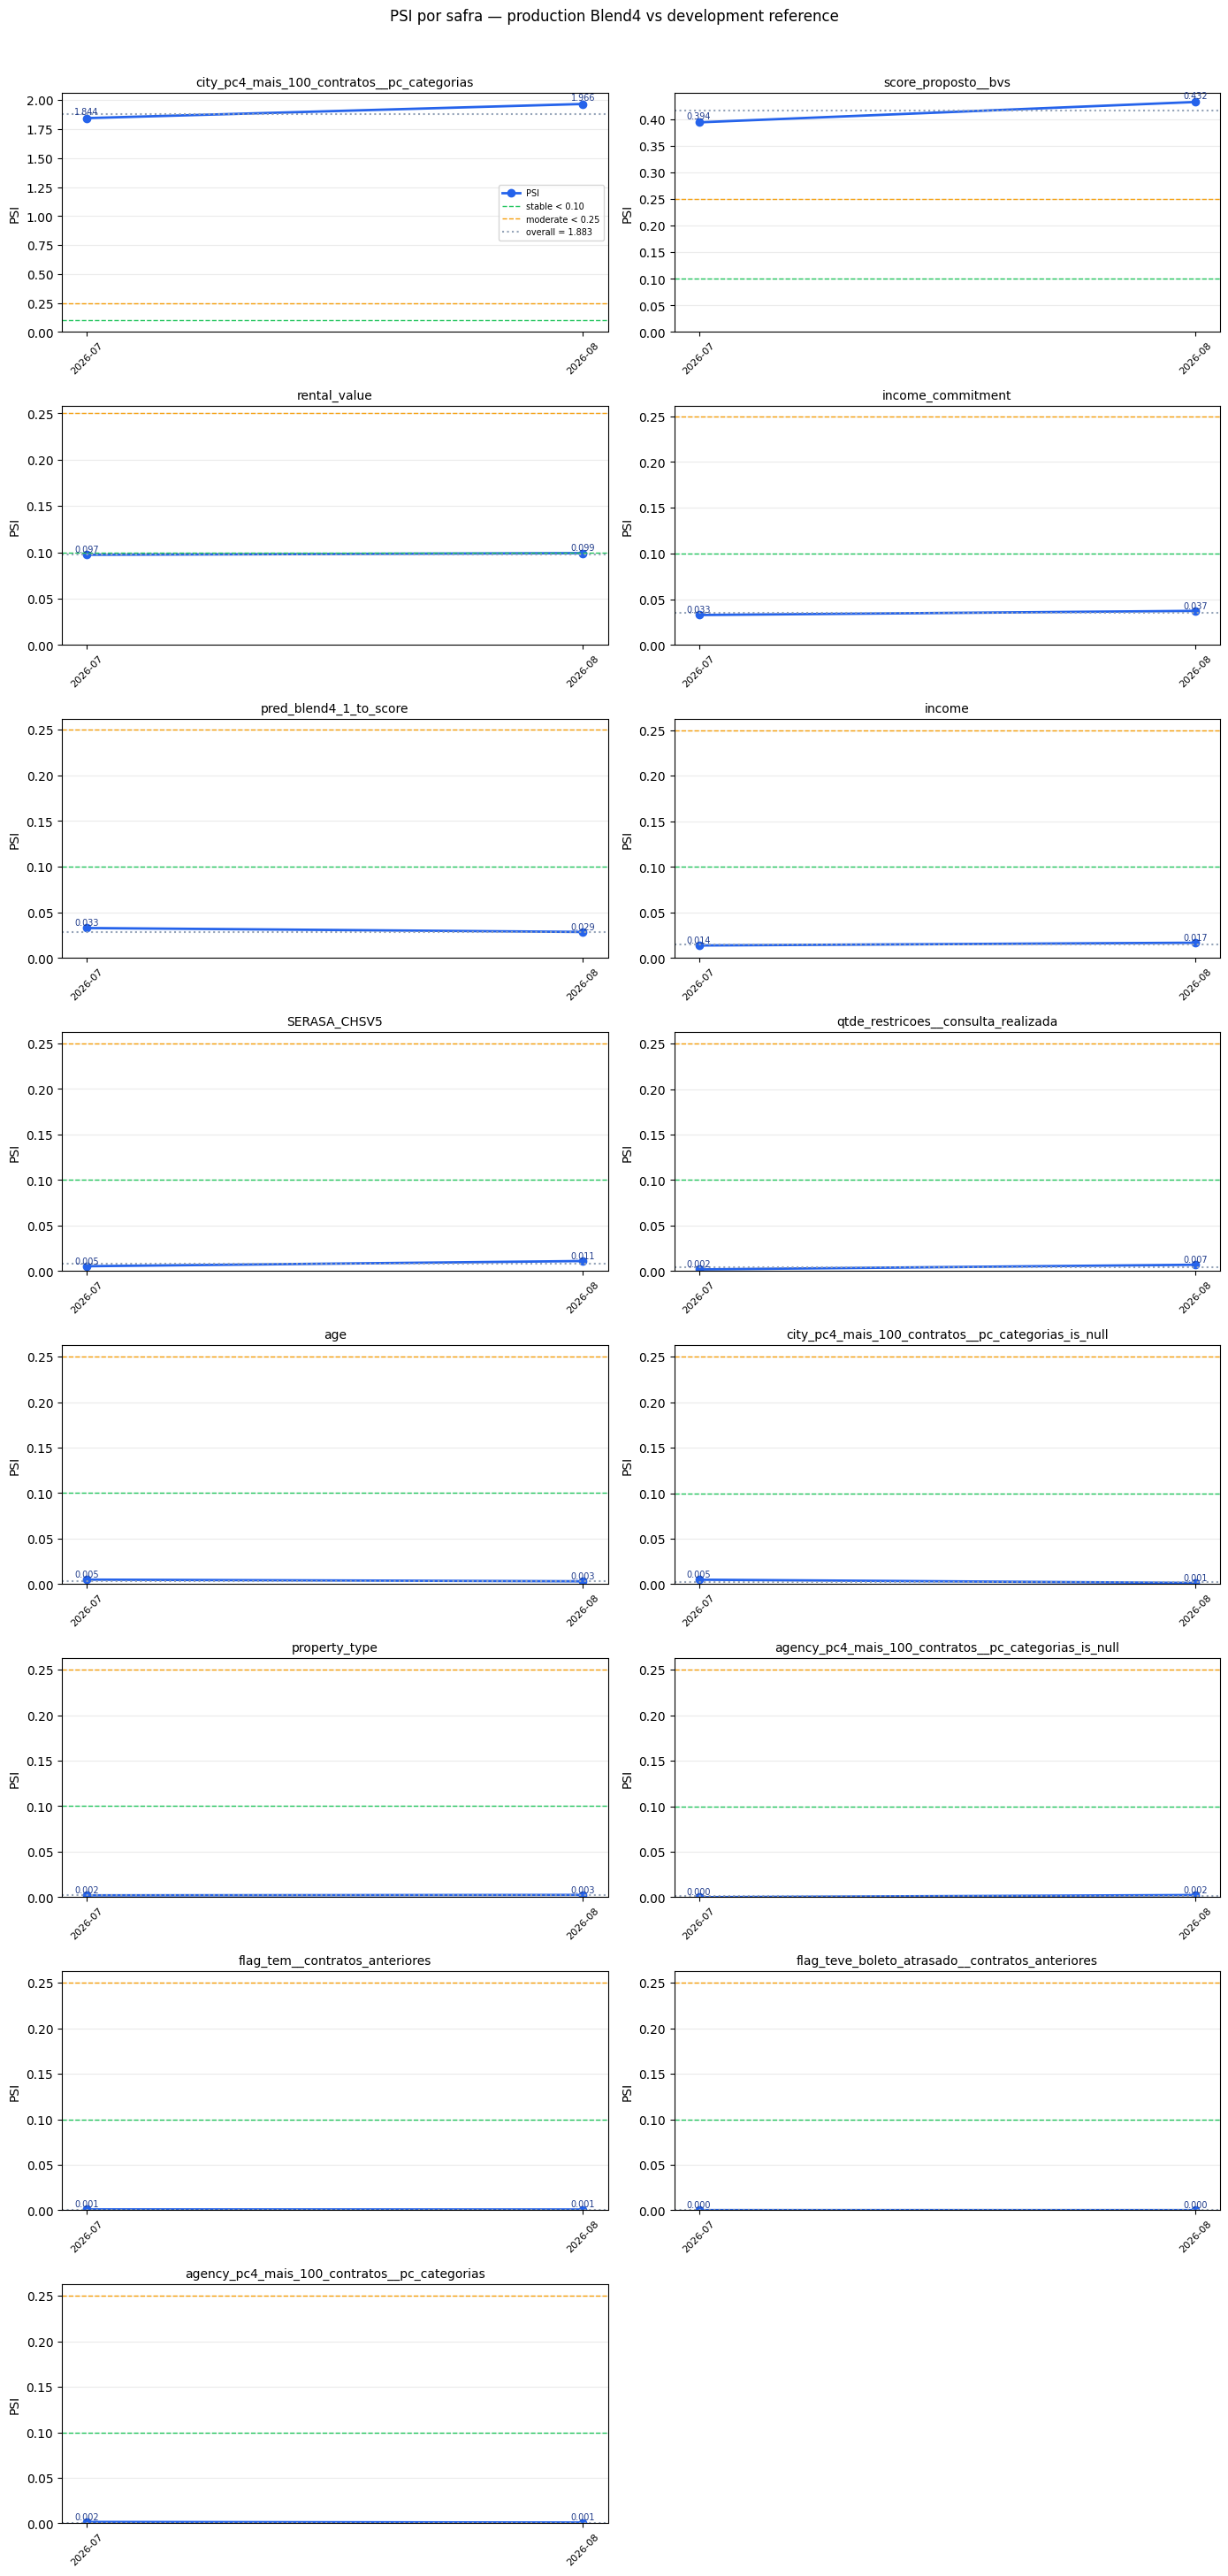

,safra,n_rows
0,2026-07,15445
1,2026-08,27362


In [25]:
# Threshold guides (same spirit as funcoes_psi status bands)
PSI_STABLE = 0.10
PSI_MODERATE = 0.25

plot_vars = psi_safra_pivot.index.tolist()
n_vars = len(plot_vars)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols)) if n_vars else 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), sharex=False)
axes = np.array(axes).reshape(-1)

for i, var in enumerate(plot_vars):
    ax = axes[i]
    g = psi_by_safra[psi_by_safra["variable"] == var].sort_values("safra")

    ax.plot(
        g["safra"],
        g["psi"],
        marker="o",
        linewidth=2,
        color="#2563EB",
        label="PSI",
    )
    ax.axhline(PSI_STABLE, color="#22C55E", linestyle="--", linewidth=1, label="stable < 0.10")
    ax.axhline(PSI_MODERATE, color="#F59E0B", linestyle="--", linewidth=1, label="moderate < 0.25")

    for _, row in g.iterrows():
        if pd.notna(row["psi"]):
            ax.text(
                row["safra"],
                row["psi"] + 0.01 * max(g["psi"].max(), 0.1),
                f"{row['psi']:.3f}",
                ha="center",
                va="bottom",
                fontsize=7,
                color="#1E3A8A",
            )

    # Overall PSI reference (all production Blend4)
    overall_psi = psi_comparison.loc[
        psi_comparison["variable"] == var, "psi_prod_blend4"
    ]
    if len(overall_psi):
        ax.axhline(
            float(overall_psi.iloc[0]),
            color="#94A3B8",
            linestyle=":",
            linewidth=1.5,
            label=f"overall = {float(overall_psi.iloc[0]):.3f}",
        )

    ax.set_title(var, fontsize=10)
    ax.set_ylabel("PSI")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(bottom=0)
    if i == 0:
        ax.legend(loc="best", fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "PSI por safra — production Blend4 vs development reference",
    y=1.01,
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Volume by safra (context for PSI stability)
vol = (
    psi_by_safra.drop_duplicates("safra")[["safra", "n_rows"]]
    .sort_values("safra")
    .reset_index(drop=True)
)
display(vol)

#### PSI por semana (domingo → sábado)

Semanas alinhadas a `requested_at` com início no **domingo** e fim no **sábado** (`prepare_week_columns`). Referência PSI = desenvolvimento. Inclui visão temporal e sazonalidade ao longo do mês.

In [26]:
from funcoes_monitoramento import prepare_week_columns, _sunday_week_start
from funcoes_psi import monitor_weekly_psi

# Production Blend4 with requested_at (needed for week assignment)
df_prod_blend4_week = df_blend4_dev.loc[
    df_blend4_dev["message_decisao"] == "BLEND_4",
    ["contract_id", "requested_at", "safra"] + model_vars,
].copy()

df_prod_blend4_week = prepare_week_columns(df_prod_blend4_week, date_col="requested_at")
df_prod_blend4_week["week_end"] = df_prod_blend4_week["week_start"] + pd.Timedelta(days=6)

# S1–S4: ordinal of Sundays that fall in week_start's month (same rule as visão semanal)
month_start = df_prod_blend4_week["week_start"].dt.to_period("M").dt.start_time
days_until_sunday = (6 - month_start.dt.dayofweek) % 7
first_sunday_in_month = (month_start + pd.to_timedelta(days_until_sunday, unit="D")).dt.normalize()
df_prod_blend4_week["week_of_month"] = (
    ((df_prod_blend4_week["week_start"] - first_sunday_in_month).dt.days // 7 + 1)
    .clip(lower=1, upper=4)
    .astype(int)
)
df_prod_blend4_week["week_label"] = df_prod_blend4_week["week_of_month"].map(lambda x: f"S{x}")
df_prod_blend4_week["week_month"] = df_prod_blend4_week["week_start"].dt.strftime("%Y-%m")

# Sanity check: week_start is Sunday, week_end is Saturday
assert (df_prod_blend4_week["week_start"].dt.dayofweek == 6).all(), "week_start must be Sunday"
assert (df_prod_blend4_week["week_end"].dt.dayofweek == 5).all(), "week_end must be Saturday"

print(
    f"Production Blend4: {len(df_prod_blend4_week):,} rows | "
    f"weeks: {df_prod_blend4_week['year_week'].nunique()} | "
    f"range: {df_prod_blend4_week['week_start'].min().date()} → "
    f"{df_prod_blend4_week['week_end'].max().date()}"
)
print("S1–S4 volumes (Sun–Sat within month):")
display(df_prod_blend4_week["week_label"].value_counts().sort_index().rename("n").to_frame())

display(
    df_prod_blend4_week.groupby(["year_week", "week_start", "week_end", "week_label"], as_index=False)
    .size()
    .rename(columns={"size": "n"})
    .sort_values("week_start")
)


Production Blend4: 42,807 rows | weeks: 8 | range: 2026-06-28 → 2026-08-22
S1–S4 volumes (Sun–Sat within month):


,n
week_label,
S1,16071
S2,17136
S3,4324
S4,5276


,year_week,week_start,week_end,week_label,n
0,2026-06-28,2026-06-28,2026-07-04,S4,390
1,2026-07-05,2026-07-05,2026-07-11,S1,2476
2,2026-07-12,2026-07-12,2026-07-18,S2,3997
3,2026-07-19,2026-07-19,2026-07-25,S3,4182
4,2026-07-26,2026-07-26,2026-08-01,S4,4886
5,2026-08-02,2026-08-02,2026-08-08,S1,13595
6,2026-08-09,2026-08-09,2026-08-15,S2,13139
7,2026-08-16,2026-08-16,2026-08-22,S3,142


In [27]:
psi_by_week = monitor_weekly_psi(
    df_production=df_prod_blend4_week,
    artifact=psi_reference,
    week_col="year_week",
    variables=model_vars,
)

# Attach volume and calendar helpers
week_meta = (
    df_prod_blend4_week.groupby("year_week", as_index=False)
    .agg(
        week_start=("week_start", "first"),
        week_end=("week_end", "first"),
        n_rows=("year_week", "size"),
        safra=("safra", lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]),
    )
)

psi_by_week = (
    psi_by_week.rename(columns={"monitoring_week": "year_week"})
    .merge(week_meta, on="year_week", how="left")
    .sort_values(["week_start", "psi"], ascending=[True, False])
    .reset_index(drop=True)
)

display(psi_by_week.head(30))

psi_week_pivot = psi_by_week.pivot(index="variable", columns="year_week", values="psi")
if len(psi_comparison):
    var_order = (
        psi_comparison.dropna(subset=["psi_prod_blend4"])
        .sort_values("psi_prod_blend4", ascending=False)["variable"]
        .tolist()
    )
    psi_week_pivot = psi_week_pivot.reindex(
        [v for v in var_order if v in psi_week_pivot.index]
    )

psi_week_pivot

,variable,comparison,psi,status,n_actual,year_week,week_start,week_end,n_rows,safra
0,city_pc4_mais_100_contratos__pc_categorias,production_vs_train,1.845870,unstable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
1,agency_pc4_mais_100_contratos__pc_categorias_i...,production_vs_train,0.666942,unstable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
2,score_proposto__bvs,production_vs_train,0.394156,unstable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
3,rental_value,production_vs_train,0.143864,moderate,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
4,pred_blend4_1_to_score,production_vs_train,0.051256,stable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
5,income_commitment,production_vs_train,0.038401,stable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
6,city_pc4_mais_100_contratos__pc_categorias_is_...,production_vs_train,0.032890,stable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
7,age,production_vs_train,0.030432,stable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
8,SERASA_CHSV5,production_vs_train,0.028140,stable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07
9,income,production_vs_train,0.021816,stable,390,2026-06-28,2026-06-28,2026-07-04,390,2026-07


year_week,2026-06-28,2026-07-05,2026-07-12,2026-07-19,2026-07-26,2026-08-02,2026-08-09,2026-08-16
variable,,,,,,,,
city_pc4_mais_100_contratos__pc_categorias,1.845870,1.822241,1.857325,1.854152,1.850227,1.973651,1.973008,1.888648
score_proposto__bvs,0.394156,0.469180,0.389155,0.390020,0.383883,0.426408,0.439049,1.240424
rental_value,0.143864,0.103520,0.109533,0.090223,0.101864,0.107300,0.090327,0.132300
income_commitment,0.038401,0.038834,0.034310,0.033316,0.036563,0.039608,0.035443,0.126400
pred_blend4_1_to_score,0.051256,0.039868,0.042337,0.033153,0.028892,0.035224,0.023598,0.048057
income,0.021816,0.016854,0.014036,0.015704,0.022525,0.020542,0.014111,0.034458
SERASA_CHSV5,0.028140,0.015989,0.003542,0.008546,0.007961,0.014203,0.009223,0.043938
qtde_restricoes__consulta_realizada,0.005865,0.004493,0.001698,0.002178,0.003042,0.006350,0.007426,0.007842
age,0.030432,0.006921,0.007331,0.008546,0.005888,0.005615,0.002575,0.087558


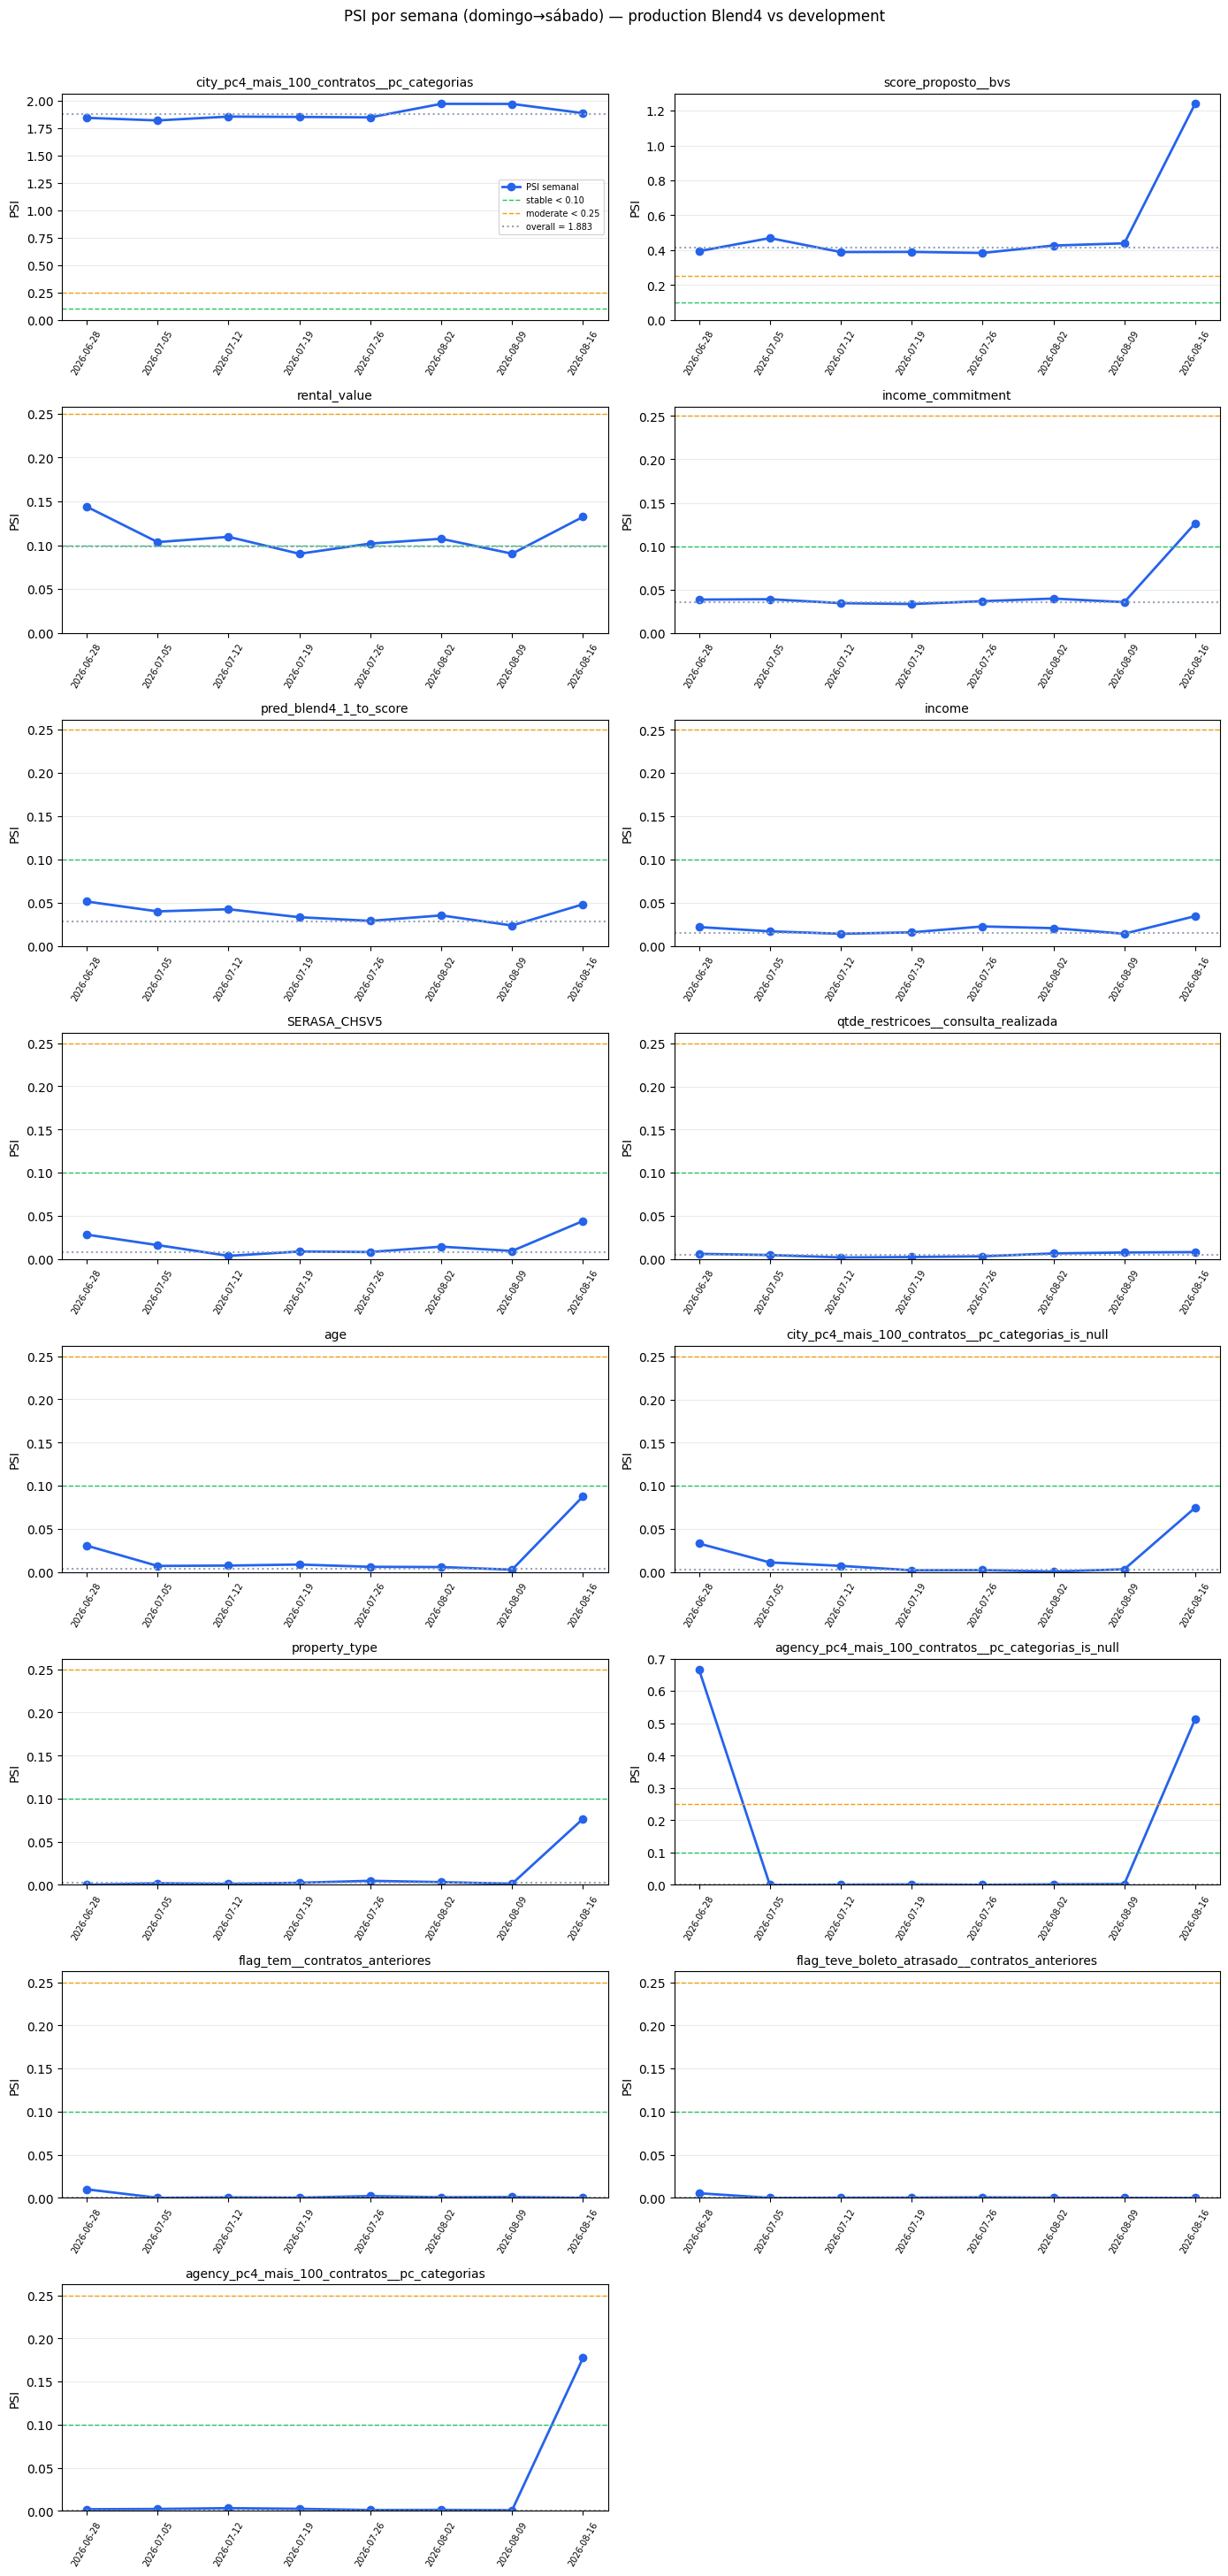

,year_week,week_start,week_end,n_rows,safra
0,2026-06-28,2026-06-28,2026-07-04,390,2026-07
1,2026-07-05,2026-07-05,2026-07-11,2476,2026-07
2,2026-07-12,2026-07-12,2026-07-18,3997,2026-07
3,2026-07-19,2026-07-19,2026-07-25,4182,2026-07
4,2026-07-26,2026-07-26,2026-08-01,4886,2026-07
5,2026-08-02,2026-08-02,2026-08-08,13595,2026-08
6,2026-08-09,2026-08-09,2026-08-15,13139,2026-08
7,2026-08-16,2026-08-16,2026-08-22,142,2026-08


In [28]:
PSI_STABLE = 0.10
PSI_MODERATE = 0.25

plot_vars = psi_week_pivot.index.tolist()
n_vars = len(plot_vars)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols)) if n_vars else 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), sharex=False)
axes = np.array(axes).reshape(-1)

for i, var in enumerate(plot_vars):
    ax = axes[i]
    g = psi_by_week[psi_by_week["variable"] == var].sort_values("week_start")

    ax.plot(
        g["year_week"].astype(str),
        g["psi"],
        marker="o",
        linewidth=2,
        color="#2563EB",
        label="PSI semanal",
    )
    ax.axhline(PSI_STABLE, color="#22C55E", linestyle="--", linewidth=1, label="stable < 0.10")
    ax.axhline(PSI_MODERATE, color="#F59E0B", linestyle="--", linewidth=1, label="moderate < 0.25")

    overall_psi = psi_comparison.loc[
        psi_comparison["variable"] == var, "psi_prod_blend4"
    ]
    if len(overall_psi):
        ax.axhline(
            float(overall_psi.iloc[0]),
            color="#94A3B8",
            linestyle=":",
            linewidth=1.5,
            label=f"overall = {float(overall_psi.iloc[0]):.3f}",
        )

    ax.set_title(f"{var}", fontsize=10)
    ax.set_ylabel("PSI")
    ax.tick_params(axis="x", rotation=60, labelsize=7)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(bottom=0)
    if i == 0:
        ax.legend(loc="best", fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "PSI por semana (domingo→sábado) — production Blend4 vs development",
    y=1.01,
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Volume context
display(
    week_meta.sort_values("week_start")[["year_week", "week_start", "week_end", "n_rows", "safra"]]
)

#### Sazonalidade no mês (S1–S4, domingo→sábado)

Agrupa por `week_of_month` / `week_label` (ordem da semana **domingo→sábado** dentro do mês civil) para ver se o PSI muda sistematicamente ao longo do mês.


In [29]:
psi_by_wom_rows = []
for wom, g in df_prod_blend4_week.groupby("week_of_month", sort=True):
    psi_wom = calculate_psi_table_from_reference(
        df_actual=g,
        artifact=psi_reference,
        comparison_label="production_blend4_vs_development",
        variables=model_vars,
    )
    psi_wom["week_of_month"] = int(wom)
    psi_wom["n_rows"] = len(g)
    psi_by_wom_rows.append(psi_wom)

psi_by_week_of_month = pd.concat(psi_by_wom_rows, ignore_index=True)
psi_by_week_of_month = psi_by_week_of_month[
    ["week_of_month", "variable", "psi", "status", "n_actual", "n_rows"]
].sort_values(["variable", "week_of_month"]).reset_index(drop=True)

display(psi_by_week_of_month)

psi_wom_pivot = psi_by_week_of_month.pivot(
    index="variable", columns="week_of_month", values="psi"
)
if len(psi_comparison):
    wom_var_order = (
        psi_comparison.dropna(subset=["psi_prod_blend4"])
        .sort_values("psi_prod_blend4", ascending=False)["variable"]
        .tolist()
    )
    psi_wom_pivot = psi_wom_pivot.reindex(
        [v for v in wom_var_order if v in psi_wom_pivot.index]
    )

# Volume by week-of-month
wom_vol = (
    df_prod_blend4_week.groupby("week_of_month", as_index=False)
    .size()
    .rename(columns={"size": "n_rows"})
)

display(psi_wom_pivot)
display(wom_vol)

,week_of_month,variable,psi,status,n_actual,n_rows
0,1,SERASA_CHSV5,0.013222,stable,16071,16071
1,2,SERASA_CHSV5,0.006454,stable,17136,17136
2,3,SERASA_CHSV5,0.008462,stable,4324,4324
3,4,SERASA_CHSV5,0.007664,stable,5276,5276
4,1,age,0.005041,stable,16071,16071
5,2,age,0.002978,stable,17136,17136
6,3,age,0.008285,stable,4324,4324
7,4,age,0.005165,stable,5276,5276
8,1,agency_pc4_mais_100_contratos__pc_categorias,0.000550,stable,16071,16071
9,2,agency_pc4_mais_100_contratos__pc_categorias,0.000259,stable,17136,17136


week_of_month,1,2,3,4
variable,,,,
city_pc4_mais_100_contratos__pc_categorias,1.920940,1.913533,1.847887,1.846144
score_proposto__bvs,0.431184,0.425195,0.394015,0.382115
rental_value,0.106024,0.093729,0.090665,0.101730
income_commitment,0.038673,0.034857,0.033806,0.035043
pred_blend4_1_to_score,0.034749,0.025430,0.032261,0.028204
income,0.018327,0.013096,0.015564,0.019557
SERASA_CHSV5,0.013222,0.006454,0.008462,0.007664
qtde_restricoes__consulta_realizada,0.005969,0.005584,0.002277,0.002474
age,0.005041,0.002978,0.008285,0.005165


,week_of_month,n_rows
0,1,16071
1,2,17136
2,3,4324
3,4,5276


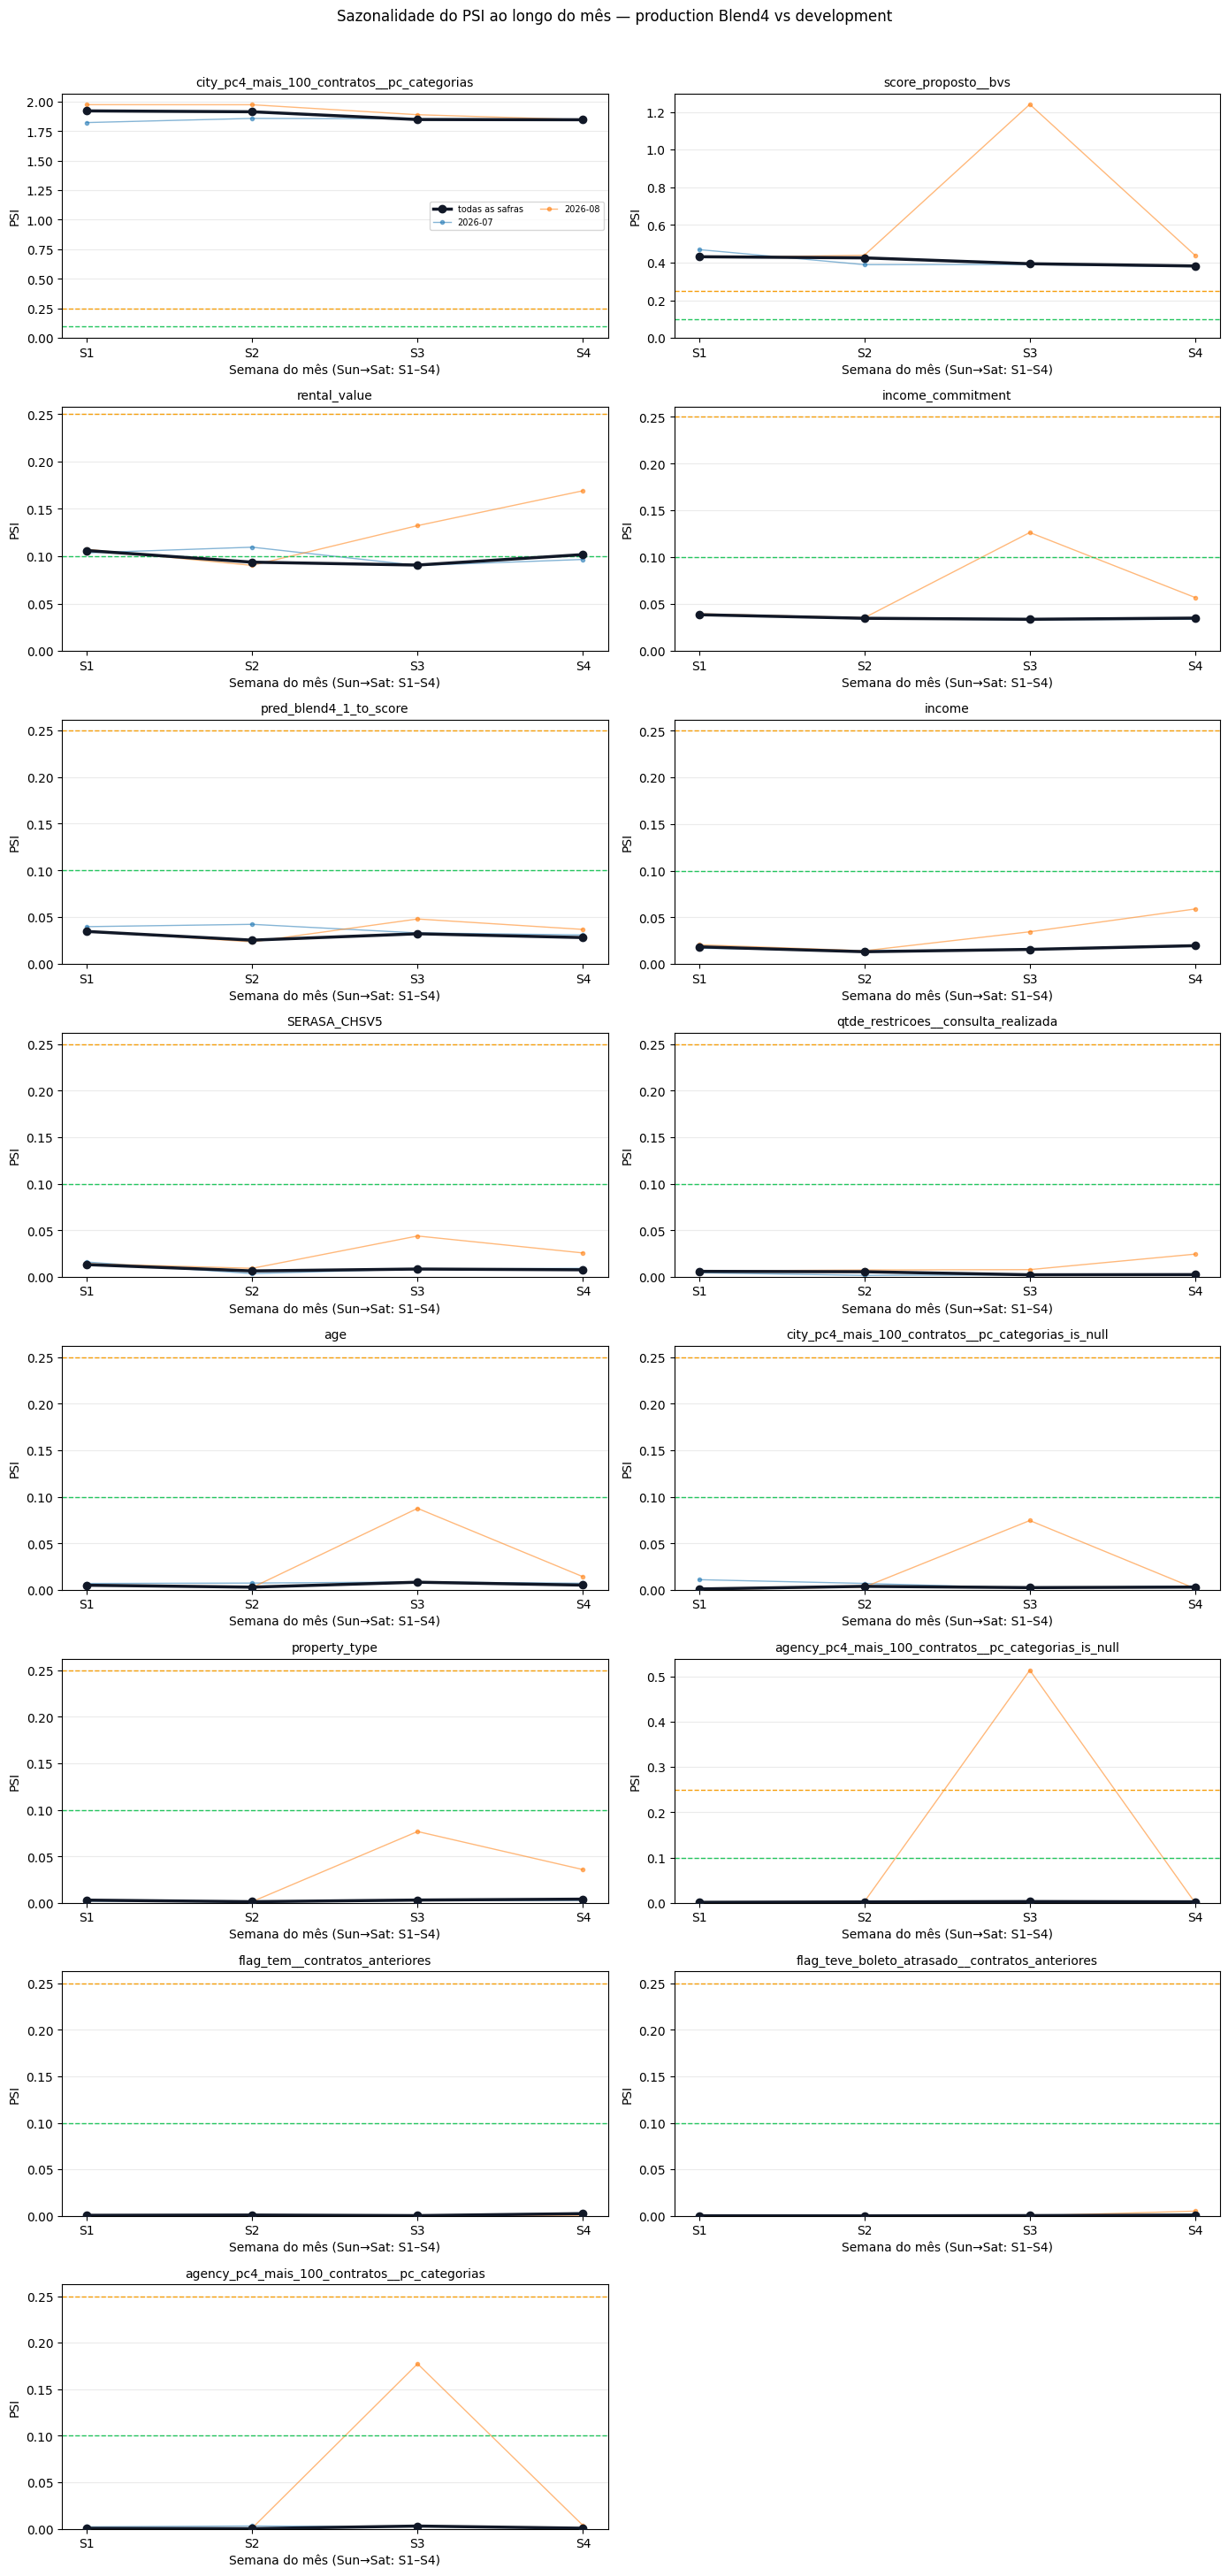

In [30]:
# Also: week_of_month × safra — catches seasonality that repeats every month
psi_wom_safra_rows = []
for (safra, wom), g in df_prod_blend4_week.groupby(["safra", "week_of_month"], sort=True):
    if len(g) < 50:
        # Skip tiny slices (unstable PSI)
        continue
    psi_slice = calculate_psi_table_from_reference(
        df_actual=g,
        artifact=psi_reference,
        comparison_label="production_blend4_vs_development",
        variables=model_vars,
    )
    psi_slice["safra"] = safra
    psi_slice["week_of_month"] = int(wom)
    psi_slice["n_rows"] = len(g)
    psi_wom_safra_rows.append(psi_slice)

psi_wom_safra = (
    pd.concat(psi_wom_safra_rows, ignore_index=True)
    if psi_wom_safra_rows
    else pd.DataFrame()
)

plot_vars = psi_wom_pivot.index.tolist()
n_vars = len(plot_vars)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols)) if n_vars else 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), sharex=False)
axes = np.array(axes).reshape(-1)

for i, var in enumerate(plot_vars):
    ax = axes[i]

    # Aggregate seasonality curve
    g = psi_by_week_of_month[psi_by_week_of_month["variable"] == var].sort_values(
        "week_of_month"
    )
    ax.plot(
        g["week_of_month"],
        g["psi"],
        marker="o",
        linewidth=2.5,
        color="#111827",
        label="todas as safras",
        zorder=5,
    )

    # One line per safra (if available)
    if not psi_wom_safra.empty:
        for safra, gs in psi_wom_safra[psi_wom_safra["variable"] == var].groupby("safra"):
            gs = gs.sort_values("week_of_month")
            ax.plot(
                gs["week_of_month"],
                gs["psi"],
                marker=".",
                linewidth=1,
                alpha=0.55,
                label=str(safra),
            )

    ax.axhline(PSI_STABLE, color="#22C55E", linestyle="--", linewidth=1)
    ax.axhline(PSI_MODERATE, color="#F59E0B", linestyle="--", linewidth=1)
    ax.set_xticks(sorted(g["week_of_month"].unique()))
    ax.set_xticklabels([f"S{w}" for w in sorted(g["week_of_month"].unique())])
    ax.set_title(var, fontsize=10)
    ax.set_ylabel("PSI")
    ax.set_xlabel("Semana do mês (Sun→Sat: S1–S4)")
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(bottom=0)
    if i == 0:
        ax.legend(loc="best", fontsize=7, ncol=2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Sazonalidade do PSI ao longo do mês — production Blend4 vs development",
    y=1.01,
    fontsize=12,
)
plt.tight_layout()
plt.show()

### 5. Score final — `pred_blend4_1_to_score`

In [31]:
score_profile = pd.concat(
    [
        variable_profile(df_dev, [SCORE_COL], "development"),
        variable_profile(df_prod, [SCORE_COL], "production_all"),
        variable_profile(df_prod_blend4, [SCORE_COL], "production_blend4"),
    ],
    ignore_index=True,
)
display(score_profile)

# Score percentiles by safra
def score_by_safra(df: pd.DataFrame, label: str) -> pd.DataFrame:
    s = pd.to_numeric(df[SCORE_COL], errors="coerce")
    out = (
        df.assign(_score=s)
        .groupby("safra", as_index=False)
        .agg(
            n=("_score", "size"),
            p50=("_score", "median"),
            p75=("_score", lambda x: x.quantile(0.75)),
        )
    )
    out["base"] = label
    return out


score_safra = pd.concat(
    [
        score_by_safra(df_dev, "development"),
        score_by_safra(df_prod_blend4, "production_blend4"),
    ],
    ignore_index=True,
).sort_values(["base", "safra"])

score_safra

,variable,base,n,n_non_null,pct_null,mean,std,p01,p05,p25,p50,p75,p95,p99,min,max
0,pred_blend4_1_to_score,development,1070236,1070236,0.0,460.522772,186.130055,132.0,188.0,308.0,442.0,609.0,779.0,836.0,0.0,904.0
1,pred_blend4_1_to_score,production_all,192210,192210,0.0,458.939337,96.158019,200.0,289.0,416.0,466.0,503.0,614.0,779.0,0.0,905.0
2,pred_blend4_1_to_score,production_blend4,42807,42807,0.0,457.728105,175.579785,160.0,215.0,316.0,429.0,594.0,773.0,833.0,0.0,905.0


,safra,n,p50,p75,base
0,2024-09,39121,486.0,638.0,development
1,2024-10,44731,484.0,635.0,development
2,2024-11,40001,483.0,635.0,development
3,2024-12,43060,476.0,632.0,development
4,2025-01,109011,458.0,625.0,development
5,2025-02,108527,457.0,622.0,development
6,2025-03,96018,437.0,608.0,development
7,2025-04,97266,430.0,600.0,development
8,2025-05,106310,421.0,593.0,development
9,2025-06,121861,430.0,602.0,development


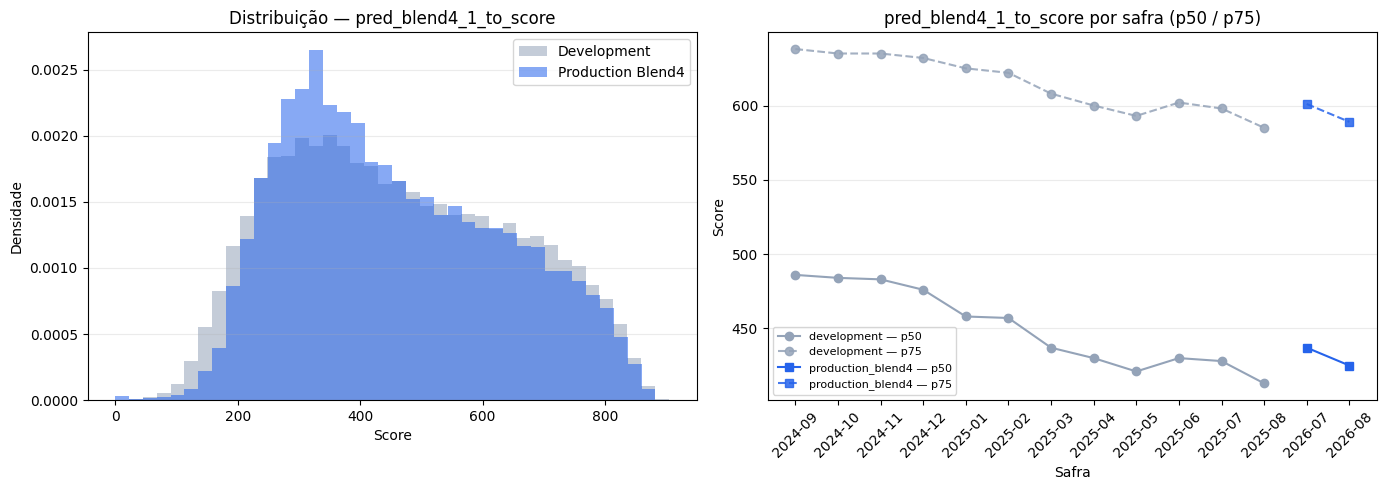

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: development vs production Blend4
for ax, data, label, color in [
    (axes[0], df_dev[SCORE_COL], "Development", "#94A3B8"),
    (axes[0], df_prod_blend4[SCORE_COL], "Production Blend4", "#2563EB"),
]:
    s = pd.to_numeric(data, errors="coerce").dropna()
    ax.hist(s, bins=40, alpha=0.55, density=True, label=label, color=color)

axes[0].set_title(f"Distribuição — {SCORE_COL}")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Densidade")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

# p50 / p75 by safra (no mean — outliers distort)
for label, color, marker in [
    ("development", "#94A3B8", "o"),
    ("production_blend4", "#2563EB", "s"),
]:
    g = score_safra[score_safra["base"] == label]
    axes[1].plot(
        g["safra"],
        g["p50"],
        marker=marker,
        color=color,
        label=f"{label} — p50",
    )
    axes[1].plot(
        g["safra"],
        g["p75"],
        marker=marker,
        color=color,
        linestyle="--",
        alpha=0.85,
        label=f"{label} — p75",
    )

axes[1].set_title(f"{SCORE_COL} por safra (p50 / p75)")
axes[1].set_xlabel("Safra")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### 6. Percentis (p50/p75) das variáveis por safra (dev × prod)


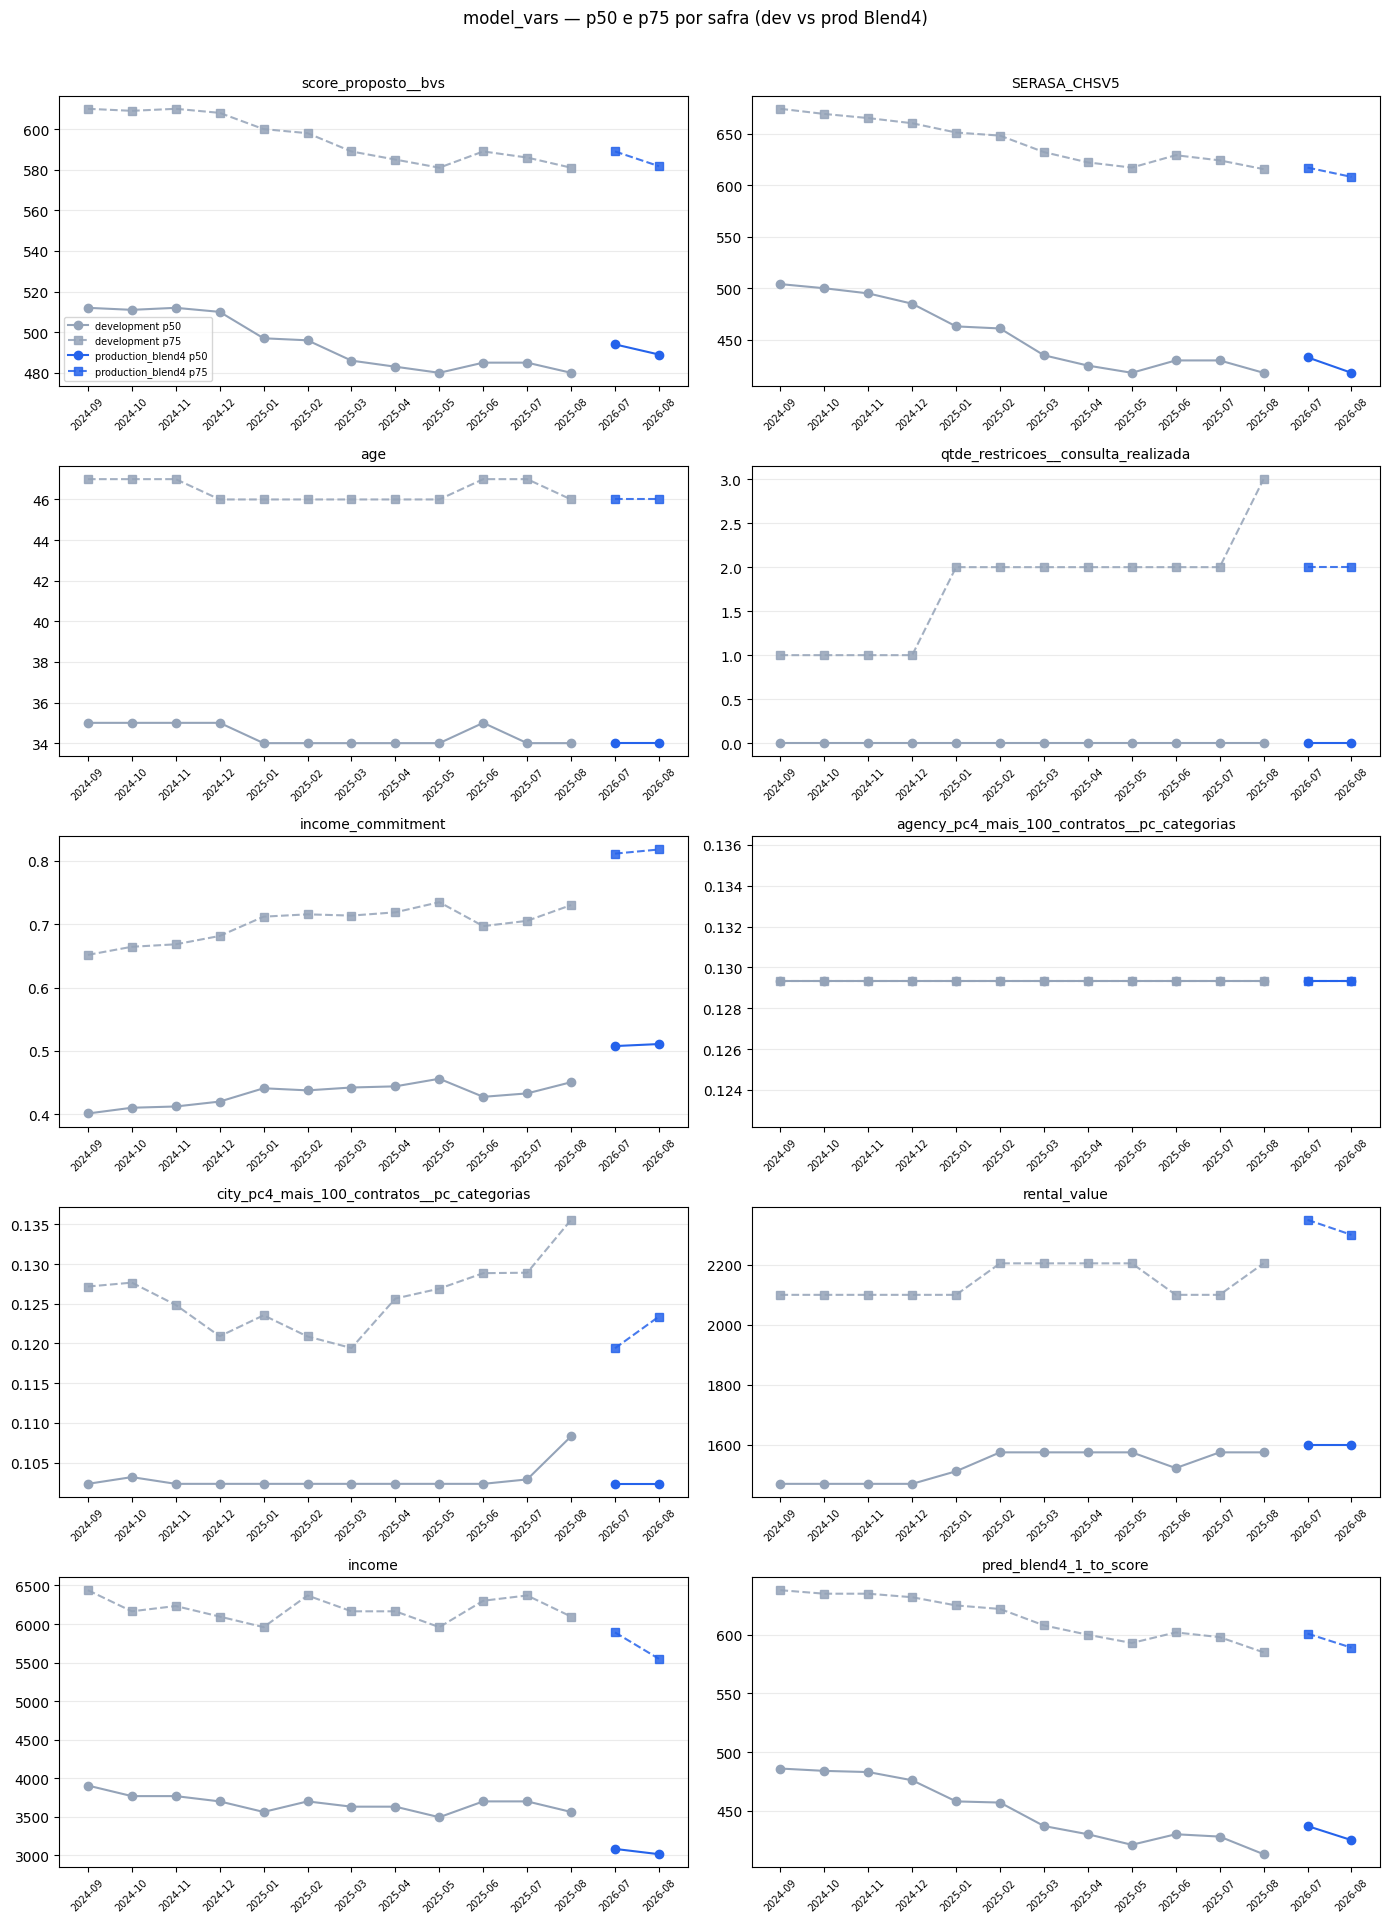

In [33]:
# Continuous / high-cardinality model vars for percentile timelines
PLOT_VARS = [
    v
    for v in model_vars
    if v not in BINARY_MODEL_VARS
]

n_vars = len(PLOT_VARS)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.8 * n_rows), sharex=False)
axes = np.array(axes).reshape(-1)

for i, var in enumerate(PLOT_VARS):
    ax = axes[i]
    for df_src, label, color in [
        (df_dev, "development", "#94A3B8"),
        (df_prod_blend4, "production_blend4", "#2563EB"),
    ]:
        s = pd.to_numeric(df_src[var], errors="coerce")
        g = (
            df_src.assign(_v=s)
            .groupby("safra", as_index=False)
            .agg(
                p50=("_v", "median"),
                p75=("_v", lambda x: x.quantile(0.75)),
            )
        )
        ax.plot(g["safra"], g["p50"], marker="o", color=color, label=f"{label} p50")
        ax.plot(g["safra"], g["p75"], marker="s", linestyle="--", color=color, alpha=0.85, label=f"{label} p75")

    ax.set_title(var, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(axis="y", alpha=0.25)
    if i == 0:
        ax.legend(fontsize=7, loc="best")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("model_vars — p50 e p75 por safra (dev vs prod Blend4)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

### 7. Mix das variáveis binárias / flags

In [34]:
binary_vars = [v for v in model_vars if v in BINARY_MODEL_VARS]
binary_rows = []

for var in binary_vars:
    for df_src, label in [
        (df_dev, "development"),
        (df_prod_blend4, "production_blend4"),
    ]:
        s = pd.to_numeric(df_src[var], errors="coerce")
        binary_rows.append(
            {
                "variable": var,
                "base": label,
                "n": len(s),
                "pct_1": round(100 * (s == 1).mean(), 4),
                "pct_0": round(100 * (s == 0).mean(), 4),
                "pct_null": round(100 * s.isna().mean(), 4),
                "mean": round(s.mean(), 6),
            }
        )

binary_mix = pd.DataFrame(binary_rows)
binary_wide = binary_mix.pivot(index="variable", columns="base", values=["pct_1", "pct_0", "mean"])
binary_wide[("pct_1", "diff_pp")] = (
    binary_wide[("pct_1", "production_blend4")] - binary_wide[("pct_1", "development")]
)
binary_wide.sort_values(("pct_1", "diff_pp"), key=lambda s: s.abs(), ascending=False)

pct_1  \
base                                               development   
variable                                                         
city_pc4_mais_100_contratos__pc_categorias_is_null     14.4701   
property_type                                          92.2475   
agency_pc4_mais_100_contratos__pc_categorias_is...     80.4643   
flag_tem__contratos_anteriores                          6.7802   
flag_teve_boleto_atrasado__contratos_anteriores         2.1456   

                                                                      \
base                                               production_blend4   
variable                                                               
city_pc4_mais_100_contratos__pc_categorias_is_null           12.8133   
property_type                                                93.4870   
agency_pc4_mais_100_contratos__pc_categorias_is...           81.6899   
flag_tem__contratos_anteriores                                7.5362   
flag_teve_boleto_atrasado__contratos_anteriores               2.3221   

                                                         pct_0  \
base                                               development   
variable                                                         
city_pc4_mais_100_contratos__pc_categorias_is_null     85.5299   
property_type                                           7.7525   
agency_pc4_mais_100_contratos__pc_categorias_is...     19.5357   
flag_tem__contratos_anteriores                         93.2198   
flag_teve_boleto_atrasado__contratos_anteriores        97.8544   

                                                                      \
base                                               production_blend4   
variable                                                               
city_pc4_mais_100_contratos__pc_categorias_is_null           87.1867   
property_type                                                 6.5130   
agency_pc4_mais_100_contratos__pc_categorias_is...           18.3101   
flag_tem__contratos_anteriores                               92.4638   
flag_teve_boleto_atrasado__contratos_anteriores              97.6779   

                                                          mean  \
base                                               development   
variable                                                         
city_pc4_mais_100_contratos__pc_categorias_is_null    0.144701   
property_type                                         0.922475   
agency_pc4_mais_100_contratos__pc_categorias_is...    0.804643   
flag_tem__contratos_anteriores                        0.067802   
flag_teve_boleto_atrasado__contratos_anteriores       0.021456   

                                                                       pct_1  
base                                               production_blend4 diff_pp  
variable                                                                      
city_pc4_mais_100_contratos__pc_categorias_is_null          0.128133 -1.6568  
property_type                                               0.934870  1.2395  
agency_pc4_mais_100_contratos__pc_categorias_is...          0.816899  1.2256  
flag_tem__contratos_anteriores                              0.075362  0.7560  
flag_teve_boleto_atrasado__contratos_anteriores             0.023221  0.1765

### 8. Correlação das features com o score final

In [35]:
feature_vars = [v for v in model_vars if v != SCORE_COL]

def corr_with_score(df: pd.DataFrame, label: str) -> pd.DataFrame:
    work = df[feature_vars + [SCORE_COL]].apply(pd.to_numeric, errors="coerce")
    corr = work.corr(numeric_only=True)[SCORE_COL].drop(labels=[SCORE_COL])
    return (
        corr.rename("corr_with_score")
        .reset_index()
        .rename(columns={"index": "variable"})
        .assign(base=label)
    )


corr_cmp = (
    corr_with_score(df_dev, "development")[["variable", "corr_with_score"]]
    .rename(columns={"corr_with_score": "corr_dev"})
    .merge(
        corr_with_score(df_prod_blend4, "production_blend4")[["variable", "corr_with_score"]].rename(
            columns={"corr_with_score": "corr_prod_blend4"}
        ),
        on="variable",
        how="outer",
    )
)
corr_cmp["corr_diff"] = corr_cmp["corr_prod_blend4"] - corr_cmp["corr_dev"]
corr_cmp = corr_cmp.sort_values("corr_diff", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
corr_cmp

,variable,corr_dev,corr_prod_blend4,corr_diff
0,income_commitment,-0.298384,-0.012606,0.285778
1,rental_value,0.082767,-0.012604,-0.095371
2,agency_pc4_mais_100_contratos__pc_categorias_i...,0.074449,0.109835,0.035387
3,income,0.253051,0.225779,-0.027272
4,age,0.079977,0.104583,0.024607
5,qtde_restricoes__consulta_realizada,-0.402987,-0.425102,-0.022115
6,agency_pc4_mais_100_contratos__pc_categorias,-0.078697,-0.098110,-0.019413
7,score_proposto__bvs,0.921402,0.904941,-0.016462
8,property_type,-0.057906,-0.045096,0.012810
9,city_pc4_mais_100_contratos__pc_categorias_is_...,0.042988,0.053557,0.010568


### 9. Resumo executivo

In [36]:
summary = {
    "n_dev": len(df_dev),
    "n_prod_all": len(df_prod),
    "n_prod_blend4": len(df_prod_blend4),
    "n_matched_contract_id_safra": int((df_cmp["_merge"] == "both").sum()),
    "safra_dev": f"{df_dev['safra'].min()} → {df_dev['safra'].max()}",
    "safra_prod": f"{df_prod['safra'].min()} → {df_prod['safra'].max()}",
    "score_mean_dev": round(pd.to_numeric(df_dev[SCORE_COL], errors='coerce').mean(), 2),
    "score_mean_prod_blend4": round(pd.to_numeric(df_prod_blend4[SCORE_COL], errors='coerce').mean(), 2),
    "score_p50_dev": round(pd.to_numeric(df_dev[SCORE_COL], errors='coerce').median(), 2),
    "score_p50_prod_blend4": round(pd.to_numeric(df_prod_blend4[SCORE_COL], errors='coerce').median(), 2),
}

if len(psi_comparison):
    top = psi_comparison.iloc[0]
    summary["top_psi_variable"] = top["variable"]
    summary["top_psi_prod_blend4"] = top["psi_prod_blend4"]
    summary["top_psi_status"] = top["status_prod_blend4"]

unstable = psi_comparison.loc[psi_comparison["status_prod_blend4"] == "unstable", "variable"].tolist()
moderate = psi_comparison.loc[psi_comparison["status_prod_blend4"] == "moderate", "variable"].tolist()
summary["unstable_vars"] = unstable
summary["moderate_vars"] = moderate

pd.Series(summary, name="value").to_frame()

,value
n_dev,1070236
n_prod_all,192210
n_prod_blend4,42807
n_matched_contract_id_safra,0
safra_dev,2024-09 → 2025-08
safra_prod,2026-05 → 2026-08
score_mean_dev,460.52
score_mean_prod_blend4,457.73
score_p50_dev,442.0
score_p50_prod_blend4,429.0


Variável de Cidade: Posso utilizar valores antigos para fazer testes?

## KS Modelo

KS do Blend4 na base de desenvolvimento (`df_raw_dev`), usando `pred_blend4_1_to_score` como score e `target_default_6_completa` como TARGET.

In [37]:
TARGET_COL = "target_default_6_completa"
SCORE_COL = "pred_blend4_1_to_score"


def calculate_ks(
    y_true: pd.Series,
    y_score: pd.Series,
    higher_score_is_better: bool = True,
) -> dict:
    """
    Kolmogorov-Smirnov between score distributions of goods (0) and bads (1).

    For credit scores (higher = better), low scores are treated as higher risk.
    Returns KS in percentage points (0-100).
    """
    work = pd.DataFrame(
        {
            "target": pd.to_numeric(y_true, errors="coerce"),
            "score": pd.to_numeric(y_score, errors="coerce"),
        }
    ).dropna()

    n = len(work)
    n_bad = int((work["target"] == 1).sum())
    n_good = int((work["target"] == 0).sum())

    if n == 0 or n_bad == 0 or n_good == 0:
        return {
            "ks": np.nan,
            "ks_score": np.nan,
            "n": n,
            "n_bad": n_bad,
            "n_good": n_good,
            "default_rate": np.nan,
        }

    # Order from worst to best risk for the cumulative curves
    ascending = higher_score_is_better  # low score first when higher is better
    work = work.sort_values("score", ascending=ascending).reset_index(drop=True)

    cum_bad = (work["target"] == 1).cumsum() / n_bad
    cum_good = (work["target"] == 0).cumsum() / n_good
    ks_curve = (cum_bad - cum_good).abs()
    idx = int(ks_curve.idxmax())

    return {
        "ks": round(float(ks_curve.iloc[idx]) * 100, 2),
        "ks_score": float(work.loc[idx, "score"]),
        "n": n,
        "n_bad": n_bad,
        "n_good": n_good,
        "default_rate": round(100 * n_bad / n, 4),
    }


def ks_curve_frame(
    y_true: pd.Series,
    y_score: pd.Series,
    higher_score_is_better: bool = True,
) -> pd.DataFrame:
    """Return cumulative good/bad rates ordered by score (worst → best)."""
    work = pd.DataFrame(
        {
            "target": pd.to_numeric(y_true, errors="coerce"),
            "score": pd.to_numeric(y_score, errors="coerce"),
        }
    ).dropna()

    n_bad = int((work["target"] == 1).sum())
    n_good = int((work["target"] == 0).sum())
    if n_bad == 0 or n_good == 0:
        return pd.DataFrame()

    ascending = higher_score_is_better
    work = work.sort_values("score", ascending=ascending).reset_index(drop=True)
    work["cum_bad"] = (work["target"] == 1).cumsum() / n_bad
    work["cum_good"] = (work["target"] == 0).cumsum() / n_good
    work["ks"] = (work["cum_bad"] - work["cum_good"]).abs()
    work["pct_pop"] = (np.arange(1, len(work) + 1)) / len(work)
    return work


STATUS_COL = "status_v2"

df_ks = df_raw_dev[[SCORE_COL, TARGET_COL, "safra", STATUS_COL]].copy()
print(
    f"Development rows: {len(df_ks):,} | "
    f"with TARGET: {df_ks[TARGET_COL].notna().sum():,} | "
    f"null TARGET: {df_ks[TARGET_COL].isna().sum():,}"
)
print("\nPúblicos (status_v2):")
display(df_ks[STATUS_COL].value_counts(dropna=False).rename("n").to_frame())

ks_overall = calculate_ks(df_ks[TARGET_COL], df_ks[SCORE_COL])
pd.Series(ks_overall, name="overall").to_frame()

Development rows: 1,070,236 | with TARGET: 943,572 | null TARGET: 126,664

Públicos (status_v2):


,n
status_v2,
elegivel_n_ativado,439214
nao_aprovado,427028
elegivel_ativado,203994


,overall
ks,37.3800
ks_score,446.0000
n,943572.0000
n_bad,128925.0000
n_good,814647.0000
default_rate,13.6635


### KS por safra

In [38]:
ks_by_safra_rows = []
for safra, g in df_ks.groupby("safra", sort=True):
    row = calculate_ks(g[TARGET_COL], g[SCORE_COL])
    row["safra"] = safra
    ks_by_safra_rows.append(row)

ks_by_safra = pd.DataFrame(ks_by_safra_rows)[
    ["safra", "ks", "ks_score", "n", "n_bad", "n_good", "default_rate"]
]

# Overall row for reference
ks_by_safra.loc[len(ks_by_safra)] = {
    "safra": "OVERALL",
    **{k: ks_overall[k] for k in ["ks", "ks_score", "n", "n_bad", "n_good", "default_rate"]},
}

ks_by_safra

,safra,ks,ks_score,n,n_bad,n_good,default_rate
0,2024-09,40.88,447.0,39121,4667,34454,11.9297
1,2024-10,38.84,446.0,44731,5352,39379,11.9649
2,2024-11,39.69,448.0,40001,4933,35068,12.3322
3,2024-12,39.25,447.0,43060,5376,37684,12.4849
4,2025-01,38.67,441.0,109011,14521,94490,13.3207
5,2025-02,38.12,444.0,108527,14320,94207,13.1949
6,2025-03,36.94,446.0,96018,13622,82396,14.1869
7,2025-04,35.20,446.0,97266,13782,83484,14.1694
8,2025-05,35.88,445.0,106310,15419,90891,14.5038
9,2025-06,36.65,418.0,121861,17294,104567,14.1916


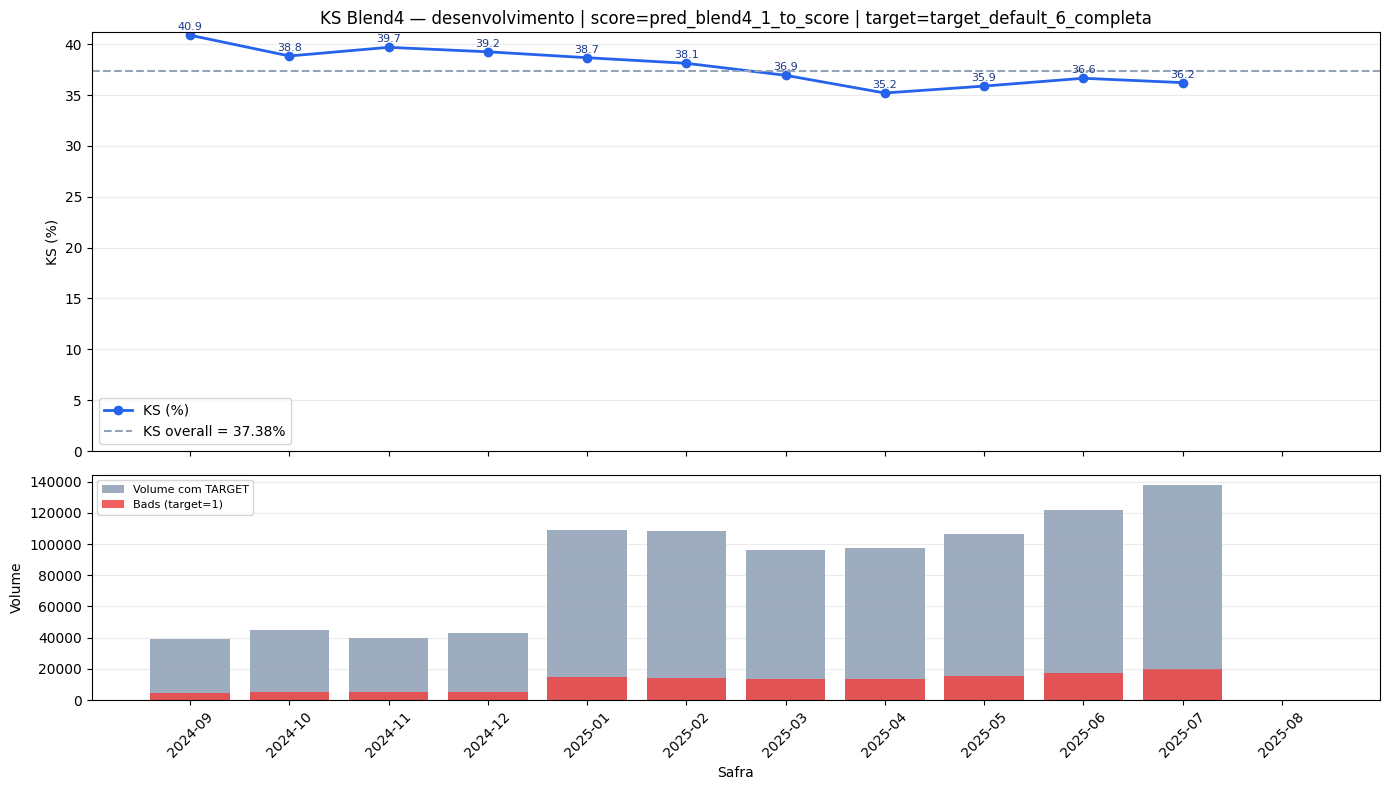

KS overall: 37.38% (n=943,572, default_rate=13.66%)


In [39]:
plot_ks = ks_by_safra[ks_by_safra["safra"] != "OVERALL"].copy()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [0.65, 0.35]},
)
ax_ks, ax_vol = axes

ax_ks.plot(
    plot_ks["safra"],
    plot_ks["ks"],
    marker="o",
    linewidth=2,
    color="#2563EB",
    label="KS (%)",
)
ax_ks.axhline(
    ks_overall["ks"],
    color="#94A3B8",
    linestyle="--",
    linewidth=1.5,
    label=f"KS overall = {ks_overall['ks']:.2f}%",
)

for _, row in plot_ks.dropna(subset=["ks"]).iterrows():
    ax_ks.text(
        row["safra"],
        row["ks"] + 0.3,
        f"{row['ks']:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#1E3A8A",
    )

ax_ks.set_ylabel("KS (%)")
ax_ks.set_title(
    f"KS Blend4 — desenvolvimento | score={SCORE_COL} | target={TARGET_COL}"
)
ax_ks.legend(loc="best")
ax_ks.grid(axis="y", alpha=0.25)
ax_ks.set_ylim(bottom=0)

ax_vol.bar(plot_ks["safra"], plot_ks["n"], color="#94A3B8", alpha=0.9, label="Volume com TARGET")
ax_vol.bar(plot_ks["safra"], plot_ks["n_bad"], color="#EF4444", alpha=0.85, label="Bads (target=1)")
ax_vol.set_ylabel("Volume")
ax_vol.set_xlabel("Safra")
ax_vol.tick_params(axis="x", rotation=45)
ax_vol.legend(loc="best", fontsize=8)
ax_vol.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print(
    f"KS overall: {ks_overall['ks']:.2f}% "
    f"(n={ks_overall['n']:,}, default_rate={ks_overall['default_rate']:.2f}%)"
)

### KS por público (`status_v2`)

In [40]:
ks_by_status_rows = []
for status, g in df_ks.groupby(STATUS_COL, dropna=False, sort=True):
    row = calculate_ks(g[TARGET_COL], g[SCORE_COL])
    row[STATUS_COL] = status
    ks_by_status_rows.append(row)

ks_by_status = pd.DataFrame(ks_by_status_rows)[
    [STATUS_COL, "ks", "ks_score", "n", "n_bad", "n_good", "default_rate"]
].sort_values("ks", ascending=False).reset_index(drop=True)

# Overall reference row
ks_by_status.loc[len(ks_by_status)] = {
    STATUS_COL: "OVERALL",
    **{k: ks_overall[k] for k in ["ks", "ks_score", "n", "n_bad", "n_good", "default_rate"]},
}

ks_by_status

,status_v2,ks,ks_score,n,n_bad,n_good,default_rate
0,elegivel_n_ativado,38.85,500.0,389109,36093,353016,9.2758
1,elegivel_ativado,37.94,518.0,185544,12198,173346,6.5742
2,nao_aprovado,14.72,378.0,368919,80634,288285,21.8568
3,OVERALL,37.38,446.0,943572,128925,814647,13.6635


In [41]:
ks_status_safra_rows = []
for (safra, status), g in df_ks.groupby(["safra", STATUS_COL], dropna=False, sort=True):
    row = calculate_ks(g[TARGET_COL], g[SCORE_COL])
    row["safra"] = safra
    row[STATUS_COL] = status
    ks_status_safra_rows.append(row)

ks_by_status_safra = pd.DataFrame(ks_status_safra_rows)[
    ["safra", STATUS_COL, "ks", "ks_score", "n", "n_bad", "n_good", "default_rate"]
]

display(ks_by_status_safra)

# Pivot for a compact view
ks_status_pivot = ks_by_status_safra.pivot(index="safra", columns=STATUS_COL, values="ks")
ks_status_pivot

,safra,status_v2,ks,ks_score,n,n_bad,n_good,default_rate
0,2024-09,elegivel_ativado,37.66,519.0,14686,948,13738,6.4551
1,2024-09,elegivel_n_ativado,39.47,447.0,13409,1308,12101,9.7546
2,2024-09,nao_aprovado,17.39,374.0,11026,2411,8615,21.8665
3,2024-10,elegivel_ativado,34.69,541.0,16560,1142,15418,6.8961
4,2024-10,elegivel_n_ativado,39.68,453.0,15610,1572,14038,10.0705
5,2024-10,nao_aprovado,16.54,378.0,12561,2638,9923,21.0015
6,2024-11,elegivel_ativado,40.57,526.0,15000,1055,13945,7.0333
7,2024-11,elegivel_n_ativado,39.03,448.0,13439,1380,12059,10.2686
8,2024-11,nao_aprovado,16.86,376.0,11562,2498,9064,21.6053
9,2024-12,elegivel_ativado,40.47,510.0,12427,918,11509,7.3871


status_v2,elegivel_ativado,elegivel_n_ativado,nao_aprovado
safra,,,
2024-09,37.66,39.47,17.39
2024-10,34.69,39.68,16.54
2024-11,40.57,39.03,16.86
2024-12,40.47,40.35,18.11
2025-01,39.23,39.00,13.76
2025-02,39.85,39.84,17.01
2025-03,39.10,37.98,13.04
2025-04,35.64,38.13,12.33
2025-05,36.92,39.14,11.70


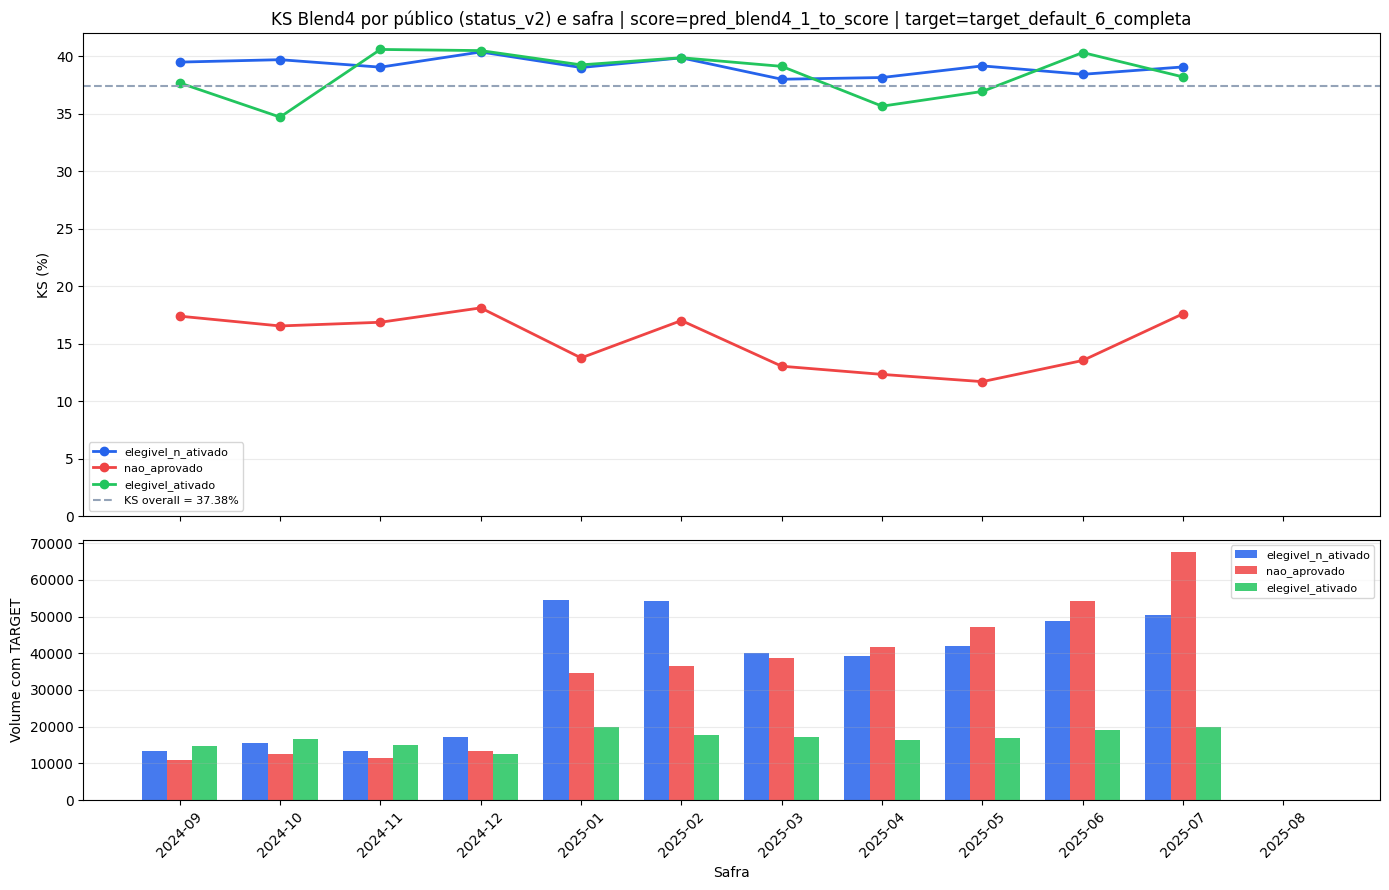

elegivel_n_ativado: KS=38.85% | n=389,109 | default_rate=9.28%
elegivel_ativado: KS=37.94% | n=185,544 | default_rate=6.57%
nao_aprovado: KS=14.72% | n=368,919 | default_rate=21.86%


In [42]:
status_order = (
    df_ks[STATUS_COL]
    .value_counts(dropna=False)
    .index
    .tolist()
)
colors = {
    "elegivel_ativado": "#22C55E",
    "elegivel_n_ativado": "#2563EB",
    "nao_aprovado": "#EF4444",
}

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [0.65, 0.35]},
)
ax_ks, ax_vol = axes

for status in status_order:
    g = ks_by_status_safra[ks_by_status_safra[STATUS_COL] == status].sort_values("safra")
    color = colors.get(status, None)
    ax_ks.plot(
        g["safra"],
        g["ks"],
        marker="o",
        linewidth=2,
        label=status,
        color=color,
    )

ax_ks.axhline(
    ks_overall["ks"],
    color="#94A3B8",
    linestyle="--",
    linewidth=1.5,
    label=f"KS overall = {ks_overall['ks']:.2f}%",
)
ax_ks.set_ylabel("KS (%)")
ax_ks.set_title(
    f"KS Blend4 por público (status_v2) e safra | score={SCORE_COL} | target={TARGET_COL}"
)
ax_ks.legend(loc="best", fontsize=8)
ax_ks.grid(axis="y", alpha=0.25)
ax_ks.set_ylim(bottom=0)

# Stacked-ish grouped bars: volume with TARGET by status × safra
safras = sorted(ks_by_status_safra["safra"].dropna().unique())
x = np.arange(len(safras))
width = 0.25
for i, status in enumerate(status_order):
    g = (
        ks_by_status_safra[ks_by_status_safra[STATUS_COL] == status]
        .set_index("safra")
        .reindex(safras)
    )
    ax_vol.bar(
        x + (i - (len(status_order) - 1) / 2) * width,
        g["n"].fillna(0),
        width=width,
        label=status,
        color=colors.get(status, None),
        alpha=0.85,
    )

ax_vol.set_xticks(x)
ax_vol.set_xticklabels(safras, rotation=45)
ax_vol.set_ylabel("Volume com TARGET")
ax_vol.set_xlabel("Safra")
ax_vol.legend(loc="best", fontsize=8)
ax_vol.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Compact summary labels
for _, row in ks_by_status[ks_by_status[STATUS_COL] != "OVERALL"].iterrows():
    print(
        f"{row[STATUS_COL]}: KS={row['ks']:.2f}% | "
        f"n={int(row['n']):,} | default_rate={row['default_rate']:.2f}%"
    )

### Curva KS (base de desenvolvimento — overall)

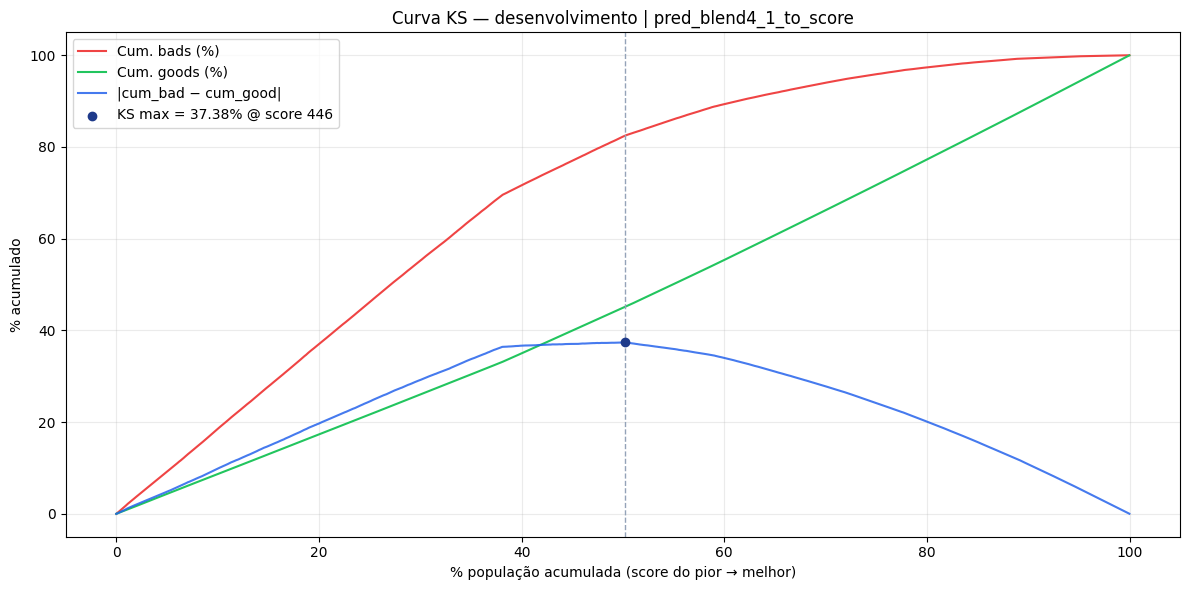

In [43]:
curve = ks_curve_frame(df_ks[TARGET_COL], df_ks[SCORE_COL])

if curve.empty:
    print("Not enough goods/bads to plot KS curve.")
else:
    # Downsample for plotting speed on large development base
    step = max(len(curve) // 2000, 1)
    curve_plot = curve.iloc[::step].copy()
    idx_max = int(curve["ks"].idxmax())

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(curve_plot["pct_pop"] * 100, curve_plot["cum_bad"] * 100, label="Cum. bads (%)", color="#EF4444")
    ax.plot(curve_plot["pct_pop"] * 100, curve_plot["cum_good"] * 100, label="Cum. goods (%)", color="#22C55E")
    ax.plot(curve_plot["pct_pop"] * 100, curve_plot["ks"] * 100, label="|cum_bad − cum_good|", color="#2563EB", alpha=0.85)

    ax.axvline(curve.loc[idx_max, "pct_pop"] * 100, color="#94A3B8", linestyle="--", linewidth=1)
    ax.scatter(
        [curve.loc[idx_max, "pct_pop"] * 100],
        [curve.loc[idx_max, "ks"] * 100],
        color="#1E3A8A",
        zorder=5,
        label=f"KS max = {curve.loc[idx_max, 'ks'] * 100:.2f}% @ score {curve.loc[idx_max, 'score']:.0f}",
    )

    ax.set_xlabel("% população acumulada (score do pior → melhor)")
    ax.set_ylabel("% acumulado")
    ax.set_title(f"Curva KS — desenvolvimento | {SCORE_COL}")
    ax.legend(loc="best")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## Distribuição de Rating (`rating_cl_pol_blend4`)

- **Desenvolvimento:** rating reconstruído com a política (BVS ≤ 334 → `E.E`; demais faixas pelo `pred_blend4_1_to_score`).
- **Produção Blend4:** coluna já existente `rating_cl_pol_blend4`.
- Agregações: **safra** e **semana domingo→sábado**.
- Grupo E = `E-1.E` + `E-2.E` + `E.E`.


In [44]:
from funcoes_monitoramento import prepare_week_columns, plot_mix_and_volume

RATING_COL = "rating_cl_pol_blend4"
RATING_ORDER = [
    "1.A+", "2.A", "3.A", "4.B+", "5.B+", "6.B", "7.B", "8.C",
    "9.D+", "10.D", "11.D", "E-1.E", "E-2.E", "E.E",
]
E_RATINGS = ["E-1.E", "E-2.E", "E.E"]
RATING_COLOR_MAP = {
    "1.A+": "#22D3EE", "2.A": "#38BDF8", "3.A": "#2DD4BF", "4.B+": "#6EE7B7",
    "5.B+": "#86EFAC", "6.B": "#FDE68A", "7.B": "#FCD34D", "8.C": "#FDBA74",
    "9.D+": "#FB923C", "10.D": "#F87171", "11.D": "#EF4444",
    "E-1.E": "#64748B", "E-2.E": "#475569", "E.E": "#1E293B",
}
RATING_TEXT_COLOR_MAP = {**{r: "black" for r in RATING_ORDER[:8]}, **{r: "white" for r in RATING_ORDER[8:]}}


def assign_rating_cl_pol_blend4(df: pd.DataFrame, bvs_col: str = "score_proposto__bvs") -> pd.Series:
    bvs = pd.to_numeric(df[bvs_col], errors="coerce")
    score = pd.to_numeric(df["pred_blend4_1_to_score"], errors="coerce")
    conditions = [
        bvs <= 334,
        score.between(763, 1000), score.between(704, 762), score.between(653, 703),
        score.between(607, 652), score.between(562, 606), score.between(520, 561),
        score.between(480, 519), score.between(443, 479), score.between(408, 442),
        score.between(375, 407), score.between(343, 374), score.between(307, 342),
        score.between(0, 306),
    ]
    choices = ["E.E","1.A+","2.A","3.A","4.B+","5.B+","6.B","7.B","8.C","9.D+","10.D","11.D","E-1.E","E-2.E"]
    return pd.Series(np.select(conditions, choices, default=None), index=df.index)


def rating_mix_table(df: pd.DataFrame, period_col: str):
    work = df.dropna(subset=[RATING_COL, period_col]).copy()
    period_order = sorted(work[period_col].astype(str).unique())
    pct = (
        pd.crosstab(work[period_col].astype(str), work[RATING_COL], normalize="index")
        .mul(100).reindex(index=period_order).reindex(columns=RATING_ORDER, fill_value=0)
    )
    vol = work.groupby(work[period_col].astype(str)).size().reindex(period_order, fill_value=0)
    return pct, vol


def e_breakdown(df: pd.DataFrame, period_col: str) -> pd.DataFrame:
    work = df.dropna(subset=[RATING_COL, period_col]).copy()
    rows = []
    for period, g in work.groupby(period_col, sort=True):
        n = len(g)
        row = {"period": period, "n": n, "pct_E_total": round(100 * g[RATING_COL].isin(E_RATINGS).mean(), 2)}
        for r in E_RATINGS:
            row[f"pct_{r}"] = round(100 * (g[RATING_COL] == r).mean(), 2)
        rows.append(row)
    return pd.DataFrame(rows)


df_rating_dev = df_raw_dev[["contract_id", "requested_at", "safra", "score_proposto__bvs", "pred_blend4_1_to_score"]].copy()
df_rating_dev[RATING_COL] = assign_rating_cl_pol_blend4(df_rating_dev)
df_rating_dev = prepare_week_columns(df_rating_dev, date_col="requested_at")

df_rating_prod = df_blend4_dev.loc[
    df_blend4_dev["message_decisao"] == "BLEND_4",
    ["contract_id", "requested_at", "safra", "score_proposto__bvs", "pred_blend4_1_to_score", RATING_COL],
].copy()
df_rating_prod = prepare_week_columns(df_rating_prod, date_col="requested_at")
df_rating_prod["rating_recomputed"] = assign_rating_cl_pol_blend4(df_rating_prod)
print(f"Prod rating match vs recomputed: {100 * (df_rating_prod[RATING_COL].astype(str) == df_rating_prod['rating_recomputed'].astype(str)).mean():.2f}%")

for label, d in [("development", df_rating_dev), ("production_blend4", df_rating_prod)]:
    s = d[RATING_COL].dropna()
    print(f"{label}: n={len(s):,} | E%={100 * s.isin(E_RATINGS).mean():.2f}")


Prod rating match vs recomputed: 100.00%
development: n=1,070,236 | E%=31.99
production_blend4: n=42,807 | E%=32.13


### Rating por safra


,period,n,pct_E_total,pct_E-1.E,pct_E-2.E,pct_E.E,base
0,2024-09,39121,24.48,5.62,11.16,7.70,development
1,2024-10,44731,25.30,5.78,11.79,7.73,development
2,2024-11,40001,25.53,5.79,12.17,7.57,development
3,2024-12,43060,26.60,6.05,12.65,7.90,development
4,2025-01,109011,29.31,6.29,13.24,9.79,development
5,2025-02,108527,29.14,6.31,13.40,9.44,development
6,2025-03,96018,32.38,6.76,15.26,10.36,development
7,2025-04,97266,33.66,6.99,16.15,10.53,development
8,2025-05,106310,34.91,7.31,17.01,10.59,development
9,2025-06,121861,34.21,6.95,16.37,10.89,development


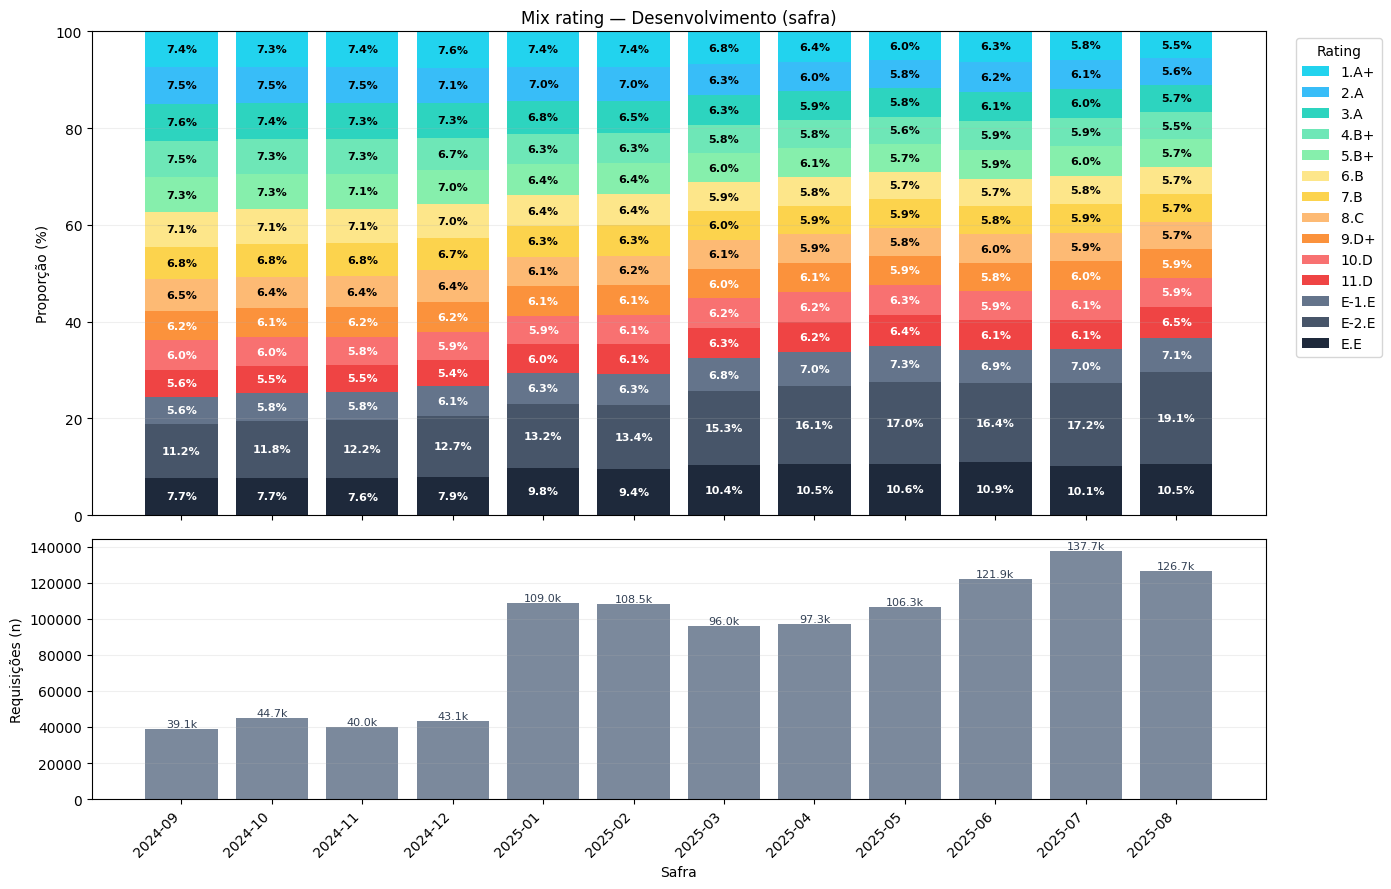

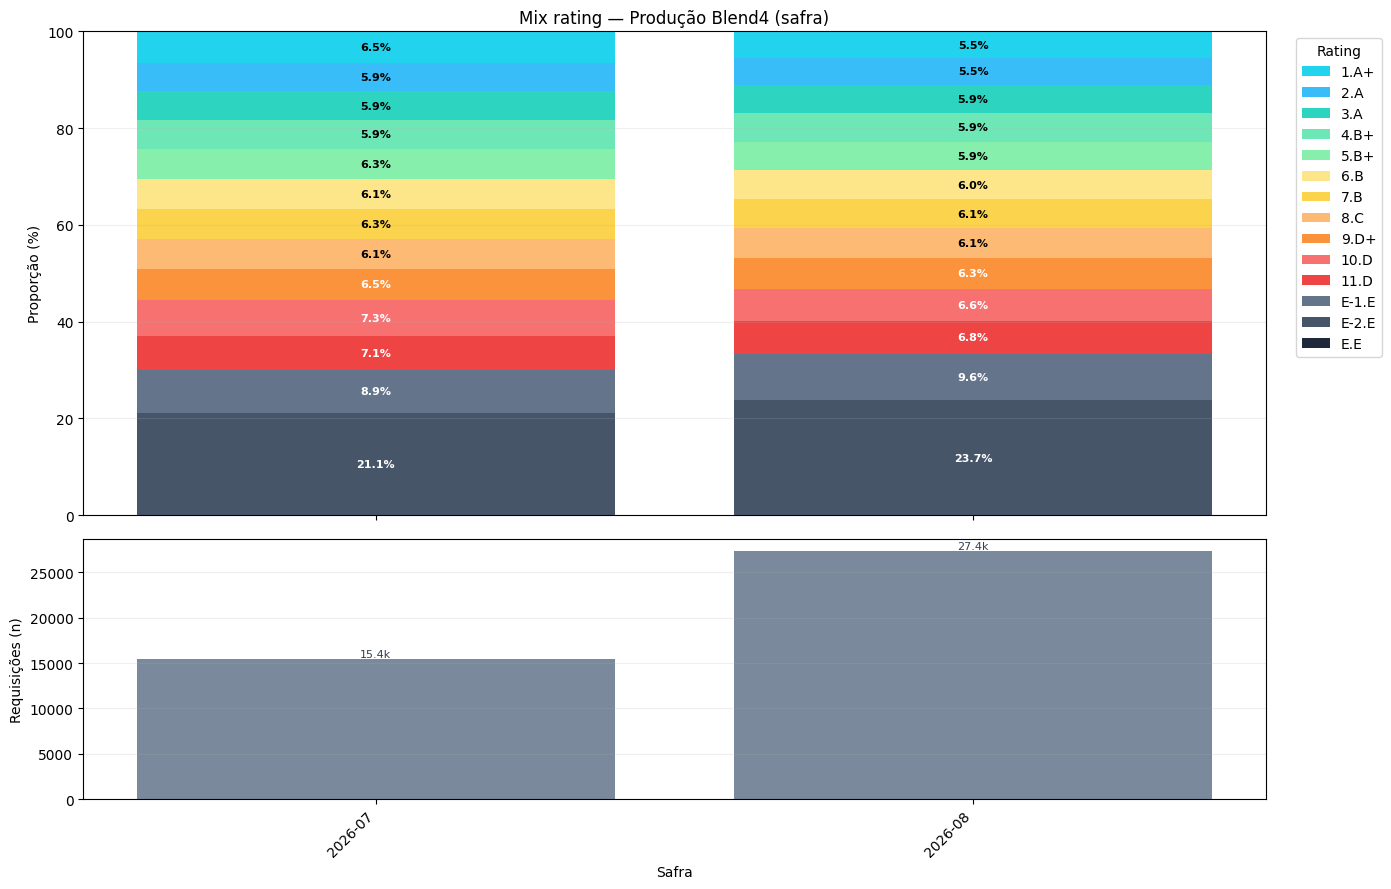

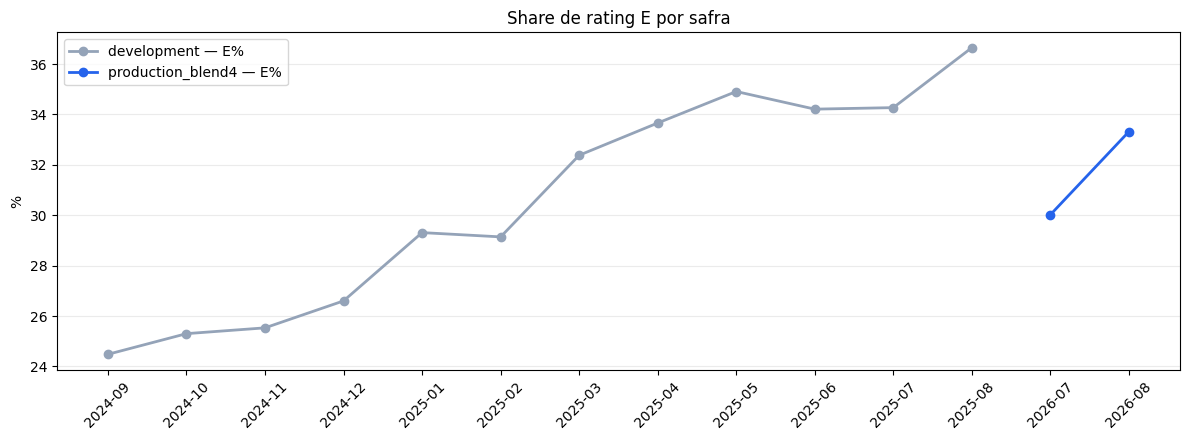

In [45]:
pct_rating_dev_safra, vol_rating_dev_safra = rating_mix_table(df_rating_dev, "safra")
pct_rating_prod_safra, vol_rating_prod_safra = rating_mix_table(df_rating_prod, "safra")
e_safra = pd.concat([
    e_breakdown(df_rating_dev, "safra").assign(base="development"),
    e_breakdown(df_rating_prod, "safra").assign(base="production_blend4"),
], ignore_index=True)
display(e_safra)

plot_mix_and_volume(pct_rating_dev_safra, vol_rating_dev_safra, title="Mix rating — Desenvolvimento (safra)", xlabel="Safra", category_order=RATING_ORDER, color_map=RATING_COLOR_MAP, text_color_map=RATING_TEXT_COLOR_MAP, reverse_stack=True, legend_title="Rating", min_label_pct=4.0)
plt.show()
plot_mix_and_volume(pct_rating_prod_safra, vol_rating_prod_safra, title="Mix rating — Produção Blend4 (safra)", xlabel="Safra", category_order=RATING_ORDER, color_map=RATING_COLOR_MAP, text_color_map=RATING_TEXT_COLOR_MAP, reverse_stack=True, legend_title="Rating", min_label_pct=4.0)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.5))
for base, color in [("development", "#94A3B8"), ("production_blend4", "#2563EB")]:
    g = e_safra[e_safra["base"] == base].sort_values("period")
    ax.plot(g["period"], g["pct_E_total"], marker="o", linewidth=2, color=color, label=f"{base} — E%")
ax.set_title("Share de rating E por safra")
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()


### Rating por semana (domingo→sábado)


,period,n,pct_E_total,pct_E-1.E,pct_E-2.E,pct_E.E,base
53,2026-06-28,390,24.36,5.90,18.46,0.0,production_blend4
54,2026-07-05,2476,32.55,8.97,23.59,0.0,production_blend4
55,2026-07-12,3997,29.25,9.01,20.24,0.0,production_blend4
56,2026-07-19,4182,30.89,9.45,21.45,0.0,production_blend4
57,2026-07-26,4886,29.66,8.78,20.88,0.0,production_blend4
58,2026-08-02,13595,33.78,9.94,23.84,0.0,production_blend4
59,2026-08-09,13139,32.76,9.22,23.53,0.0,production_blend4
60,2026-08-16,142,33.10,7.04,26.06,0.0,production_blend4


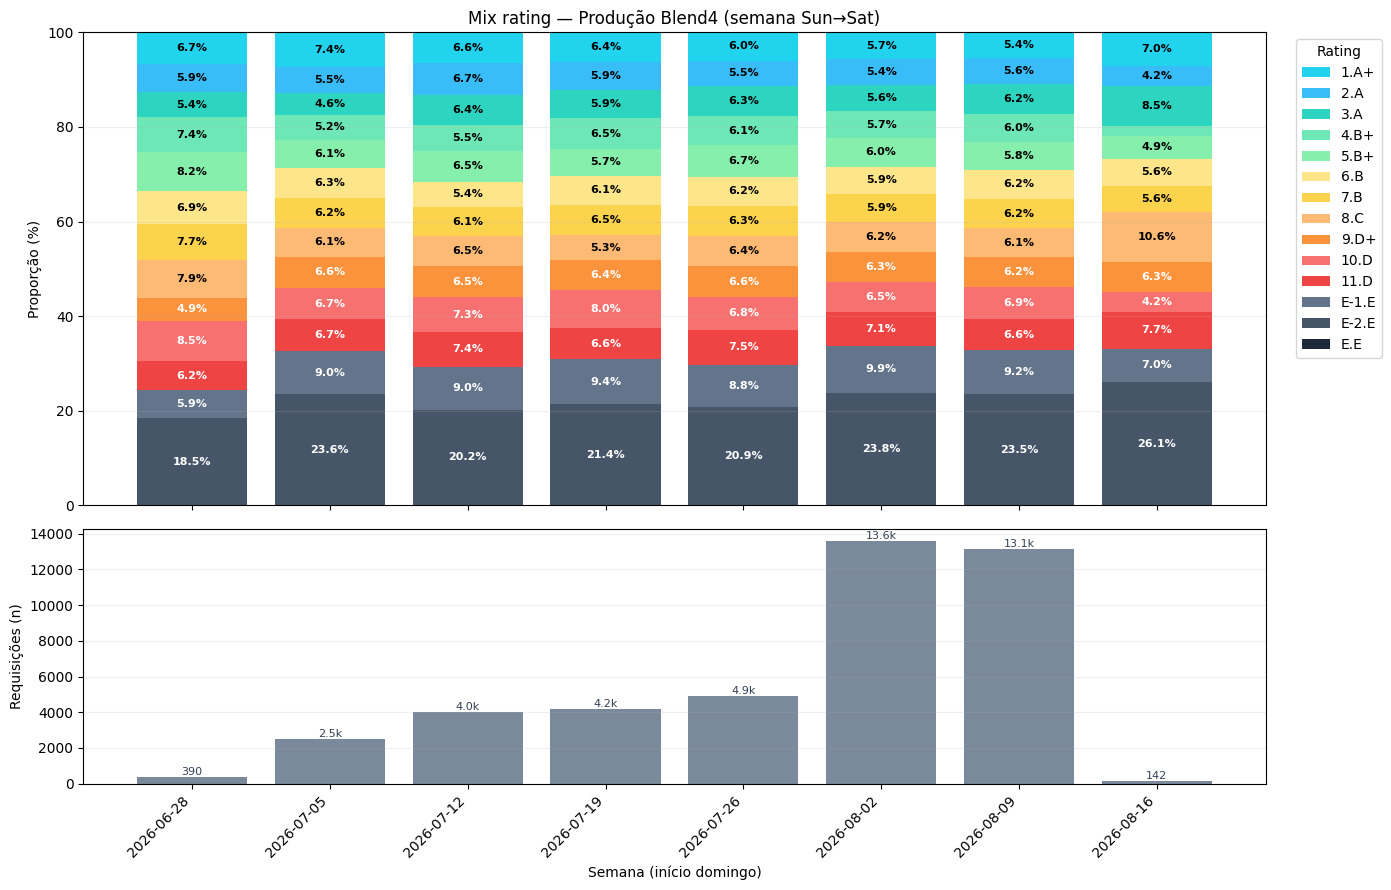

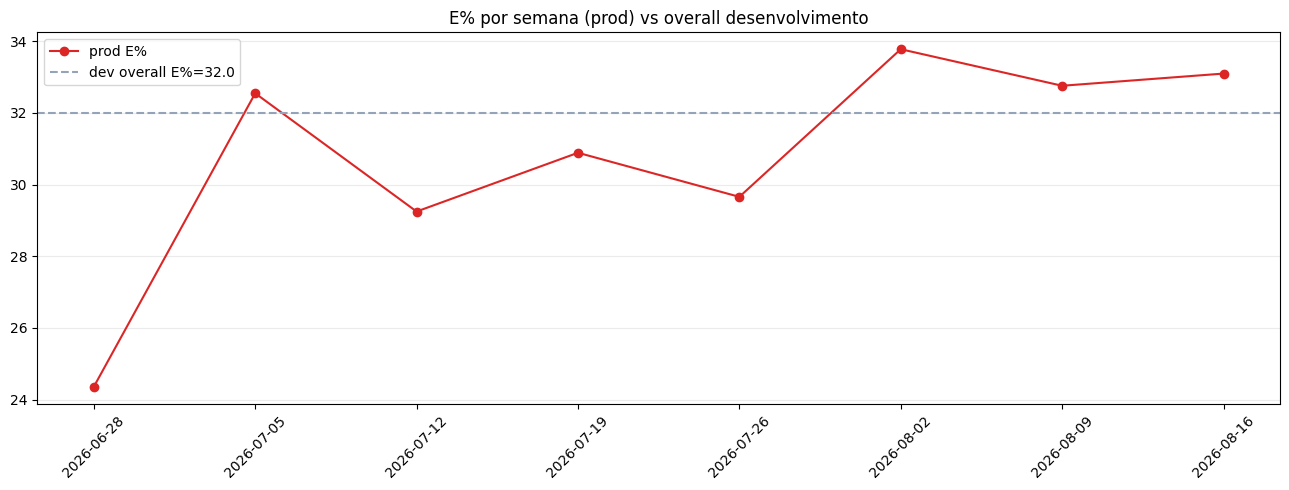

In [46]:
e_week = pd.concat([
    e_breakdown(df_rating_dev, "year_week").assign(base="development"),
    e_breakdown(df_rating_prod, "year_week").assign(base="production_blend4"),
], ignore_index=True)
week_order_prod = (
    df_rating_prod[["year_week", "week_start"]].drop_duplicates().sort_values("week_start")["year_week"].tolist()
)
e_week_prod = e_week[e_week["base"] == "production_blend4"].copy()
e_week_prod["period"] = pd.Categorical(e_week_prod["period"], categories=week_order_prod, ordered=True)
e_week_prod = e_week_prod.sort_values("period")
display(e_week_prod)

pct_rating_prod_week, vol_rating_prod_week = rating_mix_table(df_rating_prod, "year_week")
plot_mix_and_volume(
    pct_rating_prod_week.reindex(week_order_prod),
    vol_rating_prod_week.reindex(week_order_prod, fill_value=0),
    title="Mix rating — Produção Blend4 (semana Sun→Sat)",
    xlabel="Semana (início domingo)",
    category_order=RATING_ORDER, color_map=RATING_COLOR_MAP, text_color_map=RATING_TEXT_COLOR_MAP,
    reverse_stack=True, legend_title="Rating", min_label_pct=4.0,
)
plt.show()

dev_e = 100 * df_rating_dev[RATING_COL].isin(E_RATINGS).mean()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(e_week_prod["period"].astype(str), e_week_prod["pct_E_total"], marker="o", color="#DC2626", label="prod E%")
ax.axhline(dev_e, color="#94A3B8", linestyle="--", label=f"dev overall E%={dev_e:.1f}")
ax.set_title("E% por semana (prod) vs overall desenvolvimento"); ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25); ax.legend(); plt.tight_layout(); plt.show()


## Julho vs Agosto — ramp Blend4 (15% → 50%)

Comparação **somente em produção** (`df_blend4_dev`, `message_decisao == BLEND_4`):

- **Jul/2026:** ~15% Blend4 (volume menor → métricas mais ruidosas)
- **A partir de 01/Ago/2026:** ~50% Blend4 (volume maior)

Semanas = **domingo → sábado**. Sempre olhar **volumetria** junto com PSI / percentis / rating E.


Blend4 share: ~15% in Jul → ~50% from 2026-08-01
Rows Jul: 15,445 | Ago: 27,362


,year_week,week_start,week_end,week_month,n,phase
0,2026-06-28,2026-06-28,2026-07-04,2026-06,390,other
1,2026-07-05,2026-07-05,2026-07-11,2026-07,2476,Jul (~15%)
2,2026-07-12,2026-07-12,2026-07-18,2026-07,3997,Jul (~15%)
3,2026-07-19,2026-07-19,2026-07-25,2026-07,4182,Jul (~15%)
4,2026-07-26,2026-07-26,2026-08-01,2026-07,4886,Jul (~15%)
5,2026-08-02,2026-08-02,2026-08-08,2026-08,13595,Ago (~50%)
6,2026-08-09,2026-08-09,2026-08-15,2026-08,13139,Ago (~50%)
7,2026-08-16,2026-08-16,2026-08-22,2026-08,142,Ago (~50%)


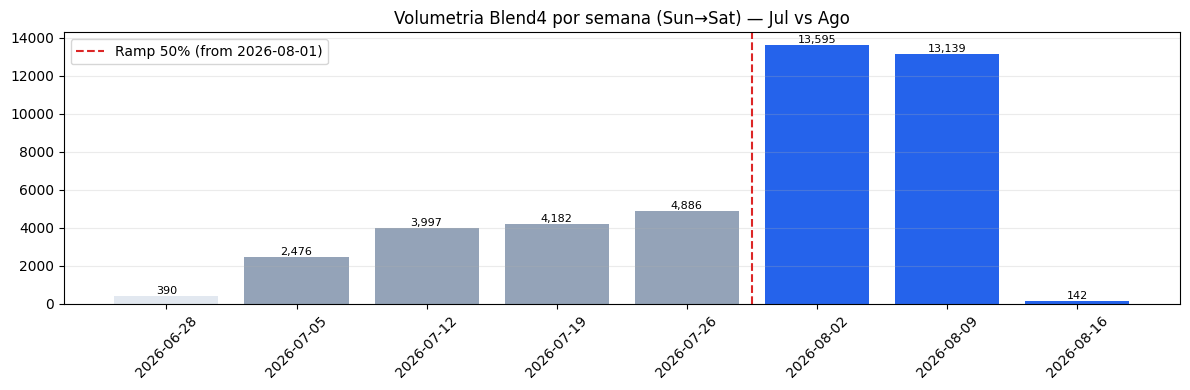

In [47]:
from funcoes_psi import BINARY_MODEL_VARS, build_psi_reference_artifact, calculate_psi_table_from_reference

RAMP_NOTE = "Blend4 share: ~15% in Jul → ~50% from 2026-08-01"
df_ramp = df_blend4_dev.loc[df_blend4_dev["message_decisao"] == "BLEND_4"].copy()
df_ramp["requested_at"] = pd.to_datetime(df_ramp["requested_at"], errors="coerce")
df_ramp = prepare_week_columns(df_ramp, date_col="requested_at")
df_ramp["week_end"] = df_ramp["week_start"] + pd.Timedelta(days=6)
df_ramp["month"] = df_ramp["requested_at"].dt.strftime("%Y-%m")
df_ramp["week_month"] = df_ramp["week_start"].dt.strftime("%Y-%m")

df_jul = df_ramp[df_ramp["month"] == "2026-07"].copy()
df_ago = df_ramp[df_ramp["month"] == "2026-08"].copy()
weeks_ago = sorted(df_ramp.loc[df_ramp["week_month"] == "2026-08", "year_week"].unique())

assert (df_ramp["week_start"].dt.dayofweek == 6).all()
print(RAMP_NOTE)
print(f"Rows Jul: {len(df_jul):,} | Ago: {len(df_ago):,}")

vol_week = (
    df_ramp.groupby(["year_week", "week_start", "week_end", "week_month"], as_index=False)
    .size().rename(columns={"size": "n"}).sort_values("week_start")
)
vol_week["phase"] = np.where(vol_week["week_month"].eq("2026-07"), "Jul (~15%)",
                      np.where(vol_week["week_month"].eq("2026-08"), "Ago (~50%)", "other"))
display(vol_week)

fig, ax = plt.subplots(figsize=(12, 4))
_x = vol_week["year_week"].astype(str).tolist()
colors = vol_week["phase"].map({"Jul (~15%)": "#94A3B8", "Ago (~50%)": "#2563EB", "other": "#E2E8F0"})
ax.bar(_x, vol_week["n"], color=colors)
for _, row in vol_week.iterrows():
    ax.text(str(row["year_week"]), row["n"], f"{int(row['n']):,}", ha="center", va="bottom", fontsize=8)
if "2026-08-02" in _x:
    ax.axvline(_x.index("2026-08-02") - 0.5, color="#DC2626", linestyle="--", linewidth=1.5, label="Ramp 50% (from 2026-08-01)")
ax.set_title("Volumetria Blend4 por semana (Sun→Sat) — Jul vs Ago")
ax.tick_params(axis="x", rotation=45); ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()


### Percentis das `model_vars` — Jul vs Ago (e por semana)


n                 p50  \
base                                                  Ago    Jul          Ago   
variable                                                                        
income                                              27362  15445  3014.000000   
SERASA_CHSV5                                        27362  15445   418.000000   
pred_blend4_1_to_score                              27362  15445   425.000000   
score_proposto__bvs                                 27362  15445   489.000000   
income_commitment                                   27362  15445     0.510949   
age                                                 27362  15445    34.000000   
agency_pc4_mais_100_contratos__pc_categorias        27362  15445     0.129310   
agency_pc4_mais_100_contratos__pc_categorias_is...  27362  15445     1.000000   
city_pc4_mais_100_contratos__pc_categorias          27362  15445     0.102330   
city_pc4_mais_100_contratos__pc_categorias_is_null  27362  15445     0.000000   
flag_tem__contratos_anteriores                      27362  15445     0.000000   
flag_teve_boleto_atrasado__contratos_anteriores     27362  15445     0.000000   
property_type                                       27362  15445     1.000000   
qtde_restricoes__consulta_realizada                 27362  15445     0.000000   
rental_value                                        27362  15445  1600.000000   

                                                                         p75  \
base                                                        Jul          Ago   
variable                                                                       
income                                              3082.500000  5548.500000   
SERASA_CHSV5                                         433.000000   608.000000   
pred_blend4_1_to_score                               437.000000   589.000000   
score_proposto__bvs                                  494.000000   581.750000   
income_commitment                                      0.507775     0.817518   
age                                                   34.000000    46.000000   
agency_pc4_mais_100_contratos__pc_categorias           0.129310     0.129310   
agency_pc4_mais_100_contratos__pc_categorias_is...     1.000000     1.000000   
city_pc4_mais_100_contratos__pc_categorias             0.102330     0.123391   
city_pc4_mais_100_contratos__pc_categorias_is_null     0.000000     0.000000   
flag_tem__contratos_anteriores                         0.000000     0.000000   
flag_teve_boleto_atrasado__contratos_anteriores        0.000000     0.000000   
property_type                                          1.000000     1.000000   
qtde_restricoes__consulta_realizada                    0.000000     2.000000   
rental_value                                        1600.000000  2300.000000   

                                                                 \
base                                                        Jul   
variable                                                          
income                                              5891.000000   
SERASA_CHSV5                                         617.000000   
pred_blend4_1_to_score                               601.000000   
score_proposto__bvs                                  589.000000   
income_commitment                                      0.811030   
age                                                   46.000000   
agency_pc4_mais_100_contratos__pc_categorias           0.129310   
agency_pc4_mais_100_contratos__pc_categorias_is...     1.000000   
city_pc4_mais_100_contratos__pc_categorias             0.119403   
city_pc4_mais_100_contratos__pc_categorias_is_null     0.000000   
flag_tem__contratos_anteriores                         0.000000   
flag_teve_boleto_atrasado__contratos_anteriores        0.000000   
property_type                                          1.000000   
qtde_restricoes__consulta_realizada                    2.000000   
rental_value     

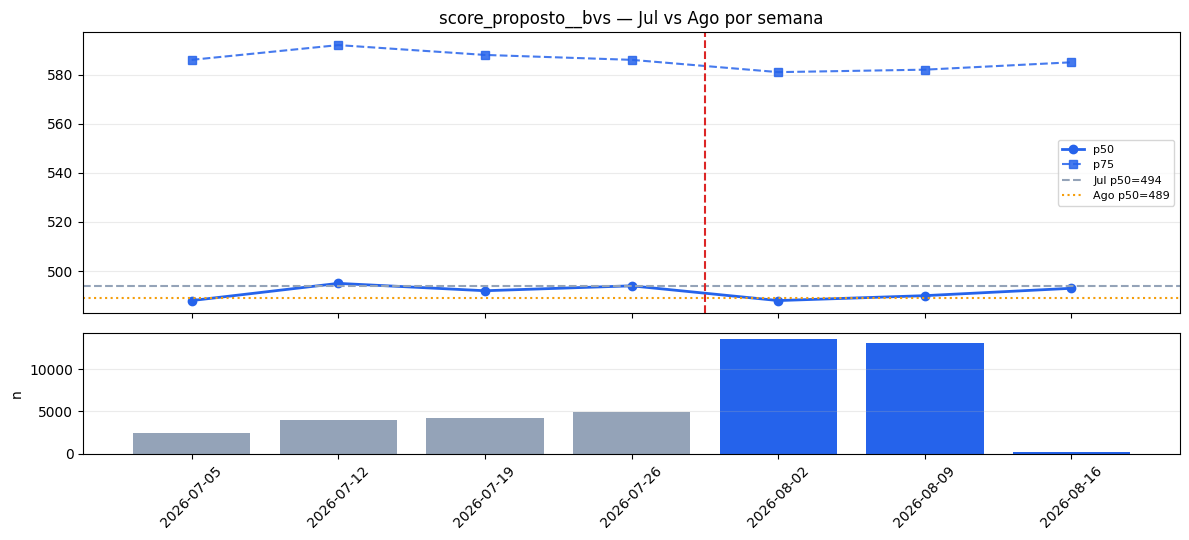

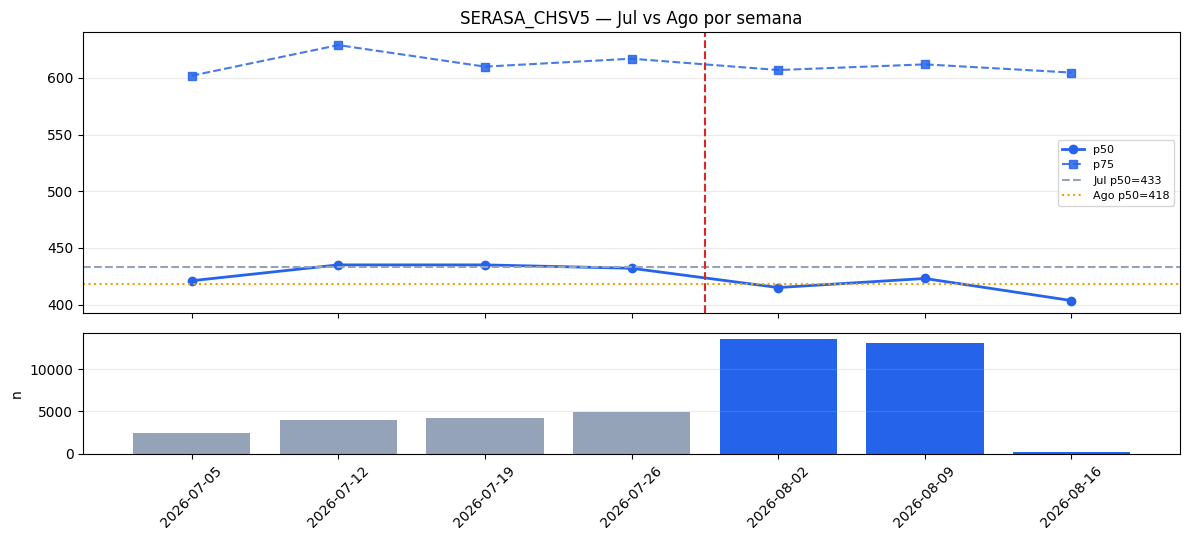

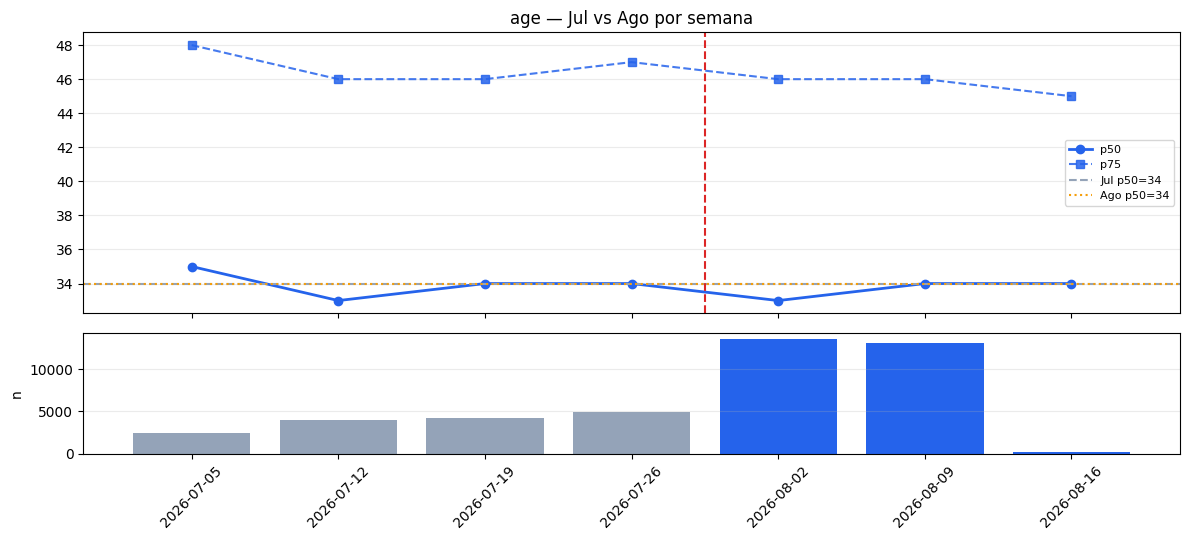

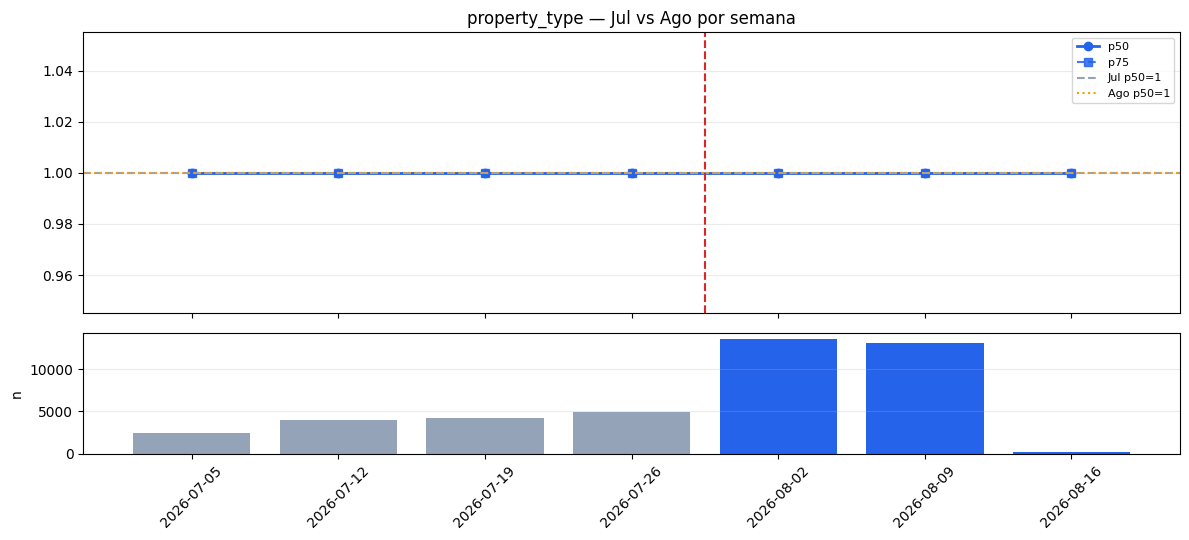

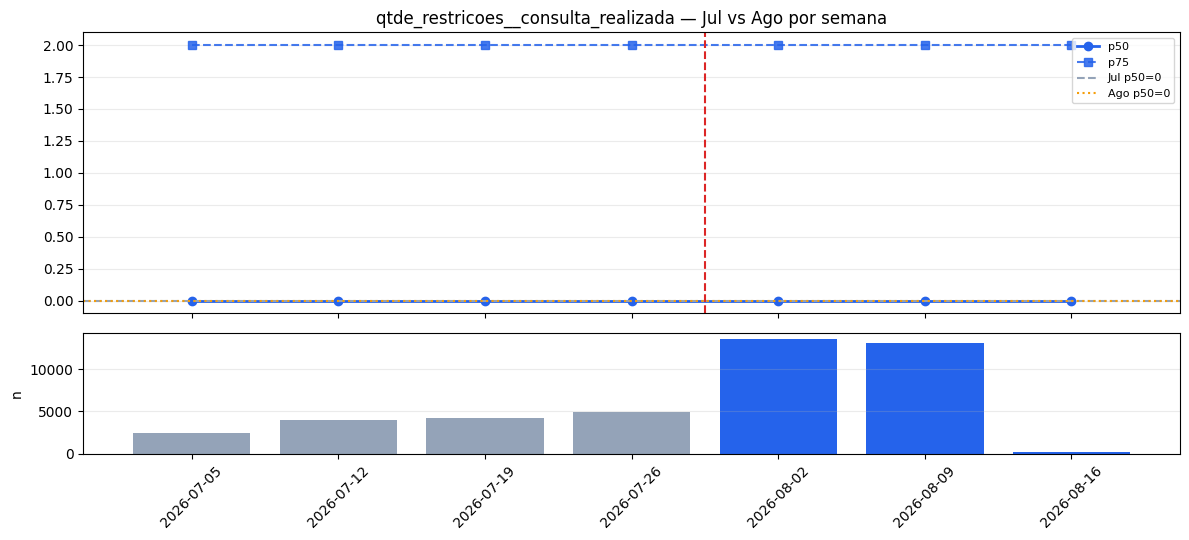

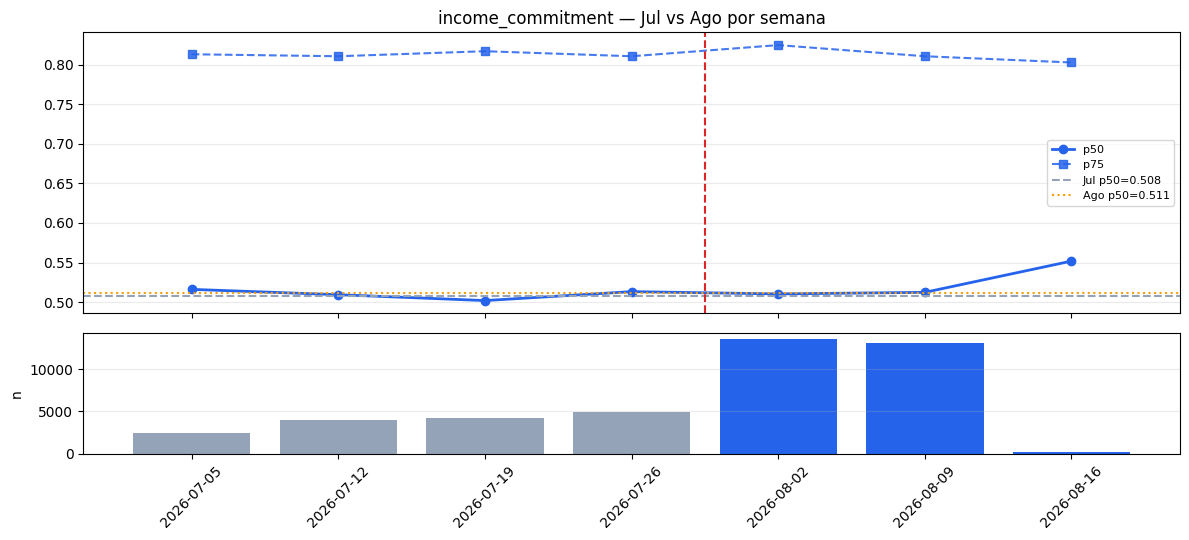

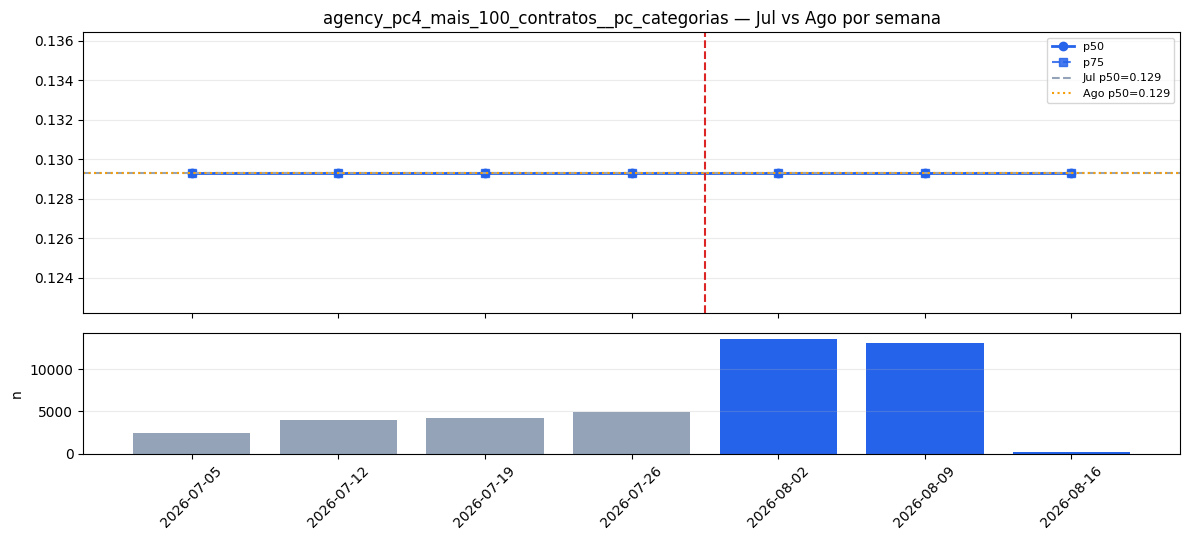

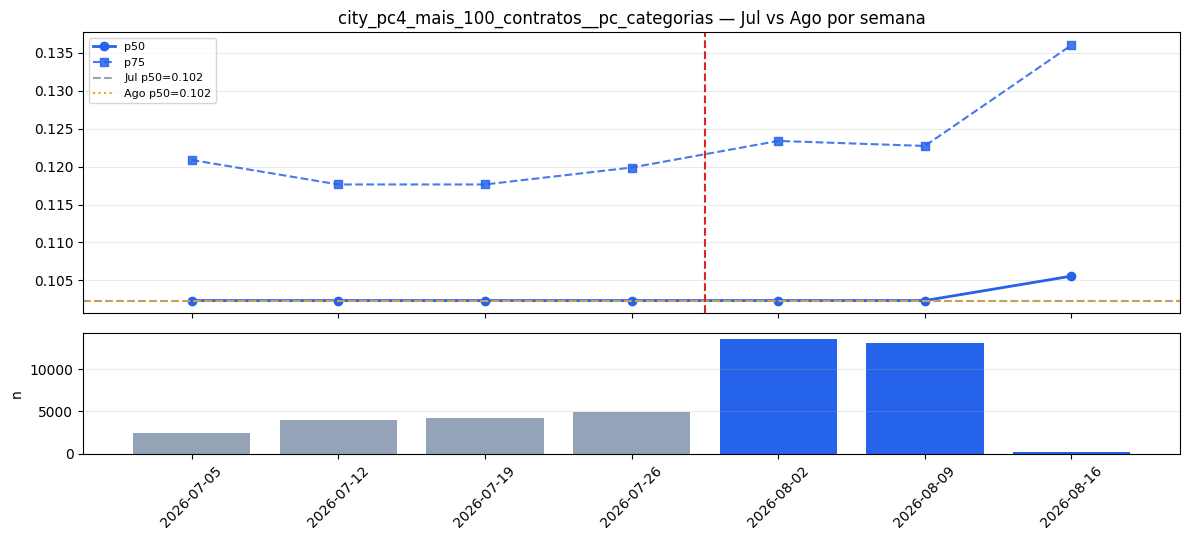

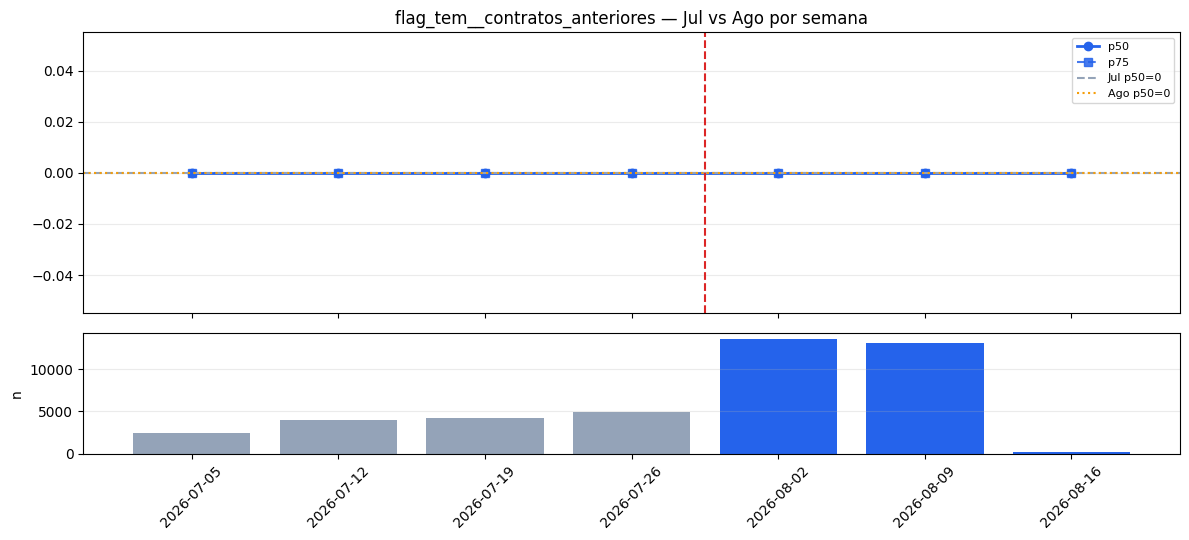

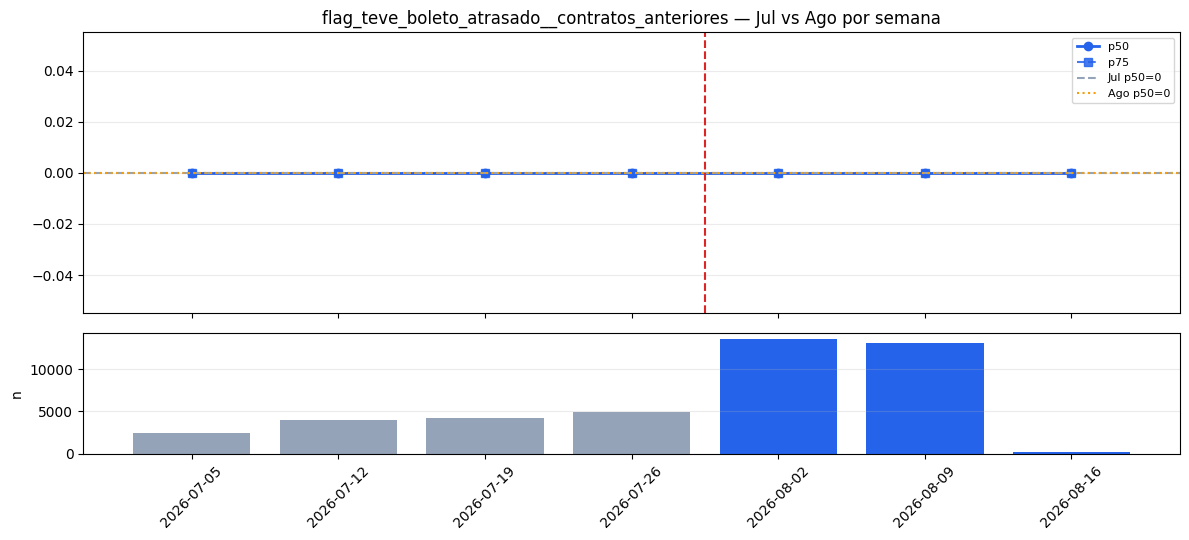

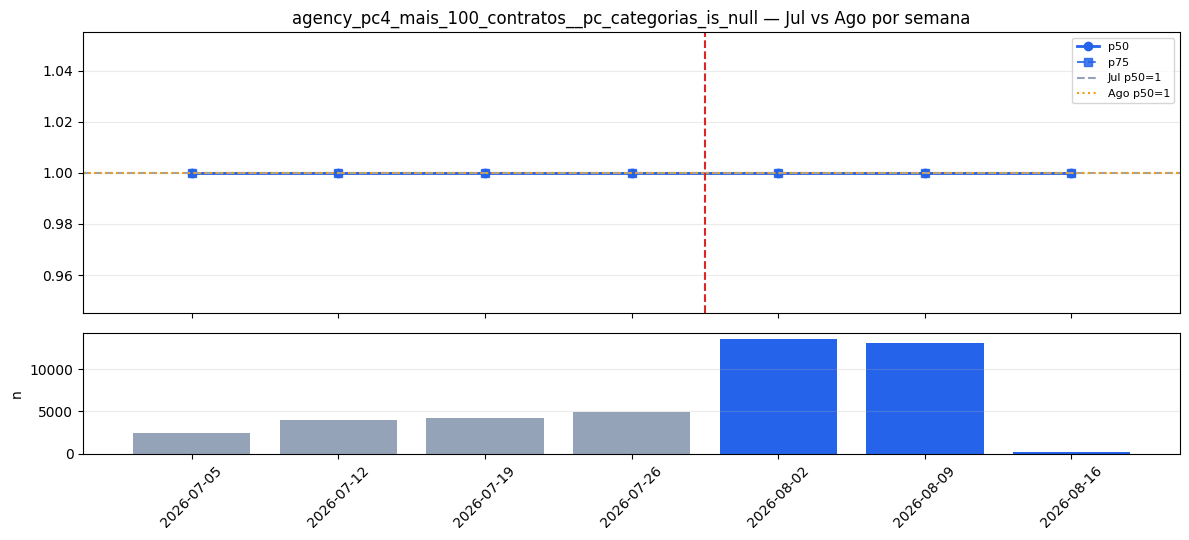

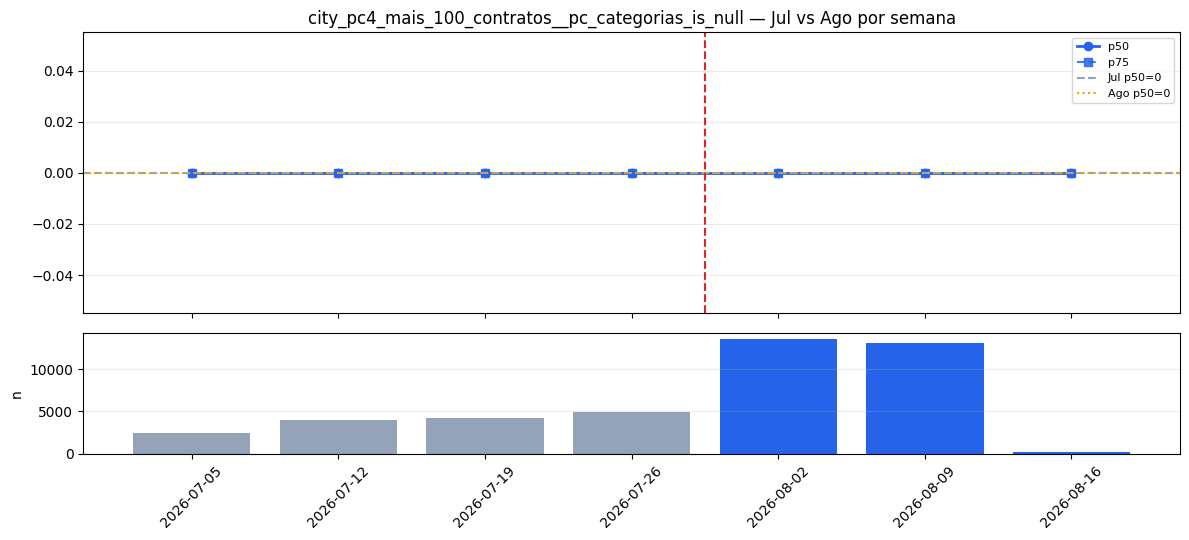

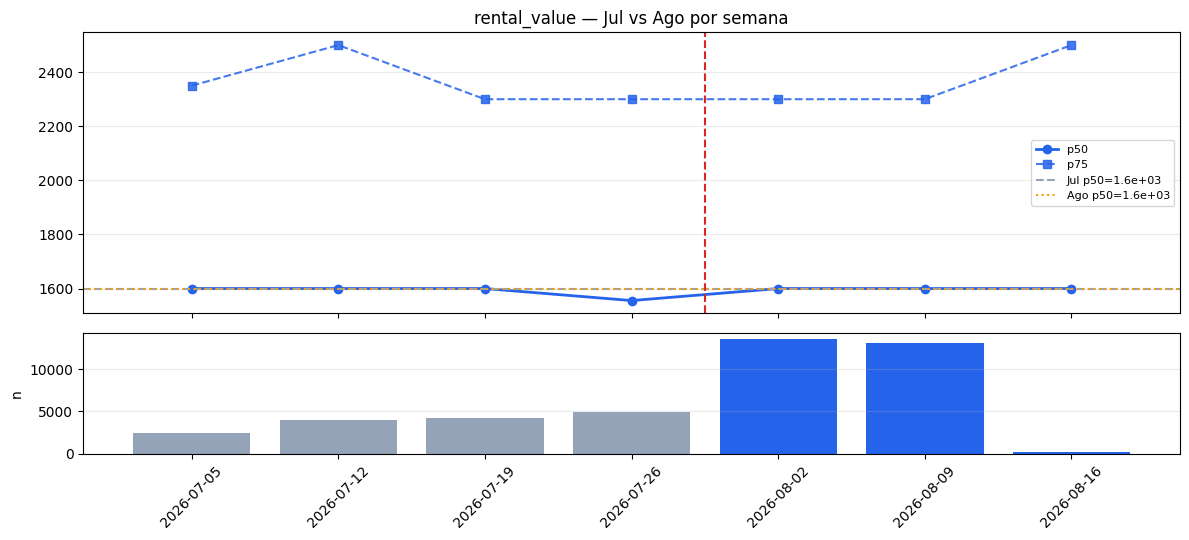

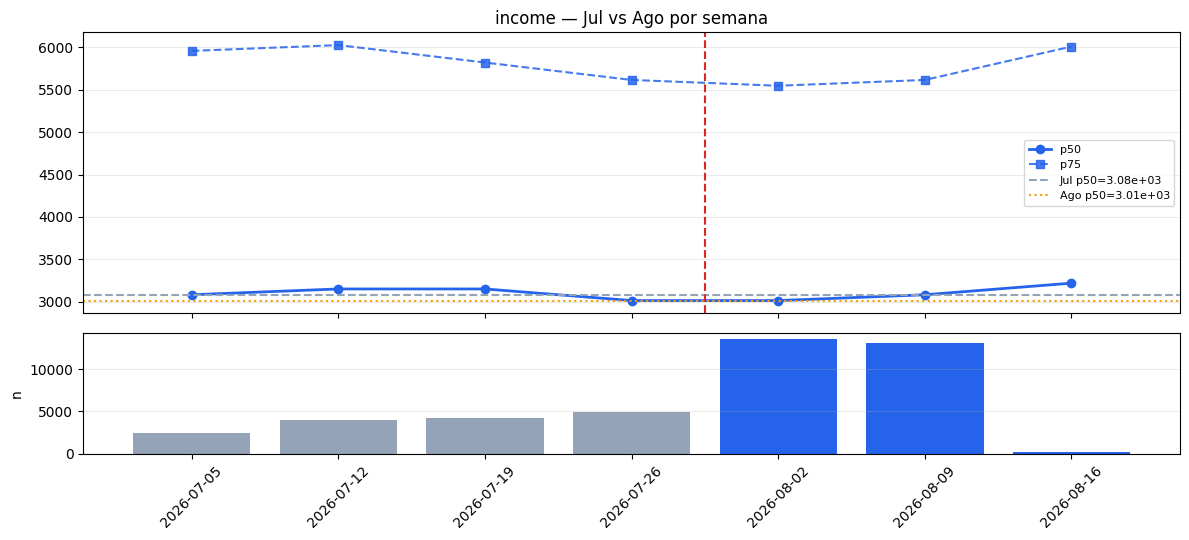

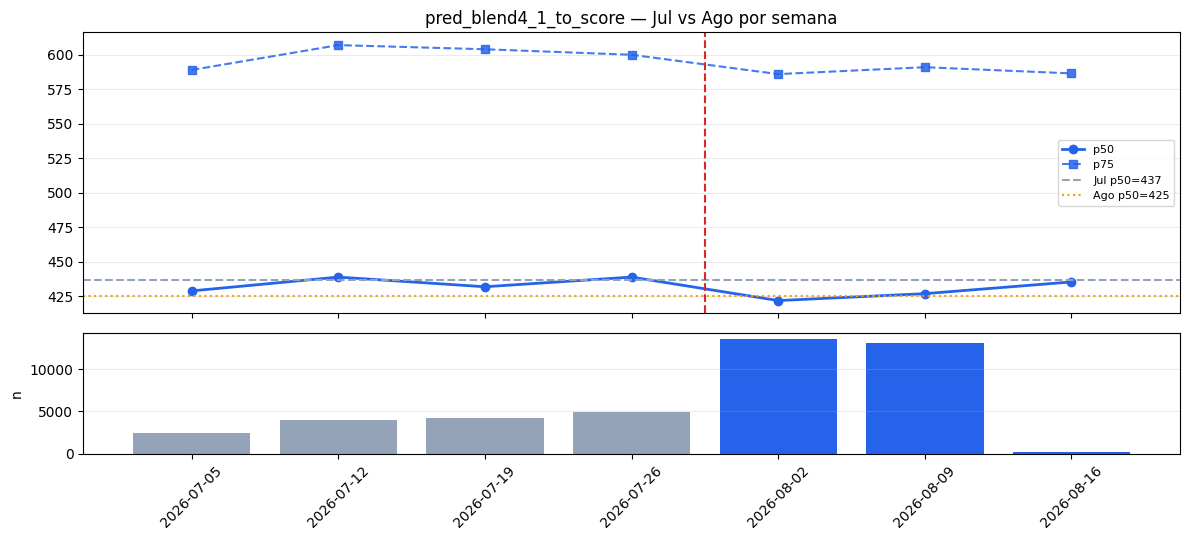

In [48]:
def period_metrics(df, period_col, variables, label):
    rows = []
    for period, g in df.groupby(period_col, sort=True):
        for var in variables:
            if var not in g.columns: continue
            s = pd.to_numeric(g[var], errors="coerce")
            rows.append({"period": period, "variable": var, "base": label, "n": int(s.notna().sum()),
                         "p50": s.quantile(0.50), "p75": s.quantile(0.75)})
    return pd.DataFrame(rows)

cmp_month = pd.concat([
    period_metrics(df_jul.assign(period="2026-07"), "period", model_vars, "Jul"),
    period_metrics(df_ago.assign(period="2026-08"), "period", model_vars, "Ago"),
], ignore_index=True)
month_wide = cmp_month.pivot_table(index="variable", columns="base", values=["n","p50","p75"], aggfunc="first")
month_wide[("p50","diff_ago_minus_jul")] = month_wide[("p50","Ago")] - month_wide[("p50","Jul")]
month_wide[("p75","diff_ago_minus_jul")] = month_wide[("p75","Ago")] - month_wide[("p75","Jul")]
display(month_wide.sort_values(("p50","diff_ago_minus_jul"), key=lambda s: s.abs(), ascending=False))

df_ramp_ja = df_ramp[df_ramp["week_month"].isin(["2026-07","2026-08"])].copy()
cmp_week = period_metrics(df_ramp_ja, "year_week", model_vars, "prod")
week_vol = df_ramp_ja.groupby("year_week").size()
week_order = (df_ramp_ja[["year_week","week_start"]].drop_duplicates().sort_values("week_start")["year_week"].astype(str).tolist())
METRIC_STYLE = {"p50":{"linestyle":"-","marker":"o","alpha":1.0}, "p75":{"linestyle":"--","marker":"s","alpha":0.85}}

for var in model_vars:
    g = cmp_week[cmp_week["variable"]==var].copy()
    g["period"]=g["period"].astype(str)
    g=g.set_index("period").reindex(week_order).reset_index()
    fig, axes = plt.subplots(2,1,figsize=(12,5.5), sharex=True, gridspec_kw={"height_ratios":[0.7,0.3]})
    ax, ax_vol = axes
    for metric, style in METRIC_STYLE.items():
        ax.plot(g["period"], g[metric], color="#2563EB", linewidth=2 if metric=="p50" else 1.5, label=metric, **style)
    jul_p50 = cmp_month[(cmp_month.variable==var)&(cmp_month.base=="Jul")]["p50"]
    ago_p50 = cmp_month[(cmp_month.variable==var)&(cmp_month.base=="Ago")]["p50"]
    if len(jul_p50): ax.axhline(float(jul_p50.iloc[0]), color="#94A3B8", linestyle="--", label=f"Jul p50={float(jul_p50.iloc[0]):.3g}")
    if len(ago_p50): ax.axhline(float(ago_p50.iloc[0]), color="#F59E0B", linestyle=":", label=f"Ago p50={float(ago_p50.iloc[0]):.3g}")
    if "2026-08-02" in week_order: ax.axvline(week_order.index("2026-08-02")-0.5, color="#DC2626", linestyle="--")
    ax.set_title(f"{var} — Jul vs Ago por semana"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25)
    ax_vol.bar(week_order, [int(week_vol.get(w,0)) for w in week_order],
               color=["#94A3B8" if w < "2026-08-02" else "#2563EB" for w in week_order])
    ax_vol.set_ylabel("n"); ax_vol.tick_params(axis="x", rotation=45); ax_vol.grid(axis="y", alpha=0.25)
    plt.tight_layout(); plt.show()


### Foco — `city_pc4_mais_100_contratos__pc_categorias` (maior variação Jul → Ago)

Progressão semanal em produção Blend4 (domingo→sábado): **um gráfico para p50** e **outro para p75**. Linha vermelha = início do ramp ~50% (01/Ago).


,year_week,phase,n,p50,p75,delta_p50,delta_p75
0,2026-07-05,Jul (~15%),2476,0.1023,0.1209,NaN,NaN
1,2026-07-12,Jul (~15%),3997,0.1023,0.1176,0.0000,-0.0033
2,2026-07-19,Jul (~15%),4182,0.1023,0.1176,0.0000,0.0000
3,2026-07-26,Jul (~15%),4886,0.1023,0.1199,0.0000,0.0023
4,2026-08-02,Ago (~50%),13595,0.1023,0.1234,0.0000,0.0035
5,2026-08-09,Ago (~50%),13139,0.1023,0.1227,0.0000,-0.0007
6,2026-08-16,Ago (~50%),142,0.1056,0.1360,0.0033,0.0133


city_pc4_mais_100_contratos__pc_categorias
  Jul: n=15,445 | p50=0.1023 | p75=0.1194
  Ago: n=27,362 | p50=0.1023 | p75=0.1234
  Δ (Ago−Jul): p50=+0.0000 | p75=+0.0040


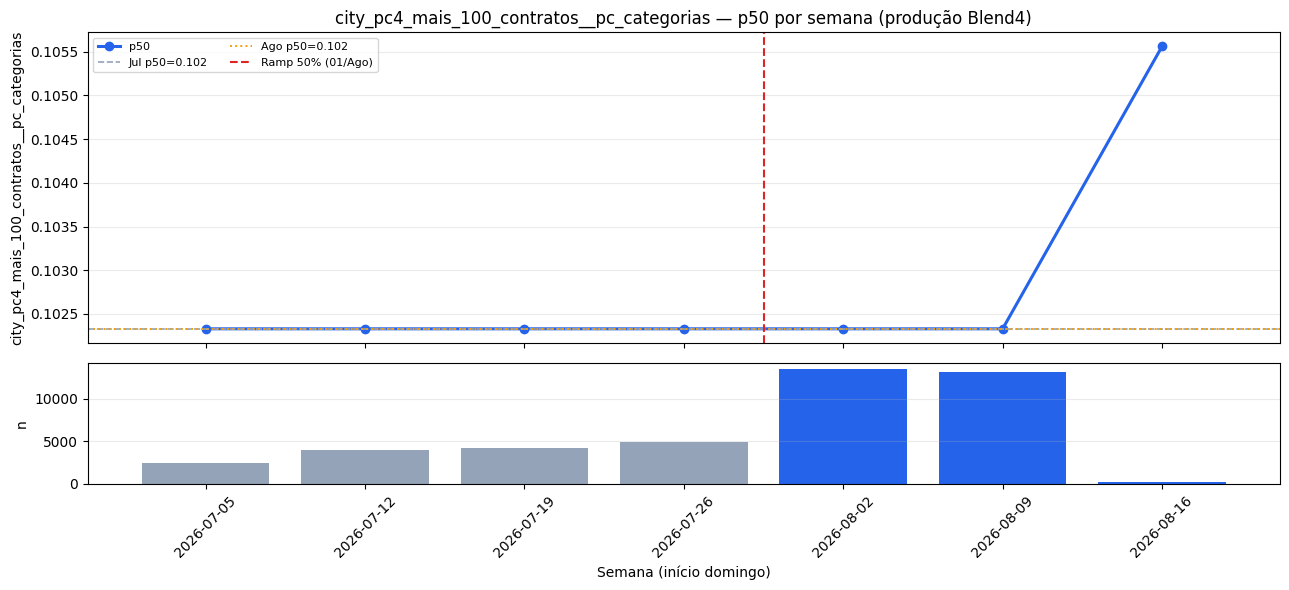

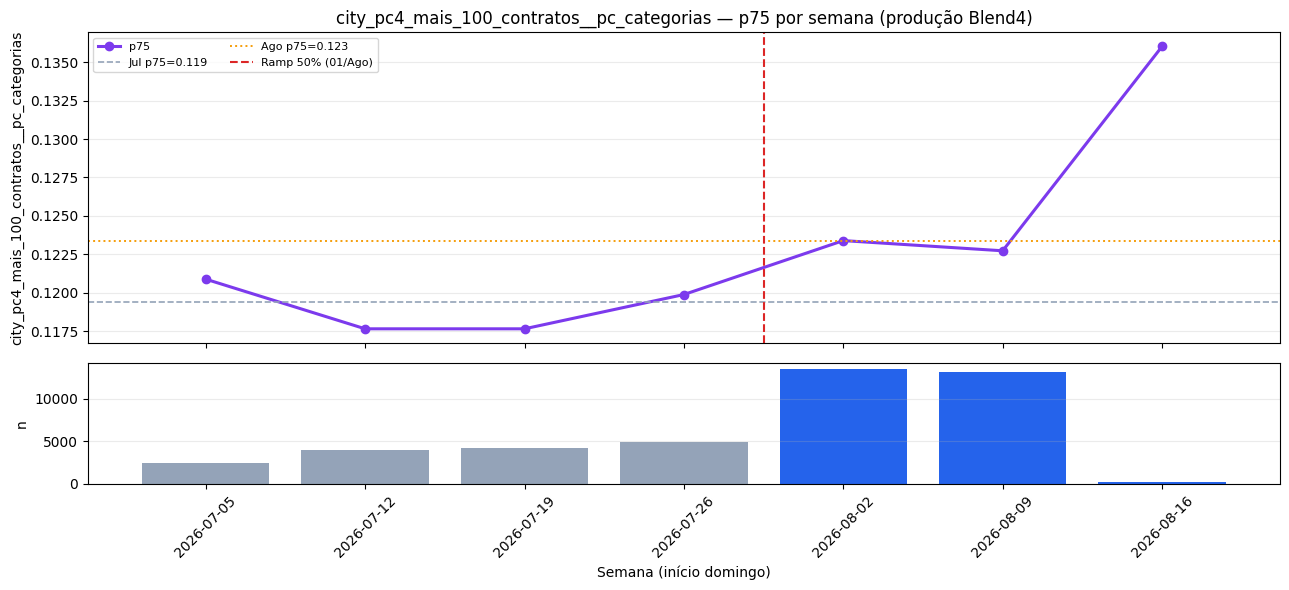

In [49]:
FOCUS_VAR = "city_pc4_mais_100_contratos__pc_categorias"

g = cmp_week[cmp_week["variable"] == FOCUS_VAR].copy()
g["period"] = g["period"].astype(str)
g = g.set_index("period").reindex(week_order).reset_index()
g["n"] = g["period"].map(lambda w: int(week_vol.get(w, 0)) if pd.notna(w) else 0)
g["phase"] = np.where(g["period"].astype(str) < "2026-08-02", "Jul (~15%)", "Ago (~50%)")

# Weekly table (progression)
display(
    g[["period", "phase", "n", "p50", "p75"]]
    .assign(
        p50=lambda d: d["p50"].round(4),
        p75=lambda d: d["p75"].round(4),
        delta_p50=lambda d: d["p50"].diff().round(4),
        delta_p75=lambda d: d["p75"].diff().round(4),
    )
    .rename(columns={"period": "year_week"})
)

jul_row = cmp_month[(cmp_month["variable"] == FOCUS_VAR) & (cmp_month["base"] == "Jul")].iloc[0]
ago_row = cmp_month[(cmp_month["variable"] == FOCUS_VAR) & (cmp_month["base"] == "Ago")].iloc[0]
print(
    f"{FOCUS_VAR}\n"
    f"  Jul: n={int(jul_row['n']):,} | p50={jul_row['p50']:.4f} | p75={jul_row['p75']:.4f}\n"
    f"  Ago: n={int(ago_row['n']):,} | p50={ago_row['p50']:.4f} | p75={ago_row['p75']:.4f}\n"
    f"  Δ (Ago−Jul): p50={ago_row['p50'] - jul_row['p50']:+.4f} | p75={ago_row['p75'] - jul_row['p75']:+.4f}"
)

# Separate charts: one for p50, one for p75
x = g["period"].astype(str).tolist()
bar_colors = ["#94A3B8" if p < "2026-08-02" else "#2563EB" for p in x]
ramp_idx = x.index("2026-08-02") - 0.5 if "2026-08-02" in x else None

for metric, color, jul_val, ago_val in [
    ("p50", "#2563EB", float(jul_row["p50"]), float(ago_row["p50"])),
    ("p75", "#7C3AED", float(jul_row["p75"]), float(ago_row["p75"])),
]:
    fig, axes = plt.subplots(
        2, 1, figsize=(13, 6.0), sharex=True, gridspec_kw={"height_ratios": [0.72, 0.28]}
    )
    ax, ax_vol = axes

    ax.plot(x, g[metric], color=color, marker="o", linewidth=2.2, label=metric)
    ax.axhline(jul_val, color="#94A3B8", linestyle="--", linewidth=1.2, label=f"Jul {metric}={jul_val:.3g}")
    ax.axhline(ago_val, color="#F59E0B", linestyle=":", linewidth=1.4, label=f"Ago {metric}={ago_val:.3g}")
    if ramp_idx is not None:
        ax.axvline(ramp_idx, color="#DC2626", linestyle="--", linewidth=1.5, label="Ramp 50% (01/Ago)")

    ax.set_title(f"{FOCUS_VAR} — {metric} por semana (produção Blend4)")
    ax.set_ylabel(FOCUS_VAR)
    ax.legend(loc="best", fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.25)

    ax_vol.bar(x, g["n"].fillna(0).astype(int), color=bar_colors)
    ax_vol.set_ylabel("n")
    ax_vol.set_xlabel("Semana (início domingo)")
    ax_vol.tick_params(axis="x", rotation=45)
    ax_vol.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()


### Foco — deciles p10…p90 de `city_pc4_mais_100_contratos__pc_categorias`

Mesma progressão semanal (produção Blend4, domingo→sábado): **um gráfico por percentil** (p10, p20, …, p90). Linha vermelha = início do ramp ~50% (01/Ago).

,year_week,phase,n,p10,p20,p30,p40,p50,p60,p70,p80,p90
0,2026-07-05,Jul (~15%),2476,0.0685,0.0797,0.0870,0.0929,0.1023,0.1069,0.1130,0.1309,0.1478
1,2026-07-12,Jul (~15%),3997,0.0690,0.0783,0.0866,0.0894,0.1023,0.1026,0.1094,0.1231,0.1458
2,2026-07-19,Jul (~15%),4182,0.0692,0.0786,0.0870,0.0936,0.1023,0.1027,0.1094,0.1239,0.1474
3,2026-07-26,Jul (~15%),4886,0.0690,0.0777,0.0861,0.0947,0.1023,0.1045,0.1122,0.1244,0.1478
4,2026-08-02,Ago (~50%),13595,0.0740,0.0828,0.0914,0.0976,0.1023,0.1082,0.1158,0.1308,0.1554
5,2026-08-09,Ago (~50%),13139,0.0740,0.0825,0.0914,0.0947,0.1023,0.1082,0.1155,0.1308,0.1557
6,2026-08-16,Ago (~50%),142,0.0813,0.0848,0.0917,0.1023,0.1056,0.1197,0.1332,0.1478,0.1597


city_pc4_mais_100_contratos__pc_categorias
  Jul: n=15,445 | p10=0.0681 | p20=0.0783 | p30=0.0870 | p40=0.0907 | p50=0.1023 | p60=0.1045 | p70=0.1111 | p80=0.1239 | p90=0.1478
  Ago: n=27,362 | p10=0.0740 | p20=0.0825 | p30=0.0914 | p40=0.0969 | p50=0.1023 | p60=0.1082 | p70=0.1158 | p80=0.1308 | p90=0.1554
  Δ (Ago−Jul): p10=+0.0059 | p20=+0.0042 | p30=+0.0045 | p40=+0.0062 | p50=+0.0000 | p60=+0.0037 | p70=+0.0047 | p80=+0.0069 | p90=+0.0076


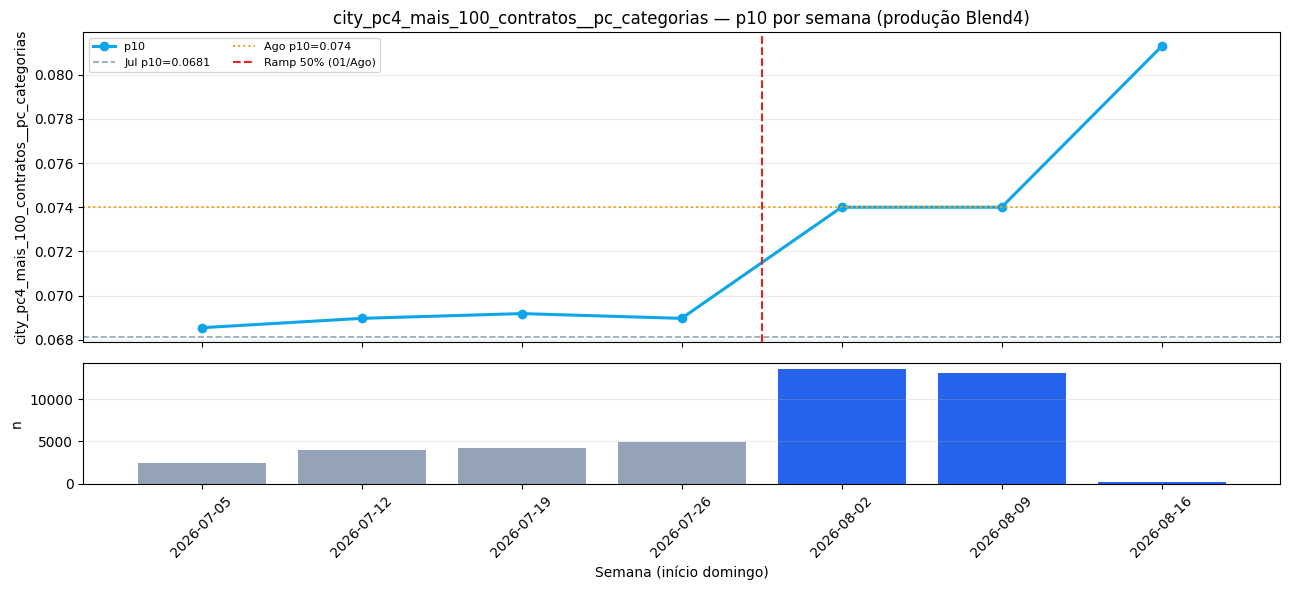

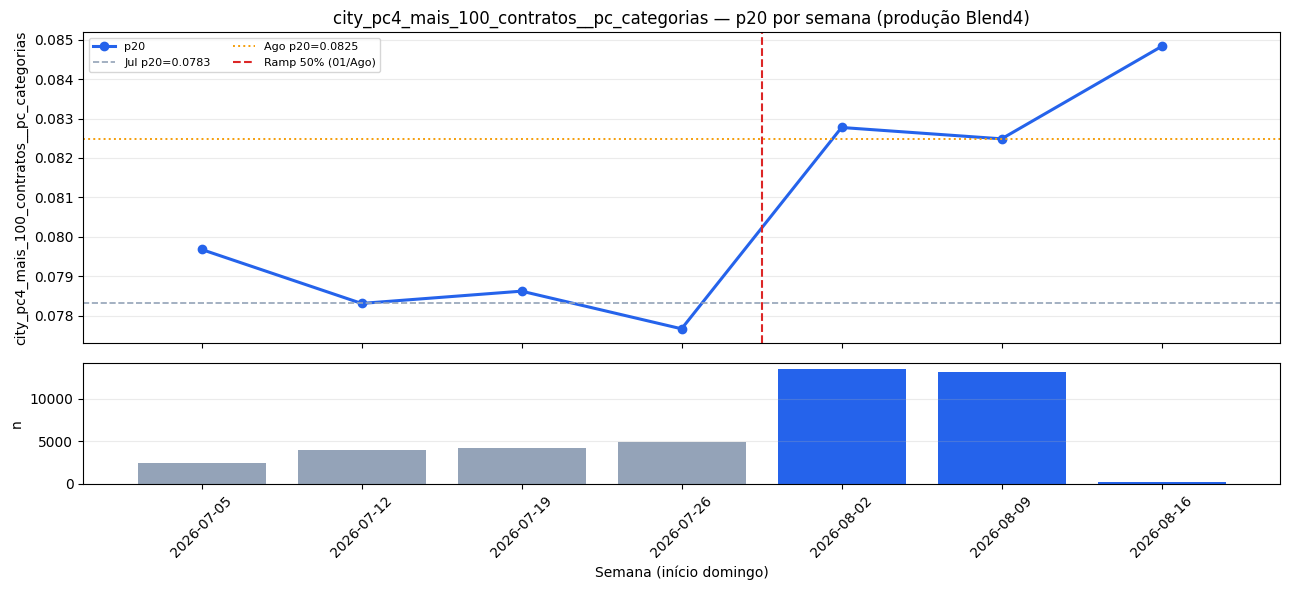

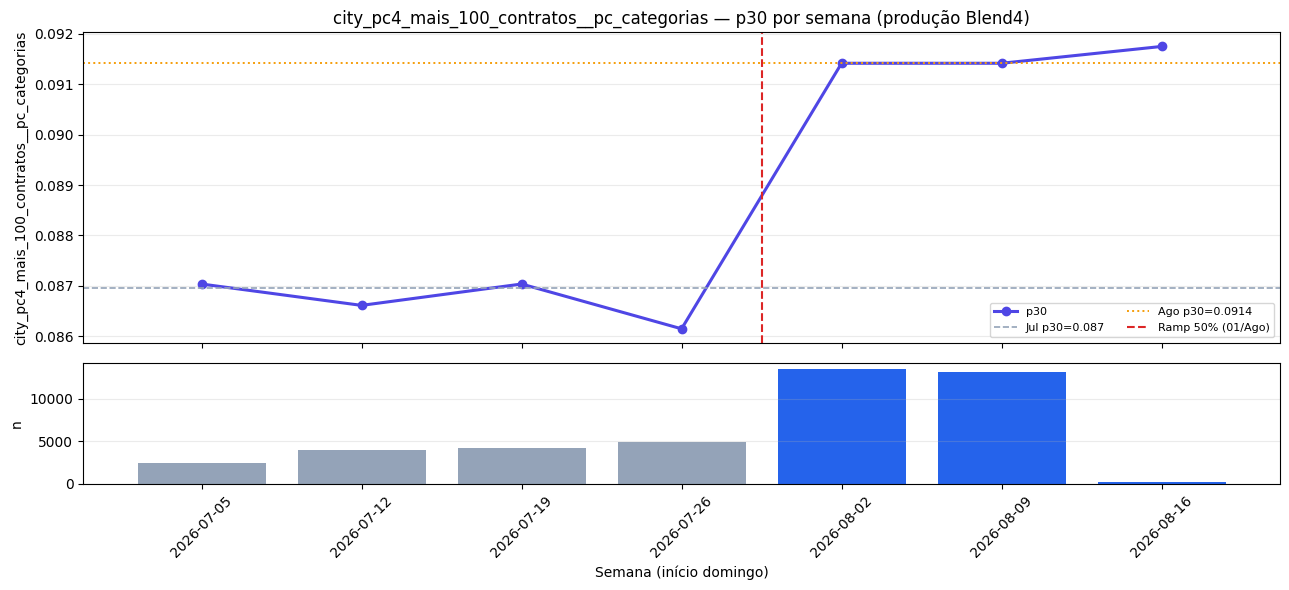

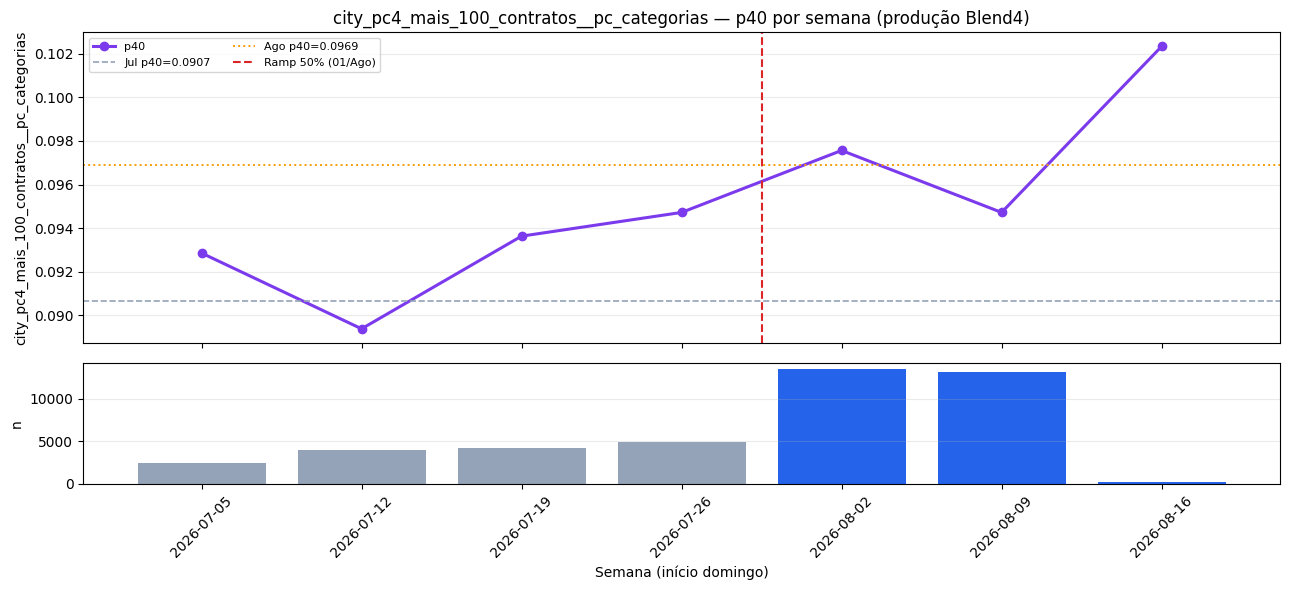

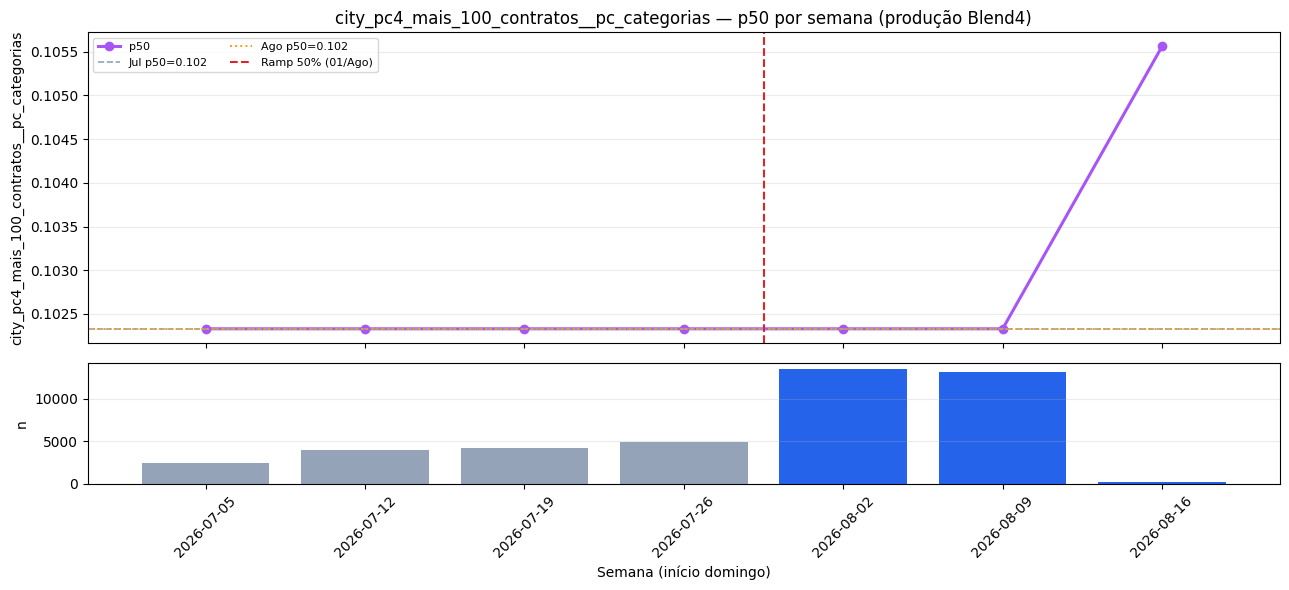

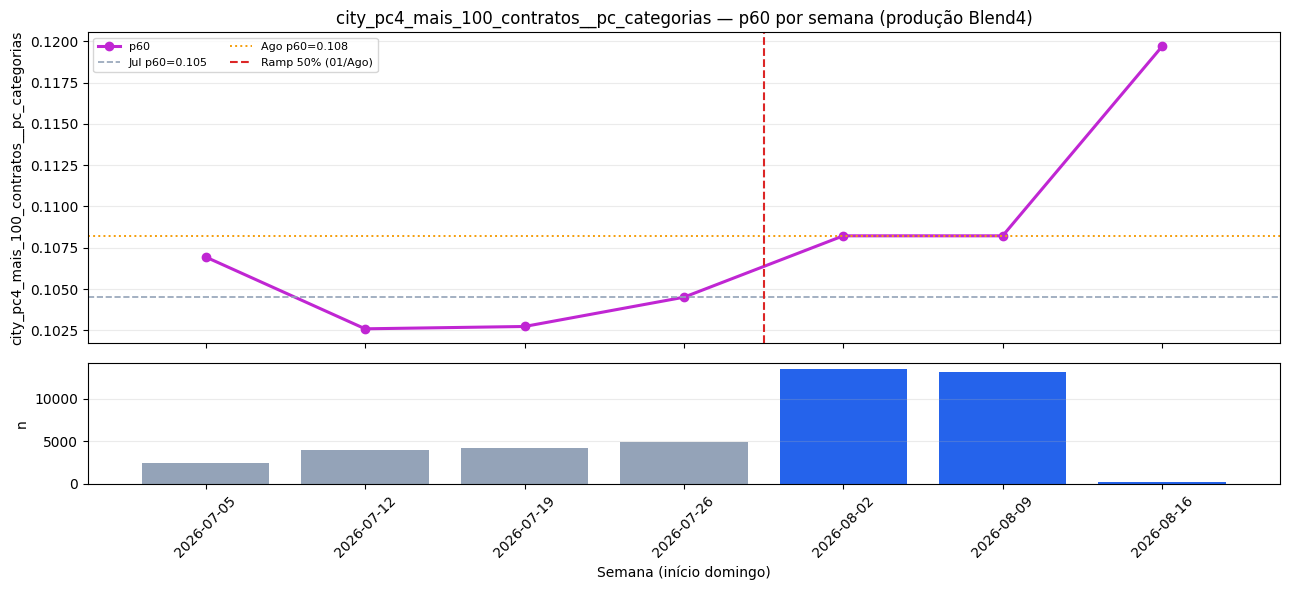

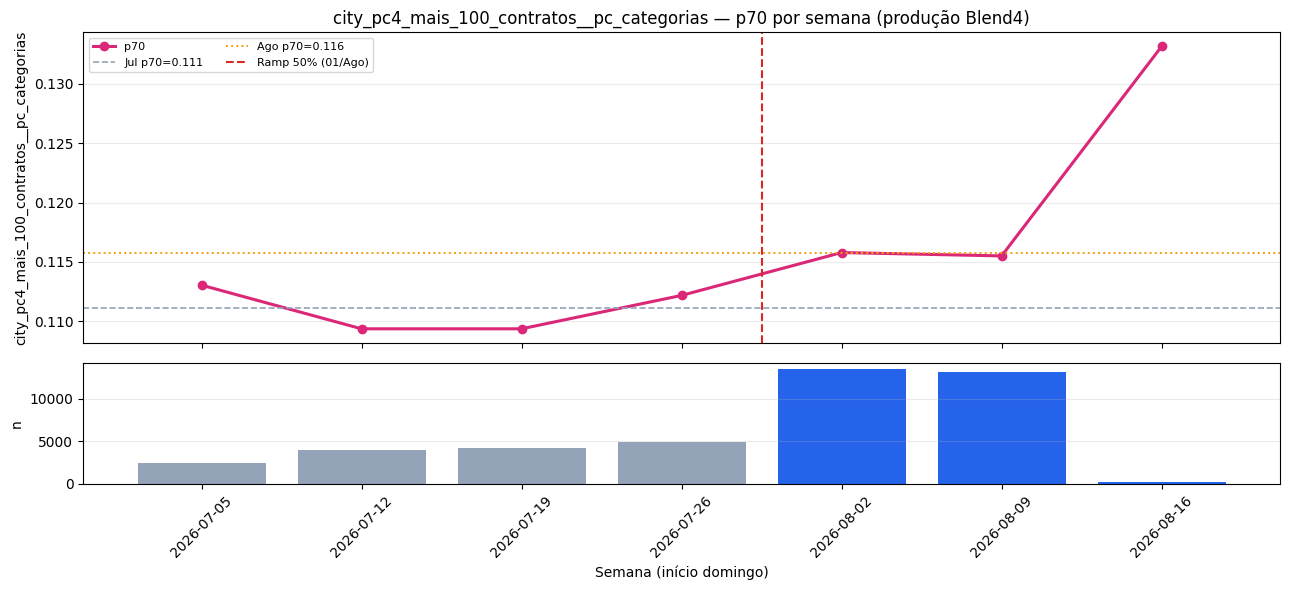

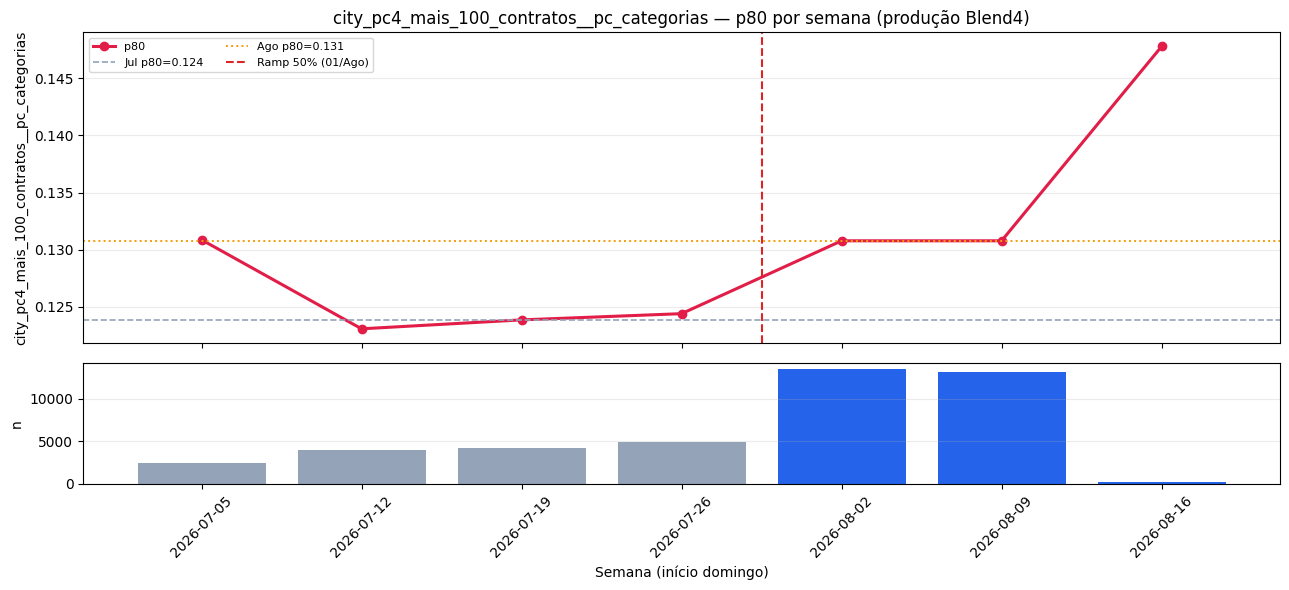

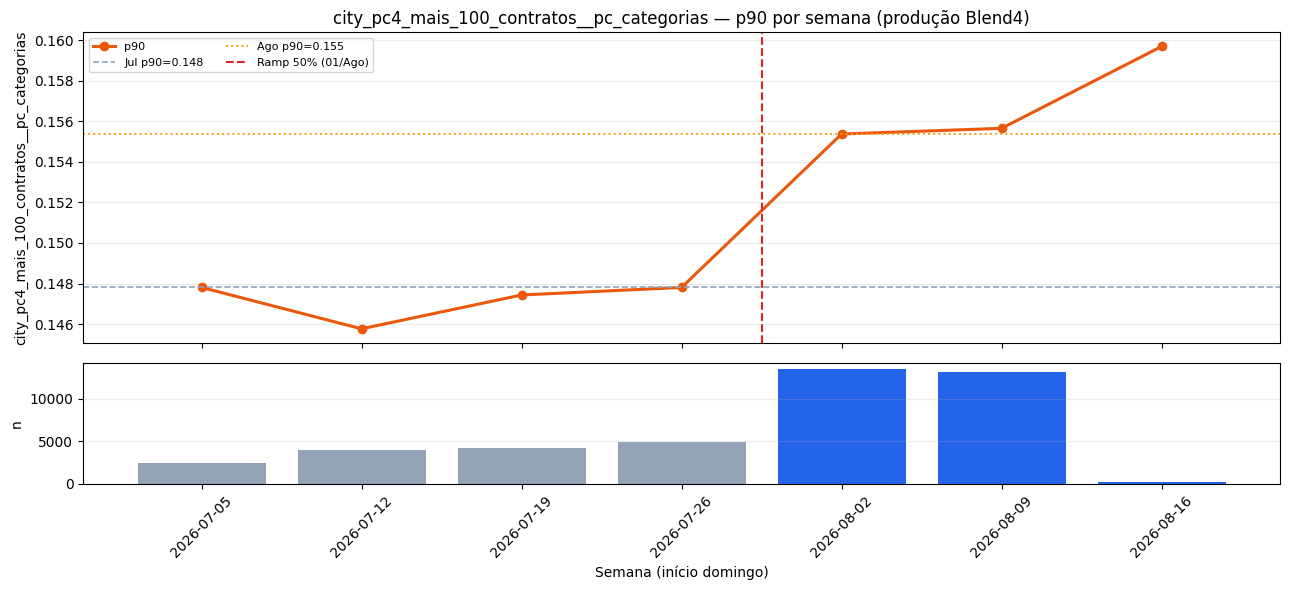

In [50]:
FOCUS_VAR = "city_pc4_mais_100_contratos__pc_categorias"
DECILES = [i / 10 for i in range(1, 10)]
DEC_COLS = [f"p{int(p * 100)}" for p in DECILES]
DEC_COLORS = [
    "#0EA5E9",
    "#2563EB",
    "#4F46E5",
    "#7C3AED",
    "#A855F7",
    "#C026D3",
    "#DB2777",
    "#E11D48",
    "#EA580C",
]


def _percentile_stats(s: pd.Series) -> dict:
    s = pd.to_numeric(s, errors="coerce")
    out = {"n": int(s.notna().sum())}
    for p, col in zip(DECILES, DEC_COLS):
        out[col] = float(s.quantile(p))
    return out


rows = []
for period, grp in df_ramp_ja.groupby("year_week", sort=True):
    rows.append({"period": period, **_percentile_stats(grp[FOCUS_VAR])})

g = pd.DataFrame(rows)
g["period"] = g["period"].astype(str)
g = g.set_index("period").reindex(week_order).reset_index()
g["n"] = g["period"].map(lambda w: int(week_vol.get(w, 0)) if pd.notna(w) else 0)
g["phase"] = np.where(g["period"].astype(str) < "2026-08-02", "Jul (~15%)", "Ago (~50%)")

table = g[["period", "phase", "n"] + DEC_COLS].copy()
for col in DEC_COLS:
    table[col] = table[col].round(4)
display(table.rename(columns={"period": "year_week"}))

jul_stats = _percentile_stats(df_jul[FOCUS_VAR])
ago_stats = _percentile_stats(df_ago[FOCUS_VAR])
print(
    f"{FOCUS_VAR}\n"
    f"  Jul: n={jul_stats['n']:,} | "
    + " | ".join(f"{c}={jul_stats[c]:.4f}" for c in DEC_COLS)
    + "\n"
    f"  Ago: n={ago_stats['n']:,} | "
    + " | ".join(f"{c}={ago_stats[c]:.4f}" for c in DEC_COLS)
    + "\n"
    "  Δ (Ago−Jul): "
    + " | ".join(f"{c}={ago_stats[c] - jul_stats[c]:+.4f}" for c in DEC_COLS)
)

x = g["period"].astype(str).tolist()
bar_colors = ["#94A3B8" if p < "2026-08-02" else "#2563EB" for p in x]
ramp_idx = x.index("2026-08-02") - 0.5 if "2026-08-02" in x else None

for metric, color in zip(DEC_COLS, DEC_COLORS):
    jul_val = jul_stats[metric]
    ago_val = ago_stats[metric]
    fig, axes = plt.subplots(
        2, 1, figsize=(13, 6.0), sharex=True, gridspec_kw={"height_ratios": [0.72, 0.28]}
    )
    ax, ax_vol = axes

    ax.plot(x, g[metric], color=color, marker="o", linewidth=2.2, label=metric)
    ax.axhline(jul_val, color="#94A3B8", linestyle="--", linewidth=1.2, label=f"Jul {metric}={jul_val:.3g}")
    ax.axhline(ago_val, color="#F59E0B", linestyle=":", linewidth=1.4, label=f"Ago {metric}={ago_val:.3g}")
    if ramp_idx is not None:
        ax.axvline(ramp_idx, color="#DC2626", linestyle="--", linewidth=1.5, label="Ramp 50% (01/Ago)")

    ax.set_title(f"{FOCUS_VAR} — {metric} por semana (produção Blend4)")
    ax.set_ylabel(FOCUS_VAR)
    ax.legend(loc="best", fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.25)

    ax_vol.bar(x, g["n"].fillna(0).astype(int), color=bar_colors)
    ax_vol.set_ylabel("n")
    ax_vol.set_xlabel("Semana (início domingo)")
    ax_vol.tick_params(axis="x", rotation=45)
    ax_vol.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()


## Renda

,year_week,phase,n,p50,p75,delta_p50,delta_p75
0,2026-07-05,Jul (~15%),2476,3082.5,5959.500,NaN,NaN
1,2026-07-12,Jul (~15%),3997,3151.0,6028.000,68.5,68.500
2,2026-07-19,Jul (~15%),4182,3151.0,5822.500,0.0,-205.500
3,2026-07-26,Jul (~15%),4886,3014.0,5617.000,-137.0,-205.500
4,2026-08-02,Ago (~50%),13595,3014.0,5548.500,0.0,-68.500
5,2026-08-09,Ago (~50%),13139,3082.5,5617.000,68.5,68.500
6,2026-08-16,Ago (~50%),142,3219.5,6010.875,137.0,393.875


income
  Jul: n=15,445 | p50=3082.5000 | p75=5891.0000
  Ago: n=27,362 | p50=3014.0000 | p75=5548.5000
  Δ (Ago−Jul): p50=-68.5000 | p75=-342.5000


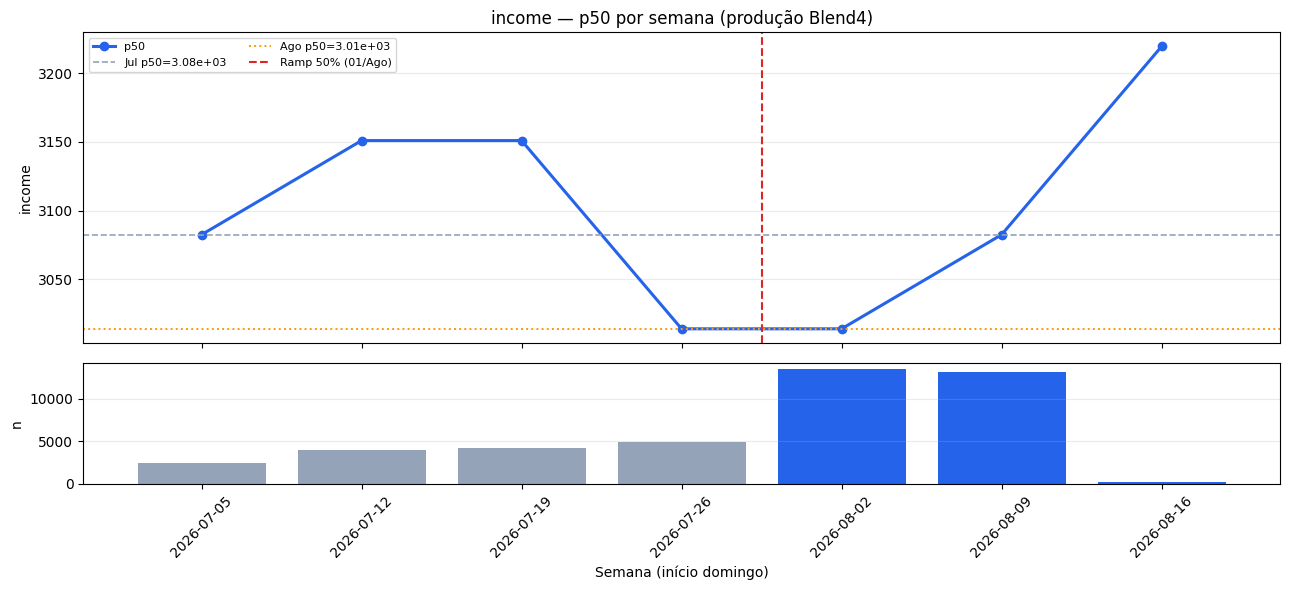

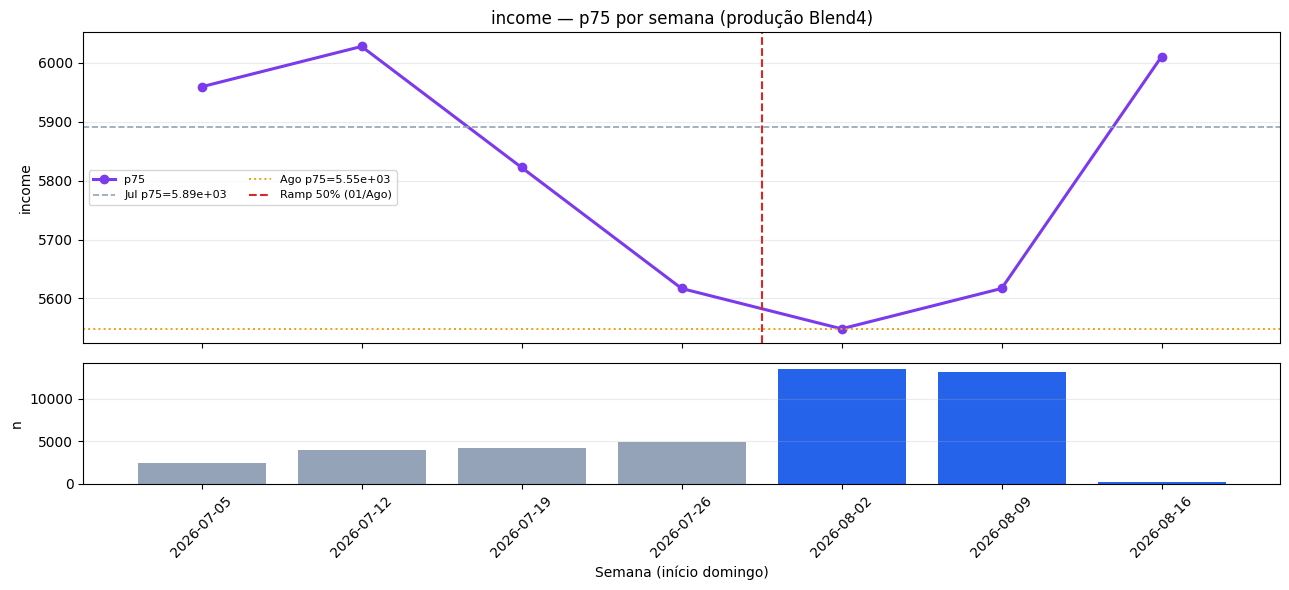

In [51]:
FOCUS_VAR = "income"

g = cmp_week[cmp_week["variable"] == FOCUS_VAR].copy()
g["period"] = g["period"].astype(str)
g = g.set_index("period").reindex(week_order).reset_index()
g["n"] = g["period"].map(lambda w: int(week_vol.get(w, 0)) if pd.notna(w) else 0)
g["phase"] = np.where(g["period"].astype(str) < "2026-08-02", "Jul (~15%)", "Ago (~50%)")

# Weekly table (progression)
display(
    g[["period", "phase", "n", "p50", "p75"]]
    .assign(
        p50=lambda d: d["p50"].round(4),
        p75=lambda d: d["p75"].round(4),
        delta_p50=lambda d: d["p50"].diff().round(4),
        delta_p75=lambda d: d["p75"].diff().round(4),
    )
    .rename(columns={"period": "year_week"})
)

jul_row = cmp_month[(cmp_month["variable"] == FOCUS_VAR) & (cmp_month["base"] == "Jul")].iloc[0]
ago_row = cmp_month[(cmp_month["variable"] == FOCUS_VAR) & (cmp_month["base"] == "Ago")].iloc[0]
print(
    f"{FOCUS_VAR}\n"
    f"  Jul: n={int(jul_row['n']):,} | p50={jul_row['p50']:.4f} | p75={jul_row['p75']:.4f}\n"
    f"  Ago: n={int(ago_row['n']):,} | p50={ago_row['p50']:.4f} | p75={ago_row['p75']:.4f}\n"
    f"  Δ (Ago−Jul): p50={ago_row['p50'] - jul_row['p50']:+.4f} | p75={ago_row['p75'] - jul_row['p75']:+.4f}"
)

# Separate charts: one for p50, one for p75
x = g["period"].astype(str).tolist()
bar_colors = ["#94A3B8" if p < "2026-08-02" else "#2563EB" for p in x]
ramp_idx = x.index("2026-08-02") - 0.5 if "2026-08-02" in x else None

for metric, color, jul_val, ago_val in [
    ("p50", "#2563EB", float(jul_row["p50"]), float(ago_row["p50"])),
    ("p75", "#7C3AED", float(jul_row["p75"]), float(ago_row["p75"])),
]:
    fig, axes = plt.subplots(
        2, 1, figsize=(13, 6.0), sharex=True, gridspec_kw={"height_ratios": [0.72, 0.28]}
    )
    ax, ax_vol = axes

    ax.plot(x, g[metric], color=color, marker="o", linewidth=2.2, label=metric)
    ax.axhline(jul_val, color="#94A3B8", linestyle="--", linewidth=1.2, label=f"Jul {metric}={jul_val:.3g}")
    ax.axhline(ago_val, color="#F59E0B", linestyle=":", linewidth=1.4, label=f"Ago {metric}={ago_val:.3g}")
    if ramp_idx is not None:
        ax.axvline(ramp_idx, color="#DC2626", linestyle="--", linewidth=1.5, label="Ramp 50% (01/Ago)")

    ax.set_title(f"{FOCUS_VAR} — {metric} por semana (produção Blend4)")
    ax.set_ylabel(FOCUS_VAR)
    ax.legend(loc="best", fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.25)

    ax_vol.bar(x, g["n"].fillna(0).astype(int), color=bar_colors)
    ax_vol.set_ylabel("n")
    ax_vol.set_xlabel("Semana (início domingo)")
    ax_vol.tick_params(axis="x", rotation=45)
    ax_vol.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()


,year_week,phase,n,p10,p20,p30,p40,p50,p60,p70,p80,p90
0,2026-07-05,Jul (~15%),2476,1507.0,1712.5,2055.0,2397.5,3082.5,4178.5,5069.0,7192.5,11713.50
1,2026-07-12,Jul (~15%),3997,1507.0,1712.5,2055.0,2466.0,3151.0,4178.5,5151.2,7261.0,12124.50
2,2026-07-19,Jul (~15%),4182,1507.0,1712.5,2055.0,2397.5,3151.0,4178.5,5000.5,6987.0,11638.15
3,2026-07-26,Jul (~15%),4886,1507.0,1712.5,1986.5,2329.0,3014.0,4041.5,4932.0,6850.0,11542.25
4,2026-08-02,Ago (~50%),13595,1507.0,1712.5,1986.5,2397.5,3014.0,4041.5,4918.3,6644.5,11097.00
5,2026-08-09,Ago (~50%),13139,1507.0,1712.5,2055.0,2466.0,3082.5,4110.0,4932.0,6713.0,11645.00
6,2026-08-16,Ago (~50%),142,1507.0,1726.2,1986.5,2603.0,3219.5,4288.1,5137.5,6630.8,10206.50


income
  Jul: n=15,445 | p10=1507.0000 | p20=1712.5000 | p30=2055.0000 | p40=2397.5000 | p50=3082.5000 | p60=4178.5000 | p70=5000.5000 | p80=7124.0000 | p90=11782.0000
  Ago: n=27,362 | p10=1507.0000 | p20=1712.5000 | p30=1986.5000 | p40=2397.5000 | p50=3014.0000 | p60=4082.6000 | p70=4932.0000 | p80=6644.5000 | p90=11371.0000
  Δ (Ago−Jul): p10=+0.0000 | p20=+0.0000 | p30=-68.5000 | p40=+0.0000 | p50=-68.5000 | p60=-95.9000 | p70=-68.5000 | p80=-479.5000 | p90=-411.0000


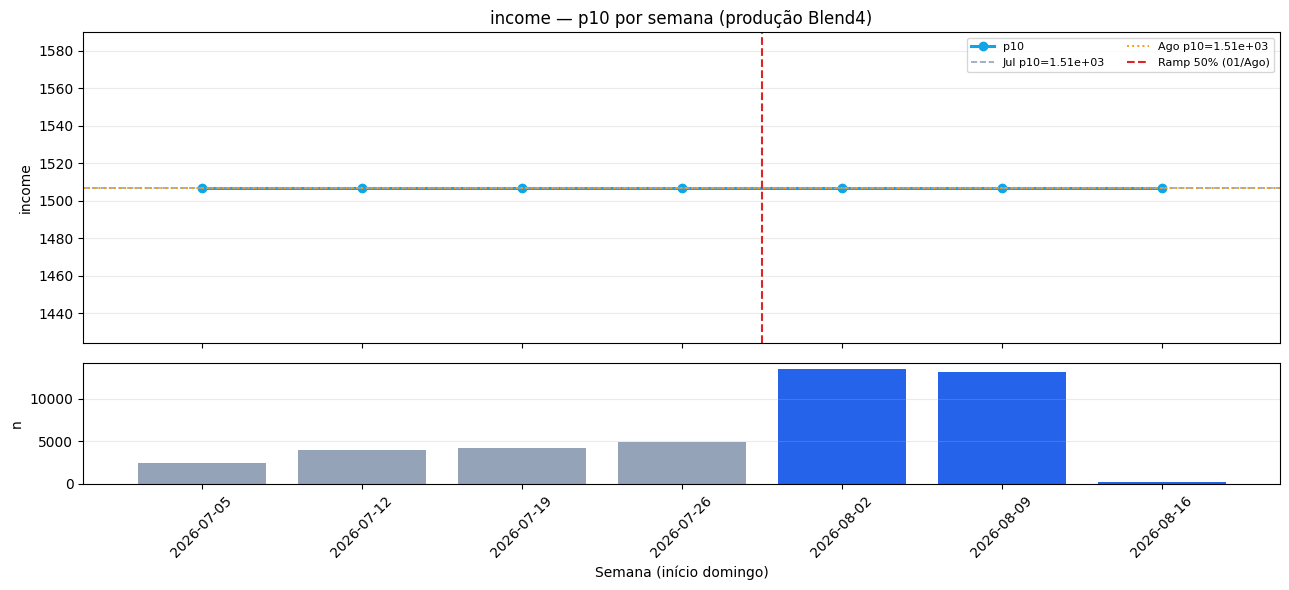

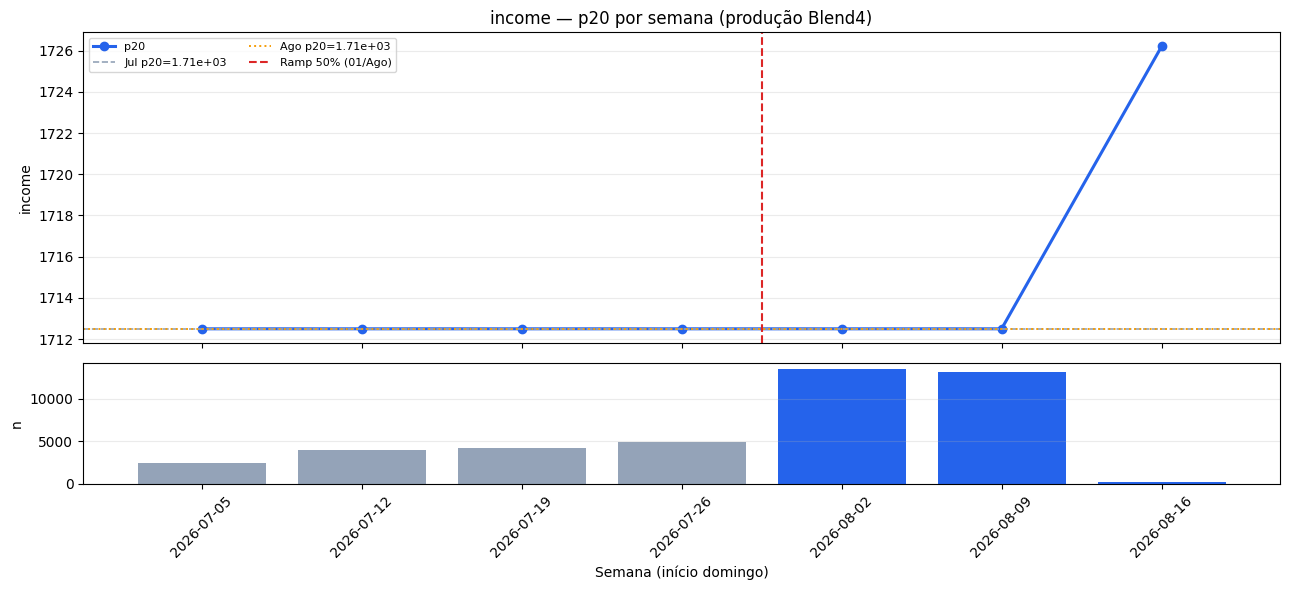

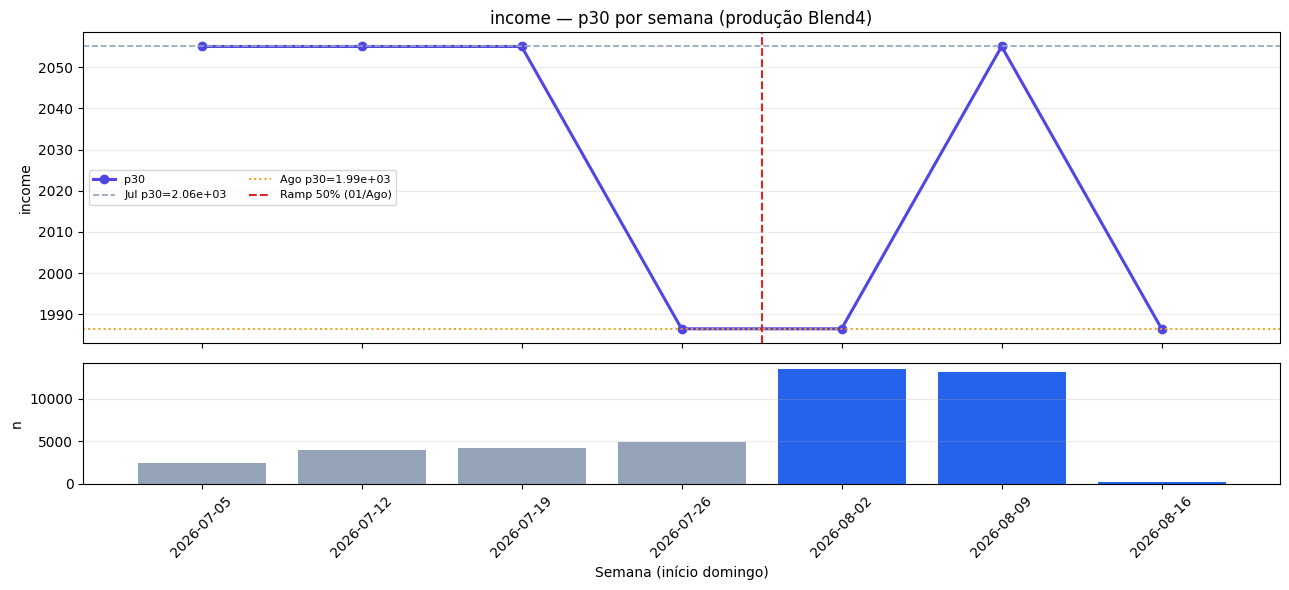

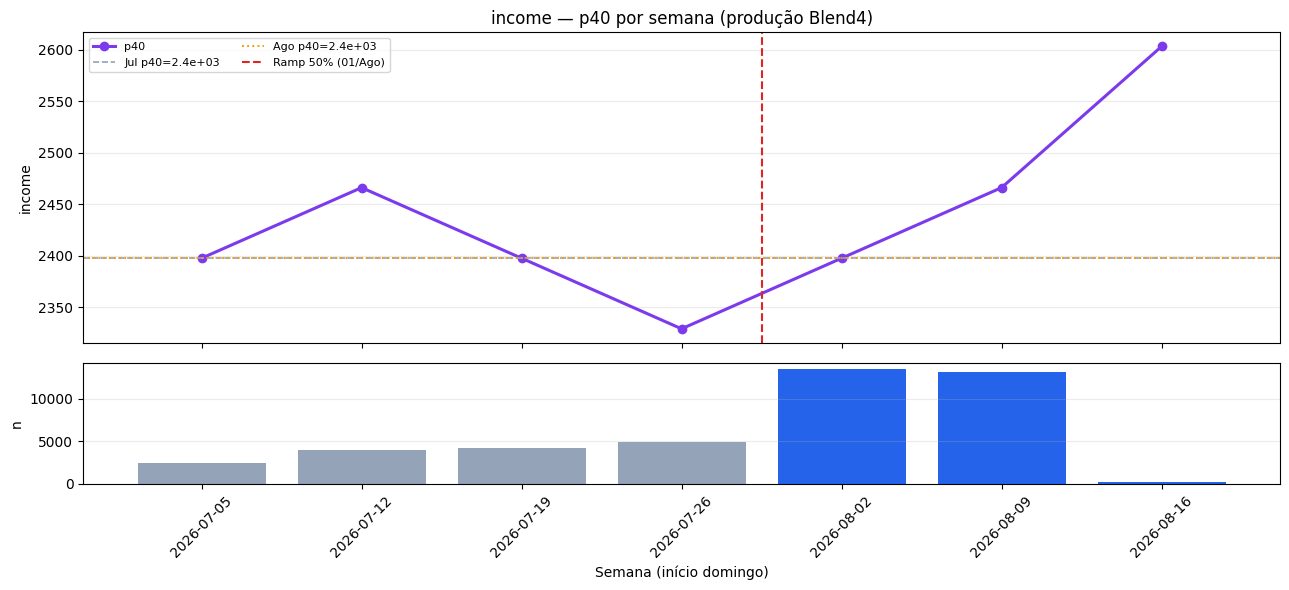

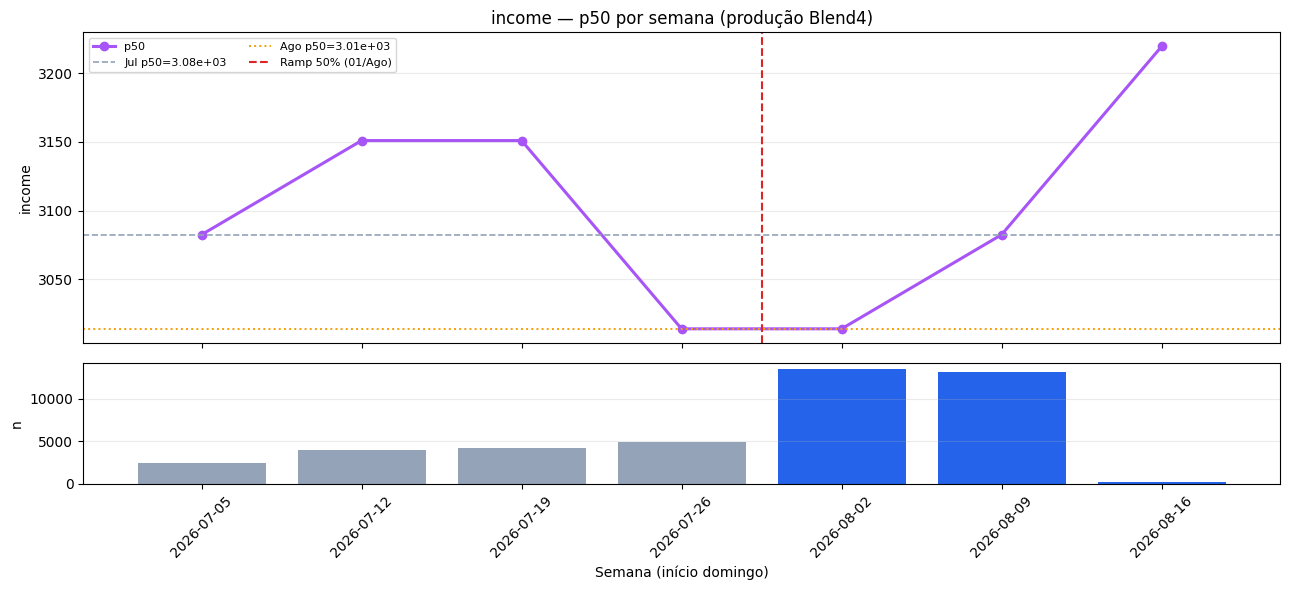

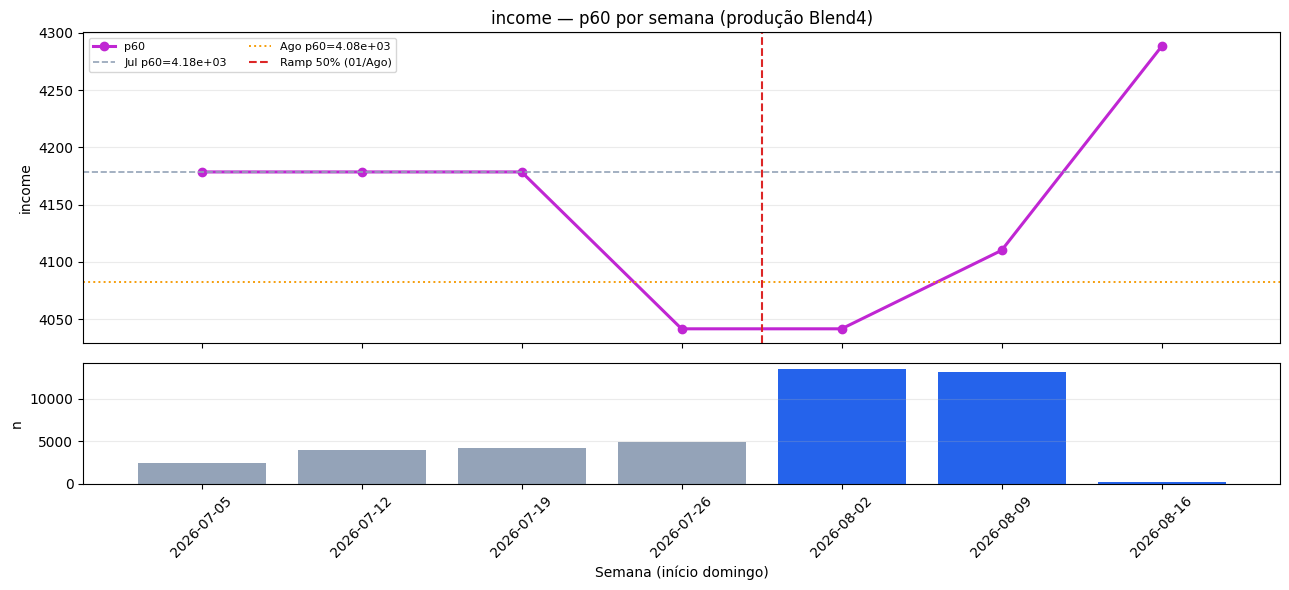

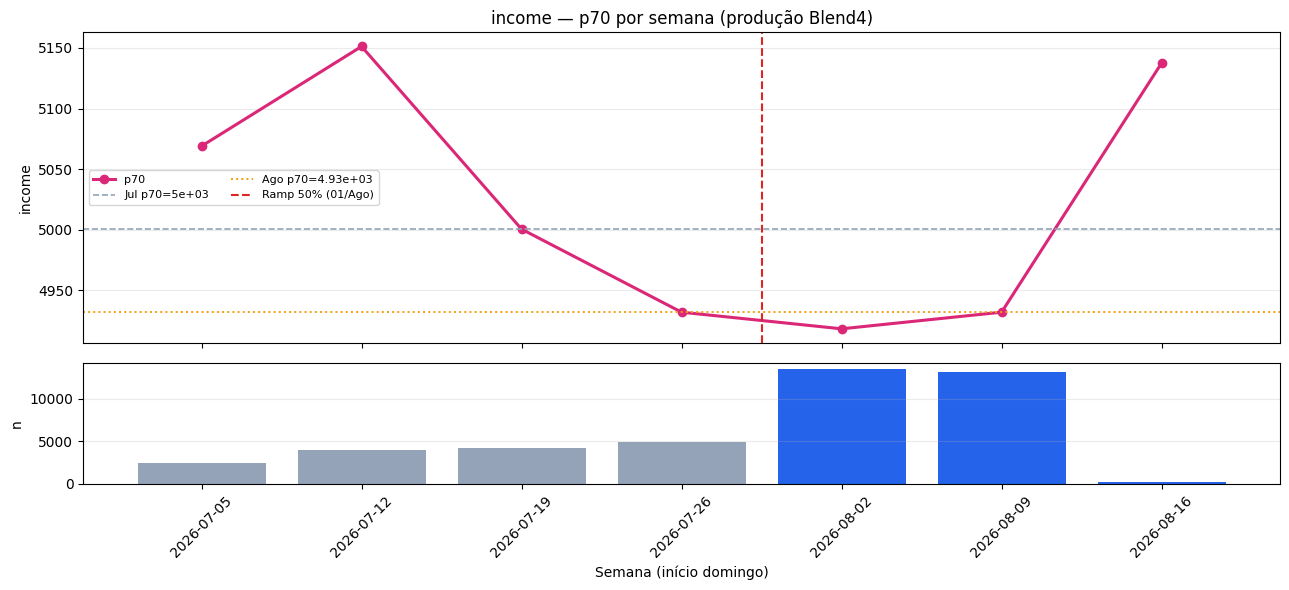

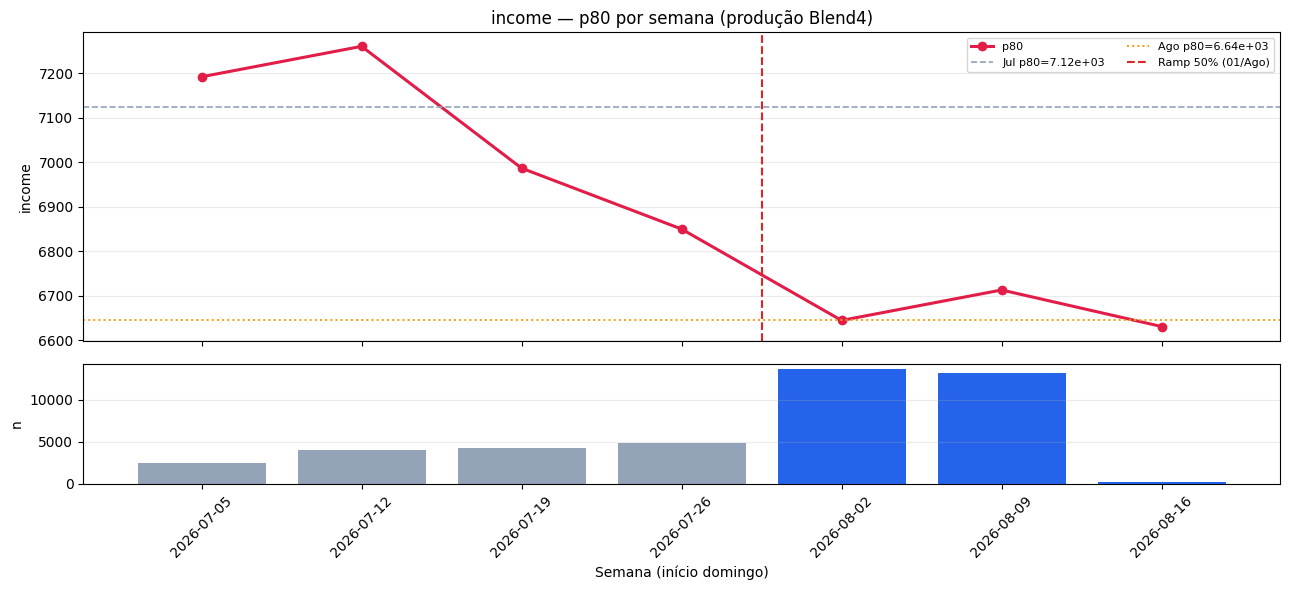

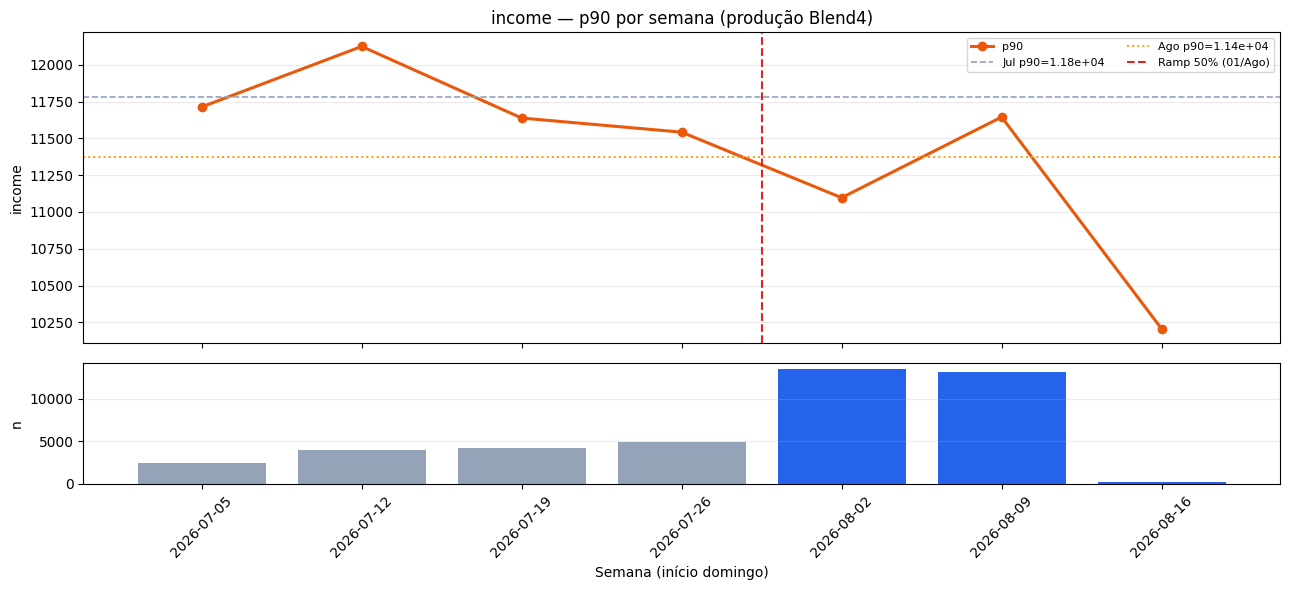

In [52]:
FOCUS_VAR = "income"
DECILES = [i / 10 for i in range(1, 10)]
DEC_COLS = [f"p{int(p * 100)}" for p in DECILES]
DEC_COLORS = [
    "#0EA5E9",
    "#2563EB",
    "#4F46E5",
    "#7C3AED",
    "#A855F7",
    "#C026D3",
    "#DB2777",
    "#E11D48",
    "#EA580C",
]


def _percentile_stats(s: pd.Series) -> dict:
    s = pd.to_numeric(s, errors="coerce")
    out = {"n": int(s.notna().sum())}
    for p, col in zip(DECILES, DEC_COLS):
        out[col] = float(s.quantile(p))
    return out


rows = []
for period, grp in df_ramp_ja.groupby("year_week", sort=True):
    rows.append({"period": period, **_percentile_stats(grp[FOCUS_VAR])})

g = pd.DataFrame(rows)
g["period"] = g["period"].astype(str)
g = g.set_index("period").reindex(week_order).reset_index()
g["n"] = g["period"].map(lambda w: int(week_vol.get(w, 0)) if pd.notna(w) else 0)
g["phase"] = np.where(g["period"].astype(str) < "2026-08-02", "Jul (~15%)", "Ago (~50%)")

table = g[["period", "phase", "n"] + DEC_COLS].copy()
for col in DEC_COLS:
    table[col] = table[col].round(4)
display(table.rename(columns={"period": "year_week"}))

jul_stats = _percentile_stats(df_jul[FOCUS_VAR])
ago_stats = _percentile_stats(df_ago[FOCUS_VAR])
print(
    f"{FOCUS_VAR}\n"
    f"  Jul: n={jul_stats['n']:,} | "
    + " | ".join(f"{c}={jul_stats[c]:.4f}" for c in DEC_COLS)
    + "\n"
    f"  Ago: n={ago_stats['n']:,} | "
    + " | ".join(f"{c}={ago_stats[c]:.4f}" for c in DEC_COLS)
    + "\n"
    "  Δ (Ago−Jul): "
    + " | ".join(f"{c}={ago_stats[c] - jul_stats[c]:+.4f}" for c in DEC_COLS)
)

x = g["period"].astype(str).tolist()
bar_colors = ["#94A3B8" if p < "2026-08-02" else "#2563EB" for p in x]
ramp_idx = x.index("2026-08-02") - 0.5 if "2026-08-02" in x else None

for metric, color in zip(DEC_COLS, DEC_COLORS):
    jul_val = jul_stats[metric]
    ago_val = ago_stats[metric]
    fig, axes = plt.subplots(
        2, 1, figsize=(13, 6.0), sharex=True, gridspec_kw={"height_ratios": [0.72, 0.28]}
    )
    ax, ax_vol = axes

    ax.plot(x, g[metric], color=color, marker="o", linewidth=2.2, label=metric)
    ax.axhline(jul_val, color="#94A3B8", linestyle="--", linewidth=1.2, label=f"Jul {metric}={jul_val:.3g}")
    ax.axhline(ago_val, color="#F59E0B", linestyle=":", linewidth=1.4, label=f"Ago {metric}={ago_val:.3g}")
    if ramp_idx is not None:
        ax.axvline(ramp_idx, color="#DC2626", linestyle="--", linewidth=1.5, label="Ramp 50% (01/Ago)")

    ax.set_title(f"{FOCUS_VAR} — {metric} por semana (produção Blend4)")
    ax.set_ylabel(FOCUS_VAR)
    ax.legend(loc="best", fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.25)

    ax_vol.bar(x, g["n"].fillna(0).astype(int), color=bar_colors)
    ax_vol.set_ylabel("n")
    ax_vol.set_xlabel("Semana (início domingo)")
    ax_vol.tick_params(axis="x", rotation=45)
    ax_vol.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()


### PSI — Agosto vs Julho (referência = Jul)


In [53]:
psi_ref_jul = build_psi_reference_artifact(df_jul, model_vars, n_bins=10, binary_vars=BINARY_MODEL_VARS,
    metadata={"reference":"production_blend4_2026-07","n_reference":len(df_jul),"note":RAMP_NOTE})
psi_ago_vs_jul = calculate_psi_table_from_reference(df_ago, psi_ref_jul, "ago_vs_jul", model_vars)
display(psi_ago_vs_jul)

psi_week_rows=[]
for yw in weeks_ago:
    g=df_ramp[df_ramp["year_week"]==yw]
    psi_w=calculate_psi_table_from_reference(g, psi_ref_jul, "week_vs_jul", model_vars)
    psi_w["year_week"]=yw; psi_w["n_week"]=len(g); psi_week_rows.append(psi_w)
psi_ago_weeks=pd.concat(psi_week_rows, ignore_index=True)
display(psi_ago_weeks.pivot(index="variable", columns="year_week", values="psi").reindex(psi_ago_vs_jul["variable"].tolist()))

plot_vars=psi_ago_vs_jul["variable"].tolist()
n_cols,n_rows=2,int(np.ceil(len(plot_vars)/2))
fig,axes=plt.subplots(n_rows,n_cols,figsize=(14,3.4*n_rows)); axes=np.array(axes).reshape(-1)
for i,var in enumerate(plot_vars):
    ax=axes[i]; g=psi_ago_weeks[psi_ago_weeks.variable==var].sort_values("year_week")
    ax.plot(g.year_week.astype(str), g.psi, marker="o", color="#2563EB")
    ax.axhline(float(psi_ago_vs_jul.loc[psi_ago_vs_jul.variable==var,"psi"].iloc[0]), color="#94A3B8", linestyle=":")
    ax.axhline(0.10, color="#22C55E", linestyle="--", linewidth=1); ax.axhline(0.25, color="#F59E0B", linestyle="--", linewidth=1)
    for _,r in g.iterrows(): ax.text(str(r.year_week), r.psi, f"n={int(r.n_week)}", fontsize=7, ha="center", va="bottom")
    ax.set_title(var, fontsize=10); ax.tick_params(axis="x", rotation=45, labelsize=8); ax.set_ylim(bottom=0); ax.grid(axis="y", alpha=0.25)
for j in range(i+1,len(axes)): axes[j].set_visible(False)
fig.suptitle("PSI semanas de Agosto vs referência Julho", y=1.01); plt.tight_layout(); plt.show()


,variable,comparison,psi,status,n_actual
0,city_pc4_mais_100_contratos__pc_categorias,ago_vs_jul,0.297090,unstable,27362
1,agency_pc4_mais_100_contratos__pc_categorias,ago_vs_jul,0.016871,stable,27362
2,pred_blend4_1_to_score,ago_vs_jul,0.006792,stable,27362
3,score_proposto__bvs,ago_vs_jul,0.003862,stable,27362
4,SERASA_CHSV5,ago_vs_jul,0.003525,stable,27362
5,qtde_restricoes__consulta_realizada,ago_vs_jul,0.003198,stable,27362
6,agency_pc4_mais_100_contratos__pc_categorias_i...,ago_vs_jul,0.002324,stable,27362
7,rental_value,ago_vs_jul,0.001840,stable,27362
8,income,ago_vs_jul,0.001707,stable,27362
9,city_pc4_mais_100_contratos__pc_categorias_is_...,ago_vs_jul,0.001145,stable,27362


year_week,2026-08-02,2026-08-09,2026-08-16
variable,,,
city_pc4_mais_100_contratos__pc_categorias,0.309208,0.313415,0.606831
agency_pc4_mais_100_contratos__pc_categorias,0.017889,0.015769,1.353102
pred_blend4_1_to_score,0.007675,0.007341,0.038313
score_proposto__bvs,0.004193,0.004423,0.072772
SERASA_CHSV5,0.004302,0.003324,0.037852
qtde_restricoes__consulta_realizada,0.002648,0.003769,0.005700
agency_pc4_mais_100_contratos__pc_categorias_is_null,0.001839,0.002580,0.512425
rental_value,0.002403,0.002294,0.063109
income,0.002360,0.002175,0.065778


### Score e Rating E — Jul vs Ago


In [ ]:
if "assign_rating_cl_pol_blend4" in globals():
    df_ramp[RATING_COL] = assign_rating_cl_pol_blend4(df_ramp)
df_jul = df_ramp[df_ramp["month"]=="2026-07"].copy()
df_ago = df_ramp[df_ramp["month"]=="2026-08"].copy()
df_ramp_ja = df_ramp[df_ramp["week_month"].isin(["2026-07","2026-08"])].copy()

def e_stats(df, label):
    s=df[RATING_COL]; score=pd.to_numeric(df["pred_blend4_1_to_score"], errors="coerce"); bvs=pd.to_numeric(df["score_proposto__bvs"], errors="coerce")
    return {"base":label,"n":len(df),"score_mean":round(score.mean(),2),"score_p50":round(score.median(),2),
            "pct_E_total":round(100*s.isin(E_RATINGS).mean(),2),"pct_E.E":round(100*(s=="E.E").mean(),2),
            "pct_E-1.E":round(100*(s=="E-1.E").mean(),2),"pct_E-2.E":round(100*(s=="E-2.E").mean(),2),
            "pct_bvs_le_334":round(100*(bvs<=334).mean(),2)}

summary_ramp=pd.DataFrame([e_stats(df_jul,"Jul/2026 (~15%)"), e_stats(df_ago,"Ago/2026 (~50%)")])
delta={"base":"delta_ago_minus_jul", **{c: round(summary_ramp.loc[1,c]-summary_ramp.loc[0,c],2) for c in summary_ramp.columns if c!="base"}}
summary_ramp=pd.concat([summary_ramp, pd.DataFrame([delta])], ignore_index=True)
display(summary_ramp)

e_week_rows=[]
for yw,g in df_ramp_ja.groupby("year_week", sort=True):
    st=e_stats(g,str(yw)); st["year_week"]=yw; st["week_start"]=g["week_start"].iloc[0]; st["week_month"]=g["week_month"].iloc[0]; e_week_rows.append(st)
e_week=pd.DataFrame(e_week_rows).sort_values("week_start"); display(e_week)

fig, axes = plt.subplots(2,1,figsize=(12,6.5), sharex=True, gridspec_kw={"height_ratios":[0.65,0.35]})
ax, ax_vol = axes
xlab=e_week["year_week"].astype(str).tolist()
ax.plot(xlab, e_week["pct_E_total"], marker="o", color="#DC2626", linewidth=2, label="E% total")
ax.plot(xlab, e_week["pct_E.E"], marker="x", linestyle=":", color="#7F1D1D", label="E.E%")
ax.plot(xlab, e_week["pct_E-1.E"]+e_week["pct_E-2.E"], marker="s", linestyle="--", color="#F97316", label="(E-1+E-2)%")
ax.axhline(summary_ramp.loc[0,"pct_E_total"], color="#94A3B8", linestyle="--", label=f"Jul E%={summary_ramp.loc[0,'pct_E_total']:.1f}")
ax.axhline(summary_ramp.loc[1,"pct_E_total"], color="#F59E0B", linestyle=":", label=f"Ago E%={summary_ramp.loc[1,'pct_E_total']:.1f}")
ax2=ax.twinx(); ax2.plot(xlab, e_week["score_p50"], marker="D", color="#2563EB", linewidth=1.5, label="score p50"); ax2.set_ylabel("score p50", color="#2563EB")
if "2026-08-02" in xlab: ax.axvline(xlab.index("2026-08-02")-0.5, color="#DC2626", linestyle="--")
h1,l1=ax.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax.legend(h1+h2,l1+l2, loc="best", fontsize=7, ncol=2); ax.set_ylabel("E %"); ax.set_title("E% e score p50 — Jul vs Ago"); ax.grid(axis="y", alpha=0.25)
ax_vol.bar(xlab, e_week["n"], color=np.where(e_week["week_month"].eq("2026-08"), "#2563EB", "#94A3B8"))
for _,row in e_week.iterrows(): ax_vol.text(str(row.year_week), row.n, f"{int(row.n):,}", ha="center", va="bottom", fontsize=7)
ax_vol.set_ylabel("n"); ax_vol.tick_params(axis="x", rotation=45); ax_vol.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

pct_w = (pd.crosstab(df_ramp_ja["year_week"].astype(str), df_ramp_ja[RATING_COL], normalize="index").mul(100)
         .reindex(index=week_order, columns=RATING_ORDER, fill_value=0))
vol_w = df_ramp_ja.groupby(df_ramp_ja["year_week"].astype(str)).size().reindex(week_order, fill_value=0)
plot_mix_and_volume(pct_w, vol_w, title="Mix rating por semana — Jul vs Ago", xlabel="Semana Sun→Sat",
                    category_order=RATING_ORDER, color_map=RATING_COLOR_MAP, text_color_map=RATING_TEXT_COLOR_MAP,
                    reverse_stack=True, legend_title="Rating", min_label_pct=4.0)
plt.show()


### Leitura crítica — Jul vs Ago (ramp 15% → 50%)

1. **Volume primeiro.** Jul tem menos Blend4. Semanas com n baixo distorcem p75/PSI/E%.
2. **Ramp em 01/Ago** muda o regime populacional; separar efeito de rollout vs drift de feature.
3. Se **E% alto e score p50 baixo persistem nas semanas cheias de ago**, o sinal é crível (não é ruído de Jul).
4. **PSI Ago vs Jul:** se baixo, o problema principal continua sendo vs desenvolvimento, não a troca 15%→50%.


## Relatório crítico

### Escopo
- Dev (`2024-09`→`2025-08`) vs prod Blend4 (`2026-06`→`2026-08`, `message_decisao == BLEND_4`).
- Sem overlap em `(contract_id, safra)` → só comparação populacional.
- Rating: política `rating_cl_pol_blend4` (BVS ≤ 334 → `E.E`; resto por faixas de score).

### Achado principal: rating E subiu
| | Dev | Prod Blend4 | Δ (pp) |
|---|---:|---:|---:|
| **E total** (`E-1+E-2+E.E`) | **~32%** | **~40%** | **~+8** |
| Principal motor | — | **E-1+E-2 (score baixo)** | > override BVS (`E.E`) |

Score p50 **442 → ~397**. Na política isso engorda a cauda E.

### Jul vs Ago (ramp 15% → 50%)
- Em **01/08/2026** o share Blend4 sobe; volume de ago é bem maior.
- Jul é baseline interno com **mais erro amostral**. Decisões: semanas cheias de ago + tendência pós-ramp.
- Se E%/score ruins **permanecem com n alto em ago**, não é artefato de Jul.

### Features / equação
1. **`city_pc4` PSI ≈ 2,0 (unstable)** — P0; peso **+0,14** no logit.
2. **`income` / `income_commitment`** drift + outliers — empurram PD para cima (**+0,093**).
3. BVS/Serasa estáveis e dominam o modelo (−0,57 / −0,60) — amortecem, não explicam o salto de E.
4. Sem sazonalidade semanal forte: problema de **nível**.

### Prioridades
1. Auditar pipeline `city_pc4`.
2. Monitorar semanalmente `%E`, `%E-1+%E-2`, `%E.E`, **p50 do score** (com volume).
3. Tratar outliers de renda/aluguel.
4. Separar E.E (BVS) vs E por score no acompanhamento do ramp.


## Análises Blend3

Mesmo recorte das análises Blend4, agora para produção `message_decisao.isin(["BLEND3_3", "BLEND3_4"])`.

- `model_vars_blend3` = `model_vars` **sem** `score_proposto__bvs` e `SERASA_CHSV5` (na produção esses nomes são os scores de bureau do Blend4, sem histórico comparável na referência).
- Score Blend3 = `predict_blend3_2_to_score` (dev) / `message_scores_BLEND3_3` ou `message_scores_BLEND3_4` (prod, conforme a decisão).
- Referência de desenvolvimento: `df_raw_dev` (mesma base Blend4, features compartilhadas).


### B3.1. Cobertura e unicidade das chaves


In [ ]:
print("model_vars_blend3:", model_vars_blend3)
print("Excluded from Blend3 analysis:", BLEND3_EXCLUDE_VARS)
display(pd.DataFrame([
    key_coverage_summary(df_dev_blend3, "development_blend3"),
    key_coverage_summary(df_prod_blend3, "production_blend3"),
]))
vol_dev_b3 = df_dev_blend3.groupby("safra", as_index=False).size().rename(columns={"size": "n_dev"})
vol_prod_b3 = df_prod_blend3.groupby("safra", as_index=False).size().rename(columns={"size": "n_prod_blend3"})
vol_safra_b3 = vol_dev_b3.merge(vol_prod_b3, on="safra", how="outer").sort_values("safra").fillna(0)
for col in ["n_dev", "n_prod_blend3"]:
    vol_safra_b3[col] = vol_safra_b3[col].astype(int)
display(vol_safra_b3)
print("message_decisao mix (production Blend3):")
display(
    df_blend4_dev.loc[df_blend4_dev["message_decisao"].isin(["BLEND3_3", "BLEND3_4"]), "message_decisao"]
    .value_counts(dropna=False).rename("n").to_frame()
)


### B3.2. Match lead a lead (desenvolvimento × produção Blend3)


In [ ]:
df_cmp_b3 = df_dev_blend3.merge(df_prod_blend3, on=KEY_COLS, how="outer", suffixes=("_dev", "_prod"), indicator=True)
match_summary_b3 = df_cmp_b3["_merge"].value_counts(dropna=False).rename_axis("match_status").reset_index(name="n_leads")
match_summary_b3["pct"] = (100 * match_summary_b3["n_leads"] / match_summary_b3["n_leads"].sum()).round(2)
print(f"Matched leads Blend3 (both): {int((df_cmp_b3['_merge']=='both').sum()):,} of {len(df_cmp_b3):,}")
display(match_summary_b3)
df_matched_b3 = df_cmp_b3[df_cmp_b3["_merge"] == "both"].copy()
if len(df_matched_b3) == 0:
    print("No overlapping leads on (contract_id, safra). Continue with population comparison.")
    match_var_summary_b3 = pd.DataFrame()
else:
    match_var_summary_b3 = compare_matched_variables(df_matched_b3, model_vars_blend3)
    display(match_var_summary_b3)
match_var_summary_b3


### B3.3. Comparação populacional das `model_vars_blend3`


In [ ]:
profile_long_b3 = pd.concat([
    variable_profile(df_dev_blend3, model_vars_blend3, "development"),
    variable_profile(df_prod_blend3, model_vars_blend3, "production_blend3"),
], ignore_index=True)
profile_wide_b3 = profile_long_b3.pivot(index="variable", columns="base")
cols_focus_b3 = [
    ("pct_null", "development"), ("pct_null", "production_blend3"),
    ("mean", "development"), ("mean", "production_blend3"),
    ("p50", "development"), ("p50", "production_blend3"),
    ("p95", "development"), ("p95", "production_blend3"),
]
profile_focus_b3 = profile_wide_b3.loc[:, cols_focus_b3].copy()
profile_focus_b3[("mean", "diff_prod_minus_dev")] = profile_focus_b3[("mean", "production_blend3")] - profile_focus_b3[("mean", "development")]
profile_focus_b3[("p50", "diff_prod_minus_dev")] = profile_focus_b3[("p50", "production_blend3")] - profile_focus_b3[("p50", "development")]
profile_focus_b3


#### Percentis ao longo das safras (p50 e p75) — Blend3


In [ ]:
pct_by_safra_b3 = pd.concat([
    percentiles_by_safra(df_dev_blend3, model_vars_blend3, "development"),
    percentiles_by_safra(df_prod_blend3, model_vars_blend3, "production_blend3"),
], ignore_index=True)
COLORS_B3 = {"development": "#94A3B8", "production_blend3": "#7C3AED"}
for var in model_vars_blend3:
    g = pct_by_safra_b3[pct_by_safra_b3["variable"] == var].copy()
    if g.empty:
        continue
    fig, ax = plt.subplots(figsize=(12, 4.5))
    for base, color in COLORS_B3.items():
        gb = g[g["base"] == base].sort_values("safra")
        if gb.empty:
            continue
        ax.plot(gb["safra"], gb["p50"], marker="o", linewidth=2, color=color, label=f"{base} — p50")
        ax.plot(gb["safra"], gb["p75"], marker="s", linewidth=1.5, linestyle="--", color=color, alpha=0.85, label=f"{base} — p75")
    ax.set_title(f"{var} — p50 e p75 por safra (dev vs prod Blend3)")
    ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=0.25); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


#### Visão semanal Blend3 — S1–S4 e temporal (domingo→sábado)


In [ ]:
df_dev_week_b3 = df_raw_dev[["contract_id", "requested_at", "safra"] + model_vars_blend3].copy()
df_dev_week_b3 = prepare_week_columns(df_dev_week_b3, date_col="requested_at")
df_dev_week_b3 = _add_week_of_month(df_dev_week_b3, "requested_at")
df_prod_week_b3 = df_blend4_dev.loc[
    df_blend4_dev["message_decisao"].isin(["BLEND3_3", "BLEND3_4"]),
    ["contract_id", "requested_at", "safra"] + model_vars_blend3,
].copy()
df_prod_week_b3 = prepare_week_columns(df_prod_week_b3, date_col="requested_at")
df_prod_week_b3 = _add_week_of_month(df_prod_week_b3, "requested_at")
dev_by_s_b3 = weekly_metric_table(df_dev_week_b3, model_vars_blend3, "week_label", "development")
prod_by_s_b3 = weekly_metric_table(df_prod_week_b3, model_vars_blend3, "week_label", "production_blend3")
prod_by_week_b3 = weekly_metric_table(df_prod_week_b3, model_vars_blend3, "year_week", "production_blend3")
week_meta_b3 = df_prod_week_b3.groupby("year_week", as_index=False).agg(
    week_start=("week_start", "first"), week_end=("week_end", "first"),
    week_label=("week_label", "first"), week_month=("week_month", "first"),
    week_label_full=("week_label_full", "first"), n_rows=("year_week", "size"),
)
prod_by_week_b3 = prod_by_week_b3.merge(week_meta_b3.rename(columns={"year_week": "period"}), on="period", how="left")
seasonality_cmp_b3 = pd.concat([dev_by_s_b3, prod_by_s_b3], ignore_index=True)
S_ORDER = ["S1", "S2", "S3", "S4"]
METRIC_STYLE = {"p50": {"linestyle": "-", "marker": "o", "alpha": 1.0}, "p75": {"linestyle": "--", "marker": "s", "alpha": 0.9}}
for var in model_vars_blend3:
    g = seasonality_cmp_b3[seasonality_cmp_b3["variable"] == var].copy()
    if g.empty:
        continue
    fig, ax = plt.subplots(figsize=(12, 4.5))
    for base, color in [("development", "#94A3B8"), ("production_blend3", "#7C3AED")]:
        gb = g[g["base"] == base].set_index("period").reindex(S_ORDER)
        for metric, style in METRIC_STYLE.items():
            ax.plot(S_ORDER, gb[metric], color=color, linewidth=2 if metric == "p50" else 1.5, label=f"{base} — {metric}", **style)
    ax.set_title(f"{var} — p50 / p75 por semana do mês (S1–S4) — Blend3")
    ax.grid(axis="y", alpha=0.25); ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()
dev_overall_b3 = pd.DataFrame([
    {"variable": var, "p50": pd.to_numeric(df_dev_week_b3[var], errors="coerce").quantile(0.50),
     "p75": pd.to_numeric(df_dev_week_b3[var], errors="coerce").quantile(0.75)}
    for var in model_vars_blend3
]).set_index("variable")
for var in model_vars_blend3:
    g = prod_by_week_b3[prod_by_week_b3["variable"] == var].sort_values("week_start").copy()
    if g.empty:
        continue
    ref = g[["period", "week_label", "week_label_full", "week_month"]].copy()
    ref["variable"] = var
    ref = ref.merge(dev_by_s_b3.rename(columns={"period": "week_label"}), on=["variable", "week_label"], how="left")
    x = g["period"].astype(str).tolist()
    fig, ax = plt.subplots(figsize=(13, 5))
    for metric, style in METRIC_STYLE.items():
        ax.plot(x, g[metric], color="#7C3AED", linewidth=2 if metric == "p50" else 1.5, label=f"prod — {metric}", **style)
        ax.plot(x, ref[metric], color="#94A3B8", linewidth=2 if metric == "p50" else 1.5, label=f"dev S ref — {metric}", **{**style, "marker": None})
    ax.axhline(float(dev_overall_b3.loc[var, "p50"]), color="#CBD5E1", linestyle="-.", linewidth=1.5)
    ax.set_title(f"{var} — temporal semanal Blend3 vs ref S do desenvolvimento")
    ax.tick_params(axis="x", rotation=45, labelsize=8); ax.grid(axis="y", alpha=0.25); ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()


### B3.4. PSI — desenvolvimento × produção Blend3


In [ ]:
psi_reference_b3 = build_psi_reference_artifact(
    df_reference=df_dev_blend3, variables=model_vars_blend3, n_bins=10, binary_vars=BINARY_MODEL_VARS,
    metadata={"model": "blend3_2", "reference": "df_raw_dev", "score_col": SCORE_COL_BLEND3,
              "excluded_vars": BLEND3_EXCLUDE_VARS},
)
psi_prod_blend3 = calculate_psi_table_from_reference(
    df_actual=df_prod_blend3, artifact=psi_reference_b3,
    comparison_label="production_blend3_vs_development", variables=model_vars_blend3,
)
psi_comparison_b3 = (
    psi_prod_blend3[["variable", "psi", "status", "n_actual"]]
    .rename(columns={"psi": "psi_prod_blend3", "status": "status_prod_blend3", "n_actual": "n_prod_blend3"})
    .sort_values("psi_prod_blend3", ascending=False).reset_index(drop=True)
)
display(psi_comparison_b3)
top_psi_vars_b3 = psi_comparison_b3.dropna(subset=["psi_prod_blend3"]).head(5)["variable"].tolist()
if top_psi_vars_b3:
    plot_top_psi_distributions(
        df_actual=df_prod_blend3, artifact=psi_reference_b3, variables=model_vars_blend3,
        top_n=min(5, len(top_psi_vars_b3)), title_prefix="Prod Blend3 vs Dev",
    )
PSI_STABLE, PSI_MODERATE = 0.10, 0.25
psi_by_safra_b3 = pd.concat([
    calculate_psi_table_from_reference(g, psi_reference_b3, "production_blend3_vs_development", model_vars_blend3)
    .assign(safra=safra, n_rows=len(g))
    for safra, g in df_prod_blend3.groupby("safra", sort=True)
], ignore_index=True)
psi_safra_pivot_b3 = psi_by_safra_b3.pivot(index="variable", columns="safra", values="psi")
display(psi_safra_pivot_b3)
plot_vars = psi_comparison_b3["variable"].tolist()
n_cols, n_rows = 2, int(np.ceil(len(plot_vars) / 2)) or 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows)); axes = np.array(axes).reshape(-1)
for i, var in enumerate(plot_vars):
    ax = axes[i]; g = psi_by_safra_b3[psi_by_safra_b3["variable"] == var].sort_values("safra")
    ax.plot(g["safra"], g["psi"], marker="o", linewidth=2, color="#7C3AED")
    ax.axhline(PSI_STABLE, color="#22C55E", linestyle="--", linewidth=1)
    ax.axhline(PSI_MODERATE, color="#F59E0B", linestyle="--", linewidth=1)
    ax.set_title(var, fontsize=10); ax.set_ylim(bottom=0); ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("PSI por safra — production Blend3 vs development", y=1.01)
plt.tight_layout(); plt.show()


#### PSI por semana e sazonalidade S1–S4 — Blend3


In [ ]:
df_prod_blend3_week = df_blend4_dev.loc[
    df_blend4_dev["message_decisao"].isin(["BLEND3_3", "BLEND3_4"]),
    ["contract_id", "requested_at", "safra"] + model_vars_blend3,
].copy()
df_prod_blend3_week = prepare_week_columns(df_prod_blend3_week, date_col="requested_at")
df_prod_blend3_week["week_end"] = df_prod_blend3_week["week_start"] + pd.Timedelta(days=6)
df_prod_blend3_week = _add_week_of_month(df_prod_blend3_week, "requested_at")
psi_by_week_b3 = monitor_weekly_psi(
    df_production=df_prod_blend3_week, artifact=psi_reference_b3, week_col="year_week", variables=model_vars_blend3,
)
week_meta_psi_b3 = df_prod_blend3_week.groupby("year_week", as_index=False).agg(
    week_start=("week_start", "first"), week_end=("week_end", "first"), n_rows=("year_week", "size"),
)
psi_by_week_b3 = psi_by_week_b3.rename(columns={"monitoring_week": "year_week"}).merge(week_meta_psi_b3, on="year_week", how="left")
psi_week_pivot_b3 = psi_by_week_b3.pivot(index="variable", columns="year_week", values="psi")
display(psi_week_pivot_b3)
plot_vars = psi_comparison_b3["variable"].tolist()
n_cols, n_rows = 2, int(np.ceil(len(plot_vars) / 2)) or 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows)); axes = np.array(axes).reshape(-1)
for i, var in enumerate(plot_vars):
    ax = axes[i]; g = psi_by_week_b3[psi_by_week_b3["variable"] == var].sort_values("week_start")
    ax.plot(g["year_week"].astype(str), g["psi"], marker="o", linewidth=2, color="#7C3AED")
    ax.axhline(0.10, color="#22C55E", linestyle="--", linewidth=1)
    ax.axhline(0.25, color="#F59E0B", linestyle="--", linewidth=1)
    ax.set_title(var, fontsize=10); ax.tick_params(axis="x", rotation=60, labelsize=7); ax.set_ylim(bottom=0); ax.grid(axis="y", alpha=0.25)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("PSI por semana — production Blend3 vs development", y=1.01)
plt.tight_layout(); plt.show()
psi_by_week_of_month_b3 = pd.concat([
    calculate_psi_table_from_reference(g, psi_reference_b3, "production_blend3_vs_development", model_vars_blend3)
    .assign(week_of_month=int(wom), n_rows=len(g))
    for wom, g in df_prod_blend3_week.groupby("week_of_month", sort=True)
], ignore_index=True)
display(psi_by_week_of_month_b3.pivot(index="variable", columns="week_of_month", values="psi"))


### B3.5–B3.9. Score, percentis, flags, correlação e resumo — Blend3


In [ ]:
score_profile_b3 = pd.concat([
    variable_profile(df_dev_blend3, [SCORE_COL_BLEND3], "development"),
    variable_profile(df_prod_blend3, [SCORE_COL_BLEND3], "production_blend3"),
], ignore_index=True)
display(score_profile_b3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for data, label, color in [
    (df_dev_blend3[SCORE_COL_BLEND3], "Development", "#94A3B8"),
    (df_prod_blend3[SCORE_COL_BLEND3], "Production Blend3", "#7C3AED"),
]:
    axes[0].hist(pd.to_numeric(data, errors="coerce").dropna(), bins=40, alpha=0.55, density=True, label=label, color=color)
axes[0].set_title(SCORE_COL_BLEND3); axes[0].legend(); axes[0].grid(axis="y", alpha=0.25)
for df_src, label, color in [(df_dev_blend3, "development", "#94A3B8"), (df_prod_blend3, "production_blend3", "#7C3AED")]:
    s = pd.to_numeric(df_src[SCORE_COL_BLEND3], errors="coerce")
    g = df_src.assign(_s=s).groupby("safra", as_index=False).agg(p50=("_s", "median"), p75=("_s", lambda x: x.quantile(0.75)))
    axes[1].plot(g["safra"], g["p50"], marker="o", color=color, label=f"{label} p50")
    axes[1].plot(g["safra"], g["p75"], marker="s", linestyle="--", color=color, label=f"{label} p75")
axes[1].tick_params(axis="x", rotation=45); axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

binary_vars_b3 = [v for v in model_vars_blend3 if v in BINARY_MODEL_VARS]
binary_rows_b3 = []
for var in binary_vars_b3:
    for df_src, label in [(df_dev_blend3, "development"), (df_prod_blend3, "production_blend3")]:
        s = pd.to_numeric(df_src[var], errors="coerce")
        binary_rows_b3.append({"variable": var, "base": label, "pct_1": round(100 * (s == 1).mean(), 4), "pct_null": round(100 * s.isna().mean(), 4)})
display(pd.DataFrame(binary_rows_b3).pivot(index="variable", columns="base", values=["pct_1", "pct_null"]))

feature_vars_b3 = [v for v in model_vars_blend3 if v != SCORE_COL_BLEND3]
def corr_with_score_b3(df):
    work = df[feature_vars_b3 + [SCORE_COL_BLEND3]].apply(pd.to_numeric, errors="coerce")
    return work.corr(numeric_only=True)[SCORE_COL_BLEND3].drop(labels=[SCORE_COL_BLEND3]).rename("corr")
corr_cmp_b3 = corr_with_score_b3(df_dev_blend3).to_frame("corr_dev").join(corr_with_score_b3(df_prod_blend3).to_frame("corr_prod_blend3"), how="outer")
corr_cmp_b3["corr_diff"] = corr_cmp_b3["corr_prod_blend3"] - corr_cmp_b3["corr_dev"]
display(corr_cmp_b3.sort_values("corr_diff", key=lambda s: s.abs(), ascending=False))

summary_b3 = {
    "n_dev_blend3": len(df_dev_blend3), "n_prod_blend3": len(df_prod_blend3),
    "score_p50_dev": round(pd.to_numeric(df_dev_blend3[SCORE_COL_BLEND3], errors="coerce").median(), 2),
    "score_p50_prod_blend3": round(pd.to_numeric(df_prod_blend3[SCORE_COL_BLEND3], errors="coerce").median(), 2),
    "top_psi_variable": psi_comparison_b3.iloc[0]["variable"] if len(psi_comparison_b3) else None,
    "top_psi_prod_blend3": psi_comparison_b3.iloc[0]["psi_prod_blend3"] if len(psi_comparison_b3) else None,
    "unstable_vars": psi_comparison_b3.loc[psi_comparison_b3["status_prod_blend3"]=="unstable", "variable"].tolist(),
}
display(pd.Series(summary_b3, name="value").to_frame())


## KS Modelo — Blend3


In [ ]:
df_ks_b3 = df_raw_dev[[SCORE_COL_BLEND3, TARGET_COL, "safra", STATUS_COL]].copy()
ks_overall_b3 = calculate_ks(df_ks_b3[TARGET_COL], df_ks_b3[SCORE_COL_BLEND3])
display(pd.Series(ks_overall_b3, name="overall_blend3").to_frame())
ks_by_safra_b3 = pd.DataFrame([
    {**calculate_ks(g[TARGET_COL], g[SCORE_COL_BLEND3]), "safra": safra}
    for safra, g in df_ks_b3.groupby("safra", sort=True)
])
display(ks_by_safra_b3)
plot_ks_b3 = ks_by_safra_b3.copy()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [0.65, 0.35]})
axes[0].plot(plot_ks_b3["safra"], plot_ks_b3["ks"], marker="o", color="#7C3AED")
axes[0].axhline(ks_overall_b3["ks"], color="#94A3B8", linestyle="--", label=f"KS overall={ks_overall_b3['ks']:.2f}%")
axes[0].set_title(f"KS Blend3 | {SCORE_COL_BLEND3}"); axes[0].legend(); axes[0].grid(axis="y", alpha=0.25)
axes[1].bar(plot_ks_b3["safra"], plot_ks_b3["n"], color="#94A3B8")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
ks_by_status_b3 = pd.DataFrame([
    {**calculate_ks(g[TARGET_COL], g[SCORE_COL_BLEND3]), STATUS_COL: status}
    for status, g in df_ks_b3.groupby(STATUS_COL, dropna=False, sort=True)
])
display(ks_by_status_b3)
curve_b3 = ks_curve_frame(df_ks_b3[TARGET_COL], df_ks_b3[SCORE_COL_BLEND3])
if not curve_b3.empty:
    step = max(len(curve_b3) // 2000, 1)
    curve_plot = curve_b3.iloc[::step]
    idx_max = int(curve_b3["ks"].idxmax())
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(curve_plot["pct_pop"] * 100, curve_plot["cum_bad"] * 100, color="#EF4444", label="Cum. bads")
    ax.plot(curve_plot["pct_pop"] * 100, curve_plot["cum_good"] * 100, color="#22C55E", label="Cum. goods")
    ax.plot(curve_plot["pct_pop"] * 100, curve_plot["ks"] * 100, color="#7C3AED", label="KS")
    ax.scatter([curve_b3.loc[idx_max, "pct_pop"] * 100], [curve_b3.loc[idx_max, "ks"] * 100], color="#5B21B6", zorder=5)
    ax.set_title(f"Curva KS Blend3 | {SCORE_COL_BLEND3}"); ax.legend(); ax.grid(alpha=0.25)
    plt.tight_layout(); plt.show()


## Distribuição de Rating Blend3 (`A`–`E`)


In [ ]:
RATING_COL_B3 = "rating_blend3"
RATING_ORDER_B3 = ["A", "B", "C", "D", "E"]
E_RATINGS_B3 = ["E"]
RATING_COLOR_MAP_B3 = {"A": "#22D3EE", "B": "#6EE7B7", "C": "#FDE68A", "D": "#FB923C", "E": "#1E293B"}
RATING_TEXT_COLOR_MAP_B3 = {"A": "black", "B": "black", "C": "black", "D": "black", "E": "white"}

def rating_mix_table_b3(df, period_col):
    work = df.dropna(subset=[RATING_COL_B3, period_col]).copy()
    period_order = sorted(work[period_col].astype(str).unique())
    pct = (pd.crosstab(work[period_col].astype(str), work[RATING_COL_B3], normalize="index").mul(100)
           .reindex(index=period_order).reindex(columns=RATING_ORDER_B3, fill_value=0))
    vol = work.groupby(work[period_col].astype(str)).size().reindex(period_order, fill_value=0)
    return pct, vol

_r3 = df_blend4_dev["message_ratings_BLEND3_3"].astype(str).replace({"nan": np.nan, "None": np.nan})
_r4 = df_blend4_dev["message_ratings_BLEND3_4"].astype(str).replace({"nan": np.nan, "None": np.nan})
df_blend4_dev[RATING_COL_B3] = np.where(df_blend4_dev["message_decisao"].eq("BLEND3_4"), _r4.where(_r4.notna(), _r3), _r3.where(_r3.notna(), _r4))
df_rating_dev_b3 = df_raw_dev[["contract_id", "requested_at", "safra", "rating_blend3_3_atual"]].copy()
df_rating_dev_b3[RATING_COL_B3] = df_rating_dev_b3["rating_blend3_3_atual"]
df_rating_dev_b3 = prepare_week_columns(df_rating_dev_b3, date_col="requested_at")
df_rating_prod_b3 = df_blend4_dev.loc[
    df_blend4_dev["message_decisao"].isin(["BLEND3_3", "BLEND3_4"]),
    ["contract_id", "requested_at", "safra", RATING_COL_B3],
].copy()
df_rating_prod_b3 = prepare_week_columns(df_rating_prod_b3, date_col="requested_at")
for label, d in [("development", df_rating_dev_b3), ("production_blend3", df_rating_prod_b3)]:
    s = d[RATING_COL_B3].dropna()
    print(f"{label}: n={len(s):,} | E%={100 * s.isin(E_RATINGS_B3).mean():.2f}")
    display(s.value_counts(dropna=False).rename("n").to_frame())
pct_dev, vol_dev = rating_mix_table_b3(df_rating_dev_b3, "safra")
pct_prod, vol_prod = rating_mix_table_b3(df_rating_prod_b3, "safra")
plot_mix_and_volume(pct_dev, vol_dev, title="Mix rating — Desenvolvimento Blend3 (safra)", xlabel="Safra",
                    category_order=RATING_ORDER_B3, color_map=RATING_COLOR_MAP_B3, text_color_map=RATING_TEXT_COLOR_MAP_B3,
                    reverse_stack=True, legend_title="Rating", min_label_pct=4.0)
plt.show()
plot_mix_and_volume(pct_prod, vol_prod, title="Mix rating — Produção Blend3 (safra)", xlabel="Safra",
                    category_order=RATING_ORDER_B3, color_map=RATING_COLOR_MAP_B3, text_color_map=RATING_TEXT_COLOR_MAP_B3,
                    reverse_stack=True, legend_title="Rating", min_label_pct=4.0)
plt.show()
week_order_prod_b3 = df_rating_prod_b3[["year_week", "week_start"]].drop_duplicates().sort_values("week_start")["year_week"].tolist()
pct_w, vol_w = rating_mix_table_b3(df_rating_prod_b3, "year_week")
plot_mix_and_volume(pct_w.reindex(week_order_prod_b3), vol_w.reindex(week_order_prod_b3, fill_value=0),
                    title="Mix rating — Produção Blend3 (semana Sun→Sat)", xlabel="Semana",
                    category_order=RATING_ORDER_B3, color_map=RATING_COLOR_MAP_B3, text_color_map=RATING_TEXT_COLOR_MAP_B3,
                    reverse_stack=True, legend_title="Rating", min_label_pct=4.0)
plt.show()


## Julho vs Agosto — Blend3


In [ ]:
RAMP_NOTE_B3 = "Blend3 share: complement of Blend4 ramp (~85% in Jul → ~50% from 2026-08-01)"
df_ramp_b3 = df_blend4_dev.loc[df_blend4_dev["message_decisao"].isin(["BLEND3_3", "BLEND3_4"])].copy()
df_ramp_b3["requested_at"] = pd.to_datetime(df_ramp_b3["requested_at"], errors="coerce")
df_ramp_b3 = prepare_week_columns(df_ramp_b3, date_col="requested_at")
df_ramp_b3["week_end"] = df_ramp_b3["week_start"] + pd.Timedelta(days=6)
df_ramp_b3["month"] = df_ramp_b3["requested_at"].dt.strftime("%Y-%m")
df_ramp_b3["week_month"] = df_ramp_b3["week_start"].dt.strftime("%Y-%m")
df_jul_b3 = df_ramp_b3[df_ramp_b3["month"] == "2026-07"].copy()
df_ago_b3 = df_ramp_b3[df_ramp_b3["month"] == "2026-08"].copy()
print(RAMP_NOTE_B3); print(f"Rows Jul Blend3: {len(df_jul_b3):,} | Ago Blend3: {len(df_ago_b3):,}")
cmp_month_b3 = pd.concat([
    period_metrics(df_jul_b3.assign(period="2026-07"), "period", model_vars_blend3, "Jul"),
    period_metrics(df_ago_b3.assign(period="2026-08"), "period", model_vars_blend3, "Ago"),
], ignore_index=True)
month_wide_b3 = cmp_month_b3.pivot_table(index="variable", columns="base", values=["n", "p50", "p75"], aggfunc="first")
month_wide_b3[("p50", "diff_ago_minus_jul")] = month_wide_b3[("p50", "Ago")] - month_wide_b3[("p50", "Jul")]
display(month_wide_b3.sort_values(("p50", "diff_ago_minus_jul"), key=lambda s: s.abs(), ascending=False))
df_ramp_ja_b3 = df_ramp_b3[df_ramp_b3["week_month"].isin(["2026-07", "2026-08"])].copy()
cmp_week_b3 = period_metrics(df_ramp_ja_b3, "year_week", model_vars_blend3, "prod")
week_vol_b3 = df_ramp_ja_b3.groupby("year_week").size()
week_order_b3 = (df_ramp_ja_b3[["year_week", "week_start"]].drop_duplicates().sort_values("week_start")["year_week"].astype(str).tolist())
for var in model_vars_blend3:
    g = cmp_week_b3[cmp_week_b3["variable"] == var].copy()
    g["period"] = g["period"].astype(str)
    g = g.set_index("period").reindex(week_order_b3).reset_index()
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True, gridspec_kw={"height_ratios": [0.7, 0.3]})
    ax, ax_vol = axes
    ax.plot(g["period"], g["p50"], color="#7C3AED", marker="o", label="p50")
    ax.plot(g["period"], g["p75"], color="#A855F7", marker="s", linestyle="--", label="p75")
    if "2026-08-02" in week_order_b3:
        ax.axvline(week_order_b3.index("2026-08-02") - 0.5, color="#DC2626", linestyle="--")
    ax.set_title(f"{var} — Jul vs Ago por semana (Blend3)"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25)
    ax_vol.bar(week_order_b3, [int(week_vol_b3.get(w, 0)) for w in week_order_b3],
               color=["#94A3B8" if w < "2026-08-02" else "#7C3AED" for w in week_order_b3])
    ax_vol.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()
psi_ref_jul_b3 = build_psi_reference_artifact(
    df_jul_b3, model_vars_blend3, n_bins=10, binary_vars=BINARY_MODEL_VARS,
    metadata={"reference": "production_blend3_2026-07", "n_reference": len(df_jul_b3)},
)
psi_ago_vs_jul_b3 = calculate_psi_table_from_reference(df_ago_b3, psi_ref_jul_b3, "ago_vs_jul", model_vars_blend3)
display(psi_ago_vs_jul_b3)

def e_stats_b3(df, label):
    s = df[RATING_COL_B3]; score = pd.to_numeric(df[SCORE_COL_BLEND3], errors="coerce")
    return {"base": label, "n": len(df), "score_p50": round(score.median(), 2),
            "pct_E": round(100 * s.isin(E_RATINGS_B3).mean(), 2)}
display(pd.DataFrame([e_stats_b3(df_jul_b3, "Jul/2026"), e_stats_b3(df_ago_b3, "Ago/2026")]))


### Leitura crítica — Blend3 (Jul vs Ago)

1. **Volume primeiro.** Em ago o share Blend3 cai (~50%); semanas com n menor distorcem p75/PSI/E%.
2. **Exclusão de BVS/Serasa:** o PSI Blend3 não inclui `score_proposto__bvs` nem `SERASA_CHSV5`.
3. Se **E% e score p50** de Blend3 mudam no mesmo sentido do Blend4, o drift é de população/features compartilhadas (`city_pc4`, renda).
4. **PSI Ago vs Jul Blend3:** se baixo, a troca de share não reconfigurou o perfil Blend3; o gap relevante continua vs desenvolvimento.
